# S4d. Qualitative comparison — 1000-epoch ECM runs at epoch 499

The S4b treatment applied to the **1000-epoch** 11-channel runs (`tissuemosaic/runs/ecm_final/`), read
at their epoch-499 checkpoints: what `ecm_fov96` and `ecm_fov128` produce with five times
the training of the short screen.

Data comes from `run_featurize_screen.py --screen ecm-long --epoch 499`, which writes to
`imc_anndata_feat_long_*` — a **separate** folder from the 200-epoch screen's, because the
featurizer clears its output directory and would otherwise destroy S4b's inputs.

### Read this as mid-plateau, not as a finished model

These runs use the final sweep's protocol — `(0, 100, 900, 1000)`, so 10% warm-up, an 80%
peak-LR plateau, and a cosine decay over epochs **900–1000**. At epoch 499 the model is
squarely on the plateau and the decay that usually consolidates a DINO representation has
not happened. S4b's 200-epoch models, by contrast, *had* annealed (decay ran 180–200).

So this is not "the same models, trained longer" in a directly comparable sense: it is a
longer schedule caught mid-flight. Structure visible here should sharpen by epoch 1000.

Both runs were still training when this was featurized; `_provenance.json` records the
checkpoint each panel came from and is printed below.

### What is different from S3

There are **eleven** channels, not ten. Channel 10 is the PhysiCell ECM initial
condition, a continuum field on a 20 µm lattice, entering as its own rows at voxel
centres and rasterising into the same image as the cells.

Three consequences run through every panel below:

1. **`patch_ncv` counts entries, not mass, so it cannot be used here.** TissueMosaic
   builds it by counting nonzero entries per channel (`sparse_image.py:1026`). For a
   one-hot cell channel a count *is* a mass; for a continuous one it is not. On
   JHH369ROI1's densest 128 µm window `patch_ncv` puts `ecm` at **0.205** while matrix is
   **0.017** of the window's actual mass — a 12× difference, because the count version is
   really `n_ecm_voxels / (n_cells + n_ecm_voxels)`, and ECM voxels sit on a fixed 20 µm
   lattice. That is an inverse *cell-density* measure carrying almost nothing about how
   much matrix is present, and since those voxels are ~20% of the entries it diluted every
   cell-type fraction with the same geometry term. This notebook validates `patch_ncv`
   against the count basis, then **replaces `obsm['composition']` with a mass basis**
   computed by `imc_tm.window_mass`, and everything downstream uses that.
2. **The cell-level object contains ECM rows.** They are excluded from the cell-type
   scatter, which would otherwise be 22,625 matrix points on top of the cells, and get
   their own panel instead.
3. **`ecm` takes its own colour** (`#5901a3`) from the cell-type glasbey slice, appended
   after the eight biology types, so every biology colour is unchanged from S3.

### Colour convention

The cluster sets take **disjoint** slices of `glasbey_dark` — with *N* configs, config *i*
takes every *N*th colour starting at *i* — so cluster 3 of one is never the colour of
cluster 3 of another. The cluster IDs are unrelated between models; only the colours
guarantee you will not read them as the same thing. **These are also unrelated to S4b's
cluster IDs**, even at the same FOV: a different checkpoint gives a different partition.


In [1]:
%matplotlib inline
import sys
from pathlib import Path
# resolve imc_tm from anywhere: repo root, tissuemosaic/, notebooks/, notebooks/archive/
_cands = [c for p in [Path.cwd(), *Path.cwd().parents] for c in (p, p / "tissuemosaic")]
sys.path.insert(0, str(next(c for c in _cands if (c / "imc_tm.py").exists())))
import importlib
import imc_tm
# RE-RUNNING THIS CELL IS NOT ENOUGH ON ITS OWN. Python caches modules in sys.modules,
# so `import imc_tm` in a kernel that already has it is a no-op and you keep whatever
# version was loaded first -- edits to imc_tm.py are silently ignored until the kernel
# restarts. That produced figures with a stale colour palette that looked fine.
importlib.reload(imc_tm)

import json
import numpy as np, pandas as pd, anndata as ad, scanpy as sc
import seaborn as sns
import matplotlib.pyplot as plt
from matplotlib.colors import to_hex
import warnings; warnings.filterwarnings("ignore")
sc.settings.verbosity = 0
pd.set_option("display.width", 250)

CONFIGS = {"ecm_fov96": 96, "ecm_fov128": 128}
# the 1000-epoch runs, NOT the 200-epoch screen -- different run dir, different
# featurised folder. imc_tm.feat_dir() would silently read S4b's data instead.
FEAT = {k: imc_tm.ecm_final_feat_dir(k) for k in CONFIGS}
EXPECT_EPOCH = 499
RESULTS = imc_tm.RESULTS_DIR      # result tables sit beside the code, as in prep_imc_spatial/
# Disjoint glasbey slices: with N configs, config i takes every Nth colour starting at i,
# so no two configs can ever share one. Two configs took even/odd; three take 0/1/2 mod 3.
STRIDE  = {k: i for i, k in enumerate(CONFIGS)}
PAL_STRIDE = len(CONFIGS)
N_NEIGHBORS, RESOLUTION, SEED = 15, 1.0, 0

CHANNELS = list(imc_tm.ECM_CELL_TYPES)                  # 10 cell types + ecm
BIOLOGY  = list(imc_tm.BIOLOGY_TYPES)                   # the 8 measured types
BIO_ECM  = BIOLOGY + ["ecm"]                            # biology plus matrix, no greys
TPAL     = imc_tm.palette(CHANNELS)                     # ecm appended, biology unchanged

print(imc_tm.compat_summary())

# --- which checkpoint produced this data? -------------------------------------------
# The featurized h5ad record no training epoch, so without _provenance.json this notebook
# cannot tell whether its two configs came from the same point in training -- and
# comparing different epochs would confound FOV with training length.
PROV = {}
for k in CONFIGS:
    f = FEAT[k] / "_provenance.json"
    if not f.is_file():
        raise FileNotFoundError(
            "{} missing. Run: python run_featurize_screen.py --screen ecm-long --epoch 499 "
            "-- and note it rm -rf's the folder, so this notebook fails mid-rebuild.".format(f))
    PROV[k] = json.loads(f.read_text())
    print("  {:<11s} epoch {:<5d} {} h5ad  featurized {}".format(
        k, PROV[k]["epoch"], PROV[k]["n_h5ad"], PROV[k]["featurized_at"]))
EPOCHS = {PROV[k]["epoch"] for k in CONFIGS}
assert len(EPOCHS) == 1, "configs featurized from DIFFERENT epochs {} -- not comparable".format(EPOCHS)
EPOCH = EPOCHS.pop()
for k in CONFIGS:
    n = len(list(FEAT[k].glob("*.h5ad")))
    assert n == PROV[k]["n_h5ad"] == len(imc_tm.FINAL_ROIS), (
        "{}: {} h5ad on disk vs {} recorded -- folder is mid-rebuild".format(k, n, PROV[k]["n_h5ad"]))
print("  -> all {} configs at epoch {}".format(len(CONFIGS), EPOCH))
assert EPOCH == EXPECT_EPOCH, "expected the epoch-{} checkpoints, got {}".format(
    EXPECT_EPOCH, EPOCH)

# Show the palette actually in force. If these are not greys the kernel is stale.
_bg = {t: to_hex(TPAL[t]) for t in imc_tm.BACKGROUND_TYPES}
print("background colours in force:", _bg, "| ecm:", to_hex(TPAL["ecm"]))
assert _bg["other_tissue"].lower() == "#d8d8d8", (
    "STALE imc_tm: expected grey background, got {}. Restart the kernel.".format(_bg))

W, cells = {}, None
for k in CONFIGS:
    W[k] = imc_tm.merge_featurized(FEAT[k])
    if cells is None:
        cells = imc_tm.merge_cells(FEAT[k])   # same for both; frame is per-ROI
    assert list(W[k].uns["channels"]) == CHANNELS, "expected 11 channels, got {}".format(
        W[k].uns["channels"])
    print("  {:<11s} {:5d} windows x {} dims | {} ROIs, {} patients".format(
        k, W[k].n_obs, W[k].n_vars, W[k].obs.roi.nunique(), W[k].obs.patient.nunique()))
n_ecm_rows = int(cells.obs.is_ecm.sum())
print("  cells   {:,} rows across {} ROIs ({:,} cells + {:,} ECM voxels)".format(
    cells.n_obs, cells.obs.roi.nunique(), cells.n_obs - n_ecm_rows, n_ecm_rows))
ROIS = list(W[list(CONFIGS)[0]].obs.roi.cat.categories)

tm_compat: 34 numpy types allowlisted (weights_only stays True); relaxed only for test_dataset.pt, train_dataset.pt
  ecm_fov96   epoch 499   8 h5ad  featurized 2026-08-27T10:52:07
  ecm_fov128  epoch 499   8 h5ad  featurized 2026-08-27T11:00:19
  -> all 2 configs at epoch 499
background colours in force: {'other_tissue': '#d8d8d8', 'duct_filler': '#4a4a4a'} | ecm: #5901a3


  ecm_fov96    1070 windows x 512 dims | 8 ROIs, 5 patients


  ecm_fov128    668 windows x 512 dims | 8 ROIs, 5 patients
  cells   83,728 rows across 8 ROIs (61,103 cells + 22,625 ECM voxels)


### Windows per ROI

In [2]:
tab = pd.DataFrame({k: W[k].obs.groupby("roi", observed=True).size() for k in CONFIGS})
tab["patient"] = [W["ecm_fov128"].obs.loc[W["ecm_fov128"].obs.roi == r, "patient"].iloc[0]
                  for r in tab.index]
cc = cells.obs.groupby("roi", observed=True)
tab["cells"] = cc.apply(lambda d: int((~d.is_ecm).sum()))
tab["ecm_voxels"] = cc.apply(lambda d: int(d.is_ecm.sum()))
display(tab[["patient", "cells", "ecm_voxels"] + list(CONFIGS)])

,patient,cells,ecm_voxels,ecm_fov96,ecm_fov128
roi,,,,,
JHH317ROI2,JHH317,2632,2500,102,72
JHH357ROI5,JHH357,8920,3025,144,89
JHH369ROI1,JHH369,8025,3025,143,96
JHH369ROI2,JHH369,6383,3025,143,81
JHH369ROI3,JHH369,7572,3025,142,89
JHH369ROI4,JHH369,8724,3025,144,87
JHH380ROI1,JHH380,8250,2500,124,75
JHH387ROI1,JHH387,10597,2500,128,79


### Proving the frames line up

For each ROI, take the densest window, find the rows falling inside its bounds, and
compare their composition to the `patch_ncv` the library stored for that same window.
Agreement means the overlay is right — checked, not assumed.

Two details this gets right that a naive version does not, and both were found by the
naive version failing:

- **Membership is tested in raster pixels**, against the integer `patch_xywh`, because
  that is the cropper's own test (`dataset.py:361`). A micron box round-trips through a
  `floor()` and disagrees at the boundary by up to one pixel. On dense cells that is a
  few percent; on ECM, sitting on a 20 µm lattice, one pixel of slop flips an entire row
  of voxels in or out, and the check reports a 0.09–0.19 "misalignment" that is not real.
- **The comparison is against entry COUNTS**, since that is what `patch_ncv` is. Comparing
  it to mass shows a 0.19 gap that is the count-vs-mass difference, not a frame error.

Residual disagreement is pixel collisions — two rows landing in the same 2 µm pixel merge
into one raster entry — so it scales as 1/occupancy: ~0.007 median on 100–200 entry
windows, larger on the near-empty border tiles where one entry is a large share.

In [3]:
MASS, COUNT = {}, {}
for k in CONFIGS:
    MASS[k], COUNT[k] = imc_tm.window_mass(W[k], cells, pixel_size=2.0)

rows = []
for k in CONFIGS:
    w, ncv = W[k], np.asarray(W[k].obsm["composition"])
    cf = COUNT[k] / np.clip(COUNT[k].sum(1, keepdims=True), 1e-9, None)
    mf = MASS[k] / np.clip(MASS[k].sum(1, keepdims=True), 1e-9, None)
    occ = COUNT[k].sum(1)
    for r in ROIS:
        idx = np.flatnonzero(np.asarray(w.obs.roi).astype(str) == r)
        i = idx[int(np.argmax(occ[idx]))]                       # densest window in this ROI
        rows.append({"config": k, "roi": r, "entries_in_densest": int(occ[i]),
                     "empty_windows": int((occ[idx] == 0).sum()),
                     "vs_count": float(np.abs(cf[i] - ncv[i]).max()),
                     "vs_mass": float(np.abs(mf[i] - ncv[i]).max()),
                     "ecm_count": float(cf[i][-1]), "ecm_mass": float(mf[i][-1])})
chk = pd.DataFrame(rows)
display(chk.pivot(index="roi", columns="config",
                  values=["entries_in_densest", "vs_count", "vs_mass", "ecm_count", "ecm_mass"]))
worst = chk["vs_count"].max()
print("densest window per ROI -- patch_ncv vs COUNT basis, worst: {:.4f}".format(worst))
print("                          patch_ncv vs MASS  basis, worst: {:.4f}  "
      "<- the count/mass gap, not a frame error".format(chk["vs_mass"].max()))
print("PASS -- frames aligned" if worst < 0.05 else
      "FAIL -- panels would be misaligned; do not trust the tissue maps")

# how the residual behaves with occupancy, so the number above is interpretable
allw = pd.concat([pd.DataFrame({
    "config": k, "entries": COUNT[k].sum(1),
    "d": np.abs(COUNT[k] / np.clip(COUNT[k].sum(1, keepdims=True), 1e-9, None)
                - np.asarray(W[k].obsm["composition"])).max(axis=1)}) for k in CONFIGS])
print()
print("residual (pixel collisions) by window occupancy, all windows all configs:")
display(allw.groupby(pd.cut(allw.entries, [0, 25, 50, 100, 200, 10000]), observed=True)
            .agg(windows=("d", "size"), median=("d", "median"), worst=("d", "max")).round(4))

entries_in_densest             vs_count                  vs_mass            ecm_count             ecm_mass          
config             ecm_fov128 ecm_fov96 ecm_fov128     ecm_fov96 ecm_fov128 ecm_fov96 ecm_fov128 ecm_fov96 ecm_fov128 ecm_fov96
roi                                                                                                                            
JHH317ROI2              195.0     166.0   0.017882  1.110223e-16   0.078206  0.071715   0.184615  0.150602   0.110276  0.078887
JHH357ROI5              365.0     238.0   0.006403  1.501584e-02   0.090725  0.090027   0.115068  0.105042   0.025297  0.012432
JHH369ROI1              217.0     120.0   0.003794  1.666667e-02   0.065217  0.088502   0.225806  0.208333   0.162690  0.119832
JHH369ROI2              196.0     116.0   0.009864  8.620690e-03   0.088224  0.056207   0.250000  0.172414   0.163058  0.116207
JHH369ROI3              209.0     127.0   0.008292  7.874016e-03   0.095633  0.059310   0.200957  0.196850   0.108250  0.137541
JHH369ROI4              224.0     135.0   0.003651  1.481481e-02   0.041809  0.102147   0.187500  0.148148   0.144857  0.046001
JHH380ROI1              231.0     131.0   0.003573  8.396947e-03   0.080795  0.120729   0.181818  0.190840   0.102612  0.071578
JHH387ROI1              418.0     283.0   0.015530  2.756960e-03   0.086350  0.054451   0.117225  0.070671   0.015345  0.018809

densest window per ROI -- patch_ncv vs COUNT basis, worst: 0.0179
                          patch_ncv vs MASS  basis, worst: 0.1207  <- the count/mass gap, not a frame error
PASS -- frames aligned

residual (pixel collisions) by window occupancy, all windows all configs:


,windows,median,worst
entries,,,
"(0, 25]",58,0.0268,0.1056
"(25, 50]",261,0.0129,0.0944
"(50, 100]",754,0.0125,0.1123
"(100, 200]",611,0.0086,0.0589
"(200, 10000]",54,0.0116,0.0281


### Switching `composition` to a mass basis

Everything below reads `obsm['composition']`, so it is replaced here — once — with mass
fractions, and the `frac_*` obs columns are rebuilt from them. The count-based original is
kept as `obsm['composition_ncv']` and `obs['ncv_ecm']` for the one figure that compares
them.

In [4]:
for k in CONFIGS:
    w = W[k]
    w.obsm["composition_ncv"] = np.asarray(w.obsm["composition"])       # keep the original
    w.obs["ncv_ecm"] = w.obsm["composition_ncv"][:, CHANNELS.index("ecm")]
    tot = MASS[k].sum(axis=1, keepdims=True)
    w.obsm["composition"] = MASS[k] / np.clip(tot, 1e-9, None)
    w.obs["occupancy"] = COUNT[k].sum(axis=1)
    w.obs["n_cells"] = MASS[k][:, :len(imc_tm.CELL_TYPES)].sum(axis=1)
    w.obs["ecm_mass"] = MASS[k][:, CHANNELS.index("ecm")]
    w.obs["ecm_voxels"] = COUNT[k][:, CHANNELS.index("ecm")]
    # Geometry-free: the sum of channel-10 weights scales with how many 20 um voxels the
    # window holds, so a part-off-tissue window reads as low-matrix whatever its density.
    w.obs["ecm_density"] = np.where(w.obs["ecm_voxels"] > 0,
                                    w.obs["ecm_mass"] / np.clip(w.obs["ecm_voxels"], 1, None),
                                    np.nan)
    for j, t in enumerate(CHANNELS):
        w.obs["frac_" + t] = w.obsm["composition"][:, j]
    print("{:<11s} median  sum {:6.2f}  voxels {:5.1f}  DENSITY {:.3f}  fraction {:.3f}  "
          "count-basis {:.3f}".format(
              k, float(np.median(w.obs.ecm_mass)), float(np.median(w.obs.ecm_voxels)),
              float(np.nanmedian(w.obs.ecm_density)), float(np.median(w.obs.frac_ecm)),
              float(np.median(w.obs.ncv_ecm))))

ecm_fov96   median  sum  12.26  voxels  25.0  DENSITY 0.579  fraction 0.172  count-basis 0.272
ecm_fov128  median  sum  19.87  voxels  36.0  DENSITY 0.580  fraction 0.169  count-basis 0.269


## Cluster

TissueMosaic's own `SmartPca → SmartUmap → Leiden-on-the-UMAP-graph`, written back into
each object as `obs['leiden']` and `obsm['X_umap']` so scanpy's plotting API applies
directly. Palettes go into `uns['leiden_colors']`, which is where scanpy looks.

(Not the tutorial's `n_neighbors=100, res=0.1–0.3` — that collapses this data to 1–2
clusters. See `imc_tm.cluster_embedding_tm`.)

In [5]:
for k in CONFIGS:
    w = W[k]
    cl = imc_tm.cluster_embedding_tm(w.X, n_neighbors=N_NEIGHBORS,
                                     resolution=RESOLUTION, seed=SEED)
    lab = cl["labels"]
    w.obs["leiden"] = pd.Categorical([str(c) for c in lab],
                                     categories=[str(c) for c in sorted(np.unique(lab))])
    w.obsm["X_umap"] = cl["umap"]
    pal = imc_tm.cluster_palette(labels=sorted(np.unique(lab)), offset=STRIDE[k],
                                 stride=PAL_STRIDE)
    w.uns["leiden_colors"] = [to_hex(pal[c]) for c in sorted(np.unique(lab))]
    print("  {:<11s} {:5d} windows -> {:2d} clusters (glasbey slice {} of {})".format(
        k, w.n_obs, w.obs.leiden.nunique(), STRIDE[k], PAL_STRIDE))

roi_hex = [to_hex(c) for c in imc_tm.roi_palette(ROIS).values()]
for k in CONFIGS:
    W[k].uns["roi_colors"] = roi_hex

  ecm_fov96    1070 windows -> 19 clusters (glasbey slice 0 of 2)


  ecm_fov128    668 windows -> 21 clusters (glasbey slice 1 of 2)


### a. UMAP by cluster

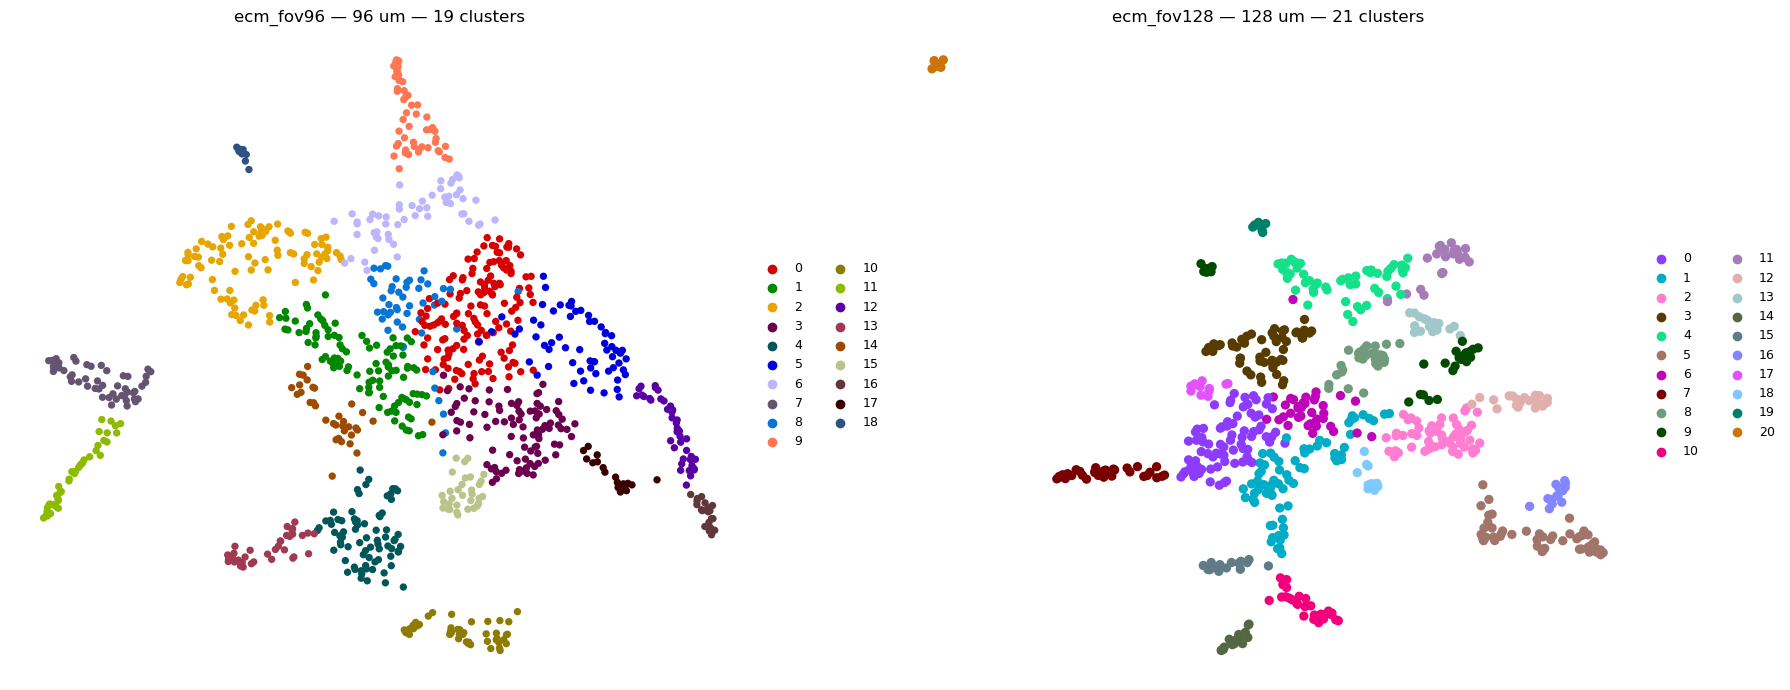

In [6]:
fig, axes = plt.subplots(1, len(CONFIGS), figsize=(9.0 * len(CONFIGS), 7.0))
for ax, k in zip(np.atleast_1d(axes), CONFIGS):
    sc.pl.umap(W[k], color="leiden", ax=ax, show=False, legend_loc="right margin",
               legend_fontsize=9, frameon=False,
               title="{} — {} um — {} clusters".format(k, CONFIGS[k], W[k].obs.leiden.nunique()))
plt.tight_layout()

### b. UMAP by ROI — the batch check

Same embeddings, coloured by ROI of origin. Heavy separation by ROI is the failure mode.
Some is expected: different patients genuinely have different tissue. Read it against
S4's composition-clustering baseline rather than against perfect mixing.

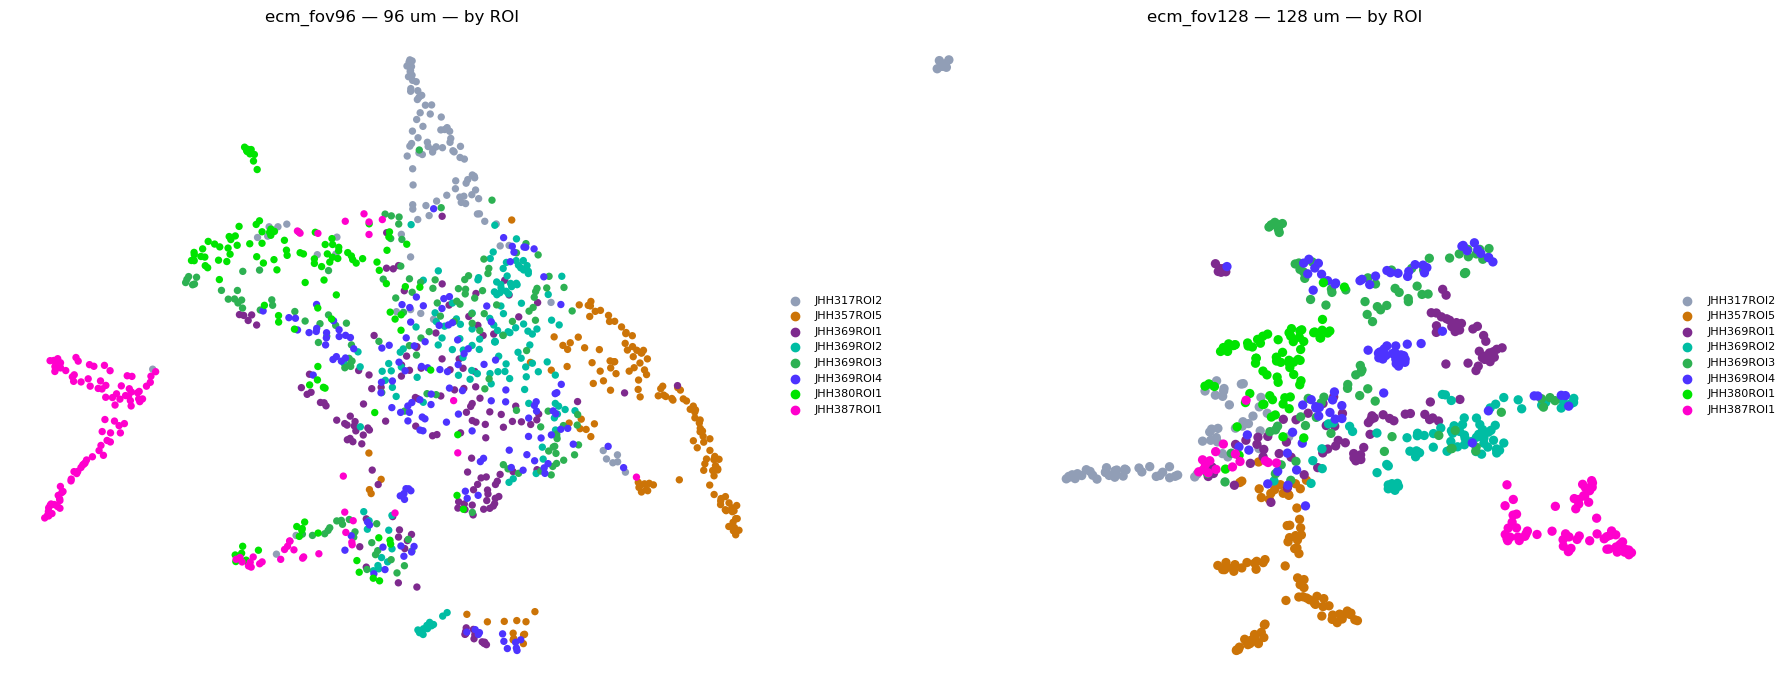

In [7]:
fig, axes = plt.subplots(1, len(CONFIGS), figsize=(9.0 * len(CONFIGS), 7.0))
for ax, k in zip(np.atleast_1d(axes), CONFIGS):
    sc.pl.umap(W[k], color="roi", ax=ax, show=False, legend_loc="right margin",
               legend_fontsize=8, frameon=False,
               title="{} — {} um — by ROI".format(k, CONFIGS[k]))
plt.tight_layout()

### c. UMAP by ECM content

The question this whole screen exists to answer: does the embedding organise by matrix
density? A smooth gradient means the model built matrix into its representation; noise
means channel 10 was ignored.

**Three quantities get called "ECM content" and they are not the same.** Measured medians
across the three configs:

| | 96 µm | 128 µm | 192 µm | area-invariant? |
|---|---|---|---|---|
| `ecm_mass` — Σ of channel-10 weights in the window | 12.26 | 20.15 | 38.57 | **no** — tracks window area |
| `ecm_voxels` — how many 20 µm sites the window covers | 20 | 36 | 81 | no — pure geometry |
| **`ecm_density`** — `mass / voxels` | **0.580** | **0.578** | **0.582** | **yes** |
| `frac_ecm` — mass / total window mass | 0.174 | 0.172 | 0.175 | yes, but a ratio against cell mass |

**Top row is `ecm_density`**, the honest one: geometry divided out, and near-identical
medians at all three window sizes because it measures matrix per unit tissue rather than
per window.

**Middle row is the raw sum.** It is the quantity the raster literally holds, and within a
single config it is fine — but it correlates at r = +0.77 with the voxel count alone, so a
part-off-tissue window reads as low-matrix whatever its density, and across configs it is
dominated by the 4× area difference between 96 and 192 µm.

**Bottom row is `patch_ncv`'s count-based version**, shown only so the difference is
visible: because ECM voxels sit at fixed lattice density, it is close to an inverse
cell-density map (r = −0.62 with cell mass), and reading it as "ECM content" is the trap
this notebook exists partly to document.


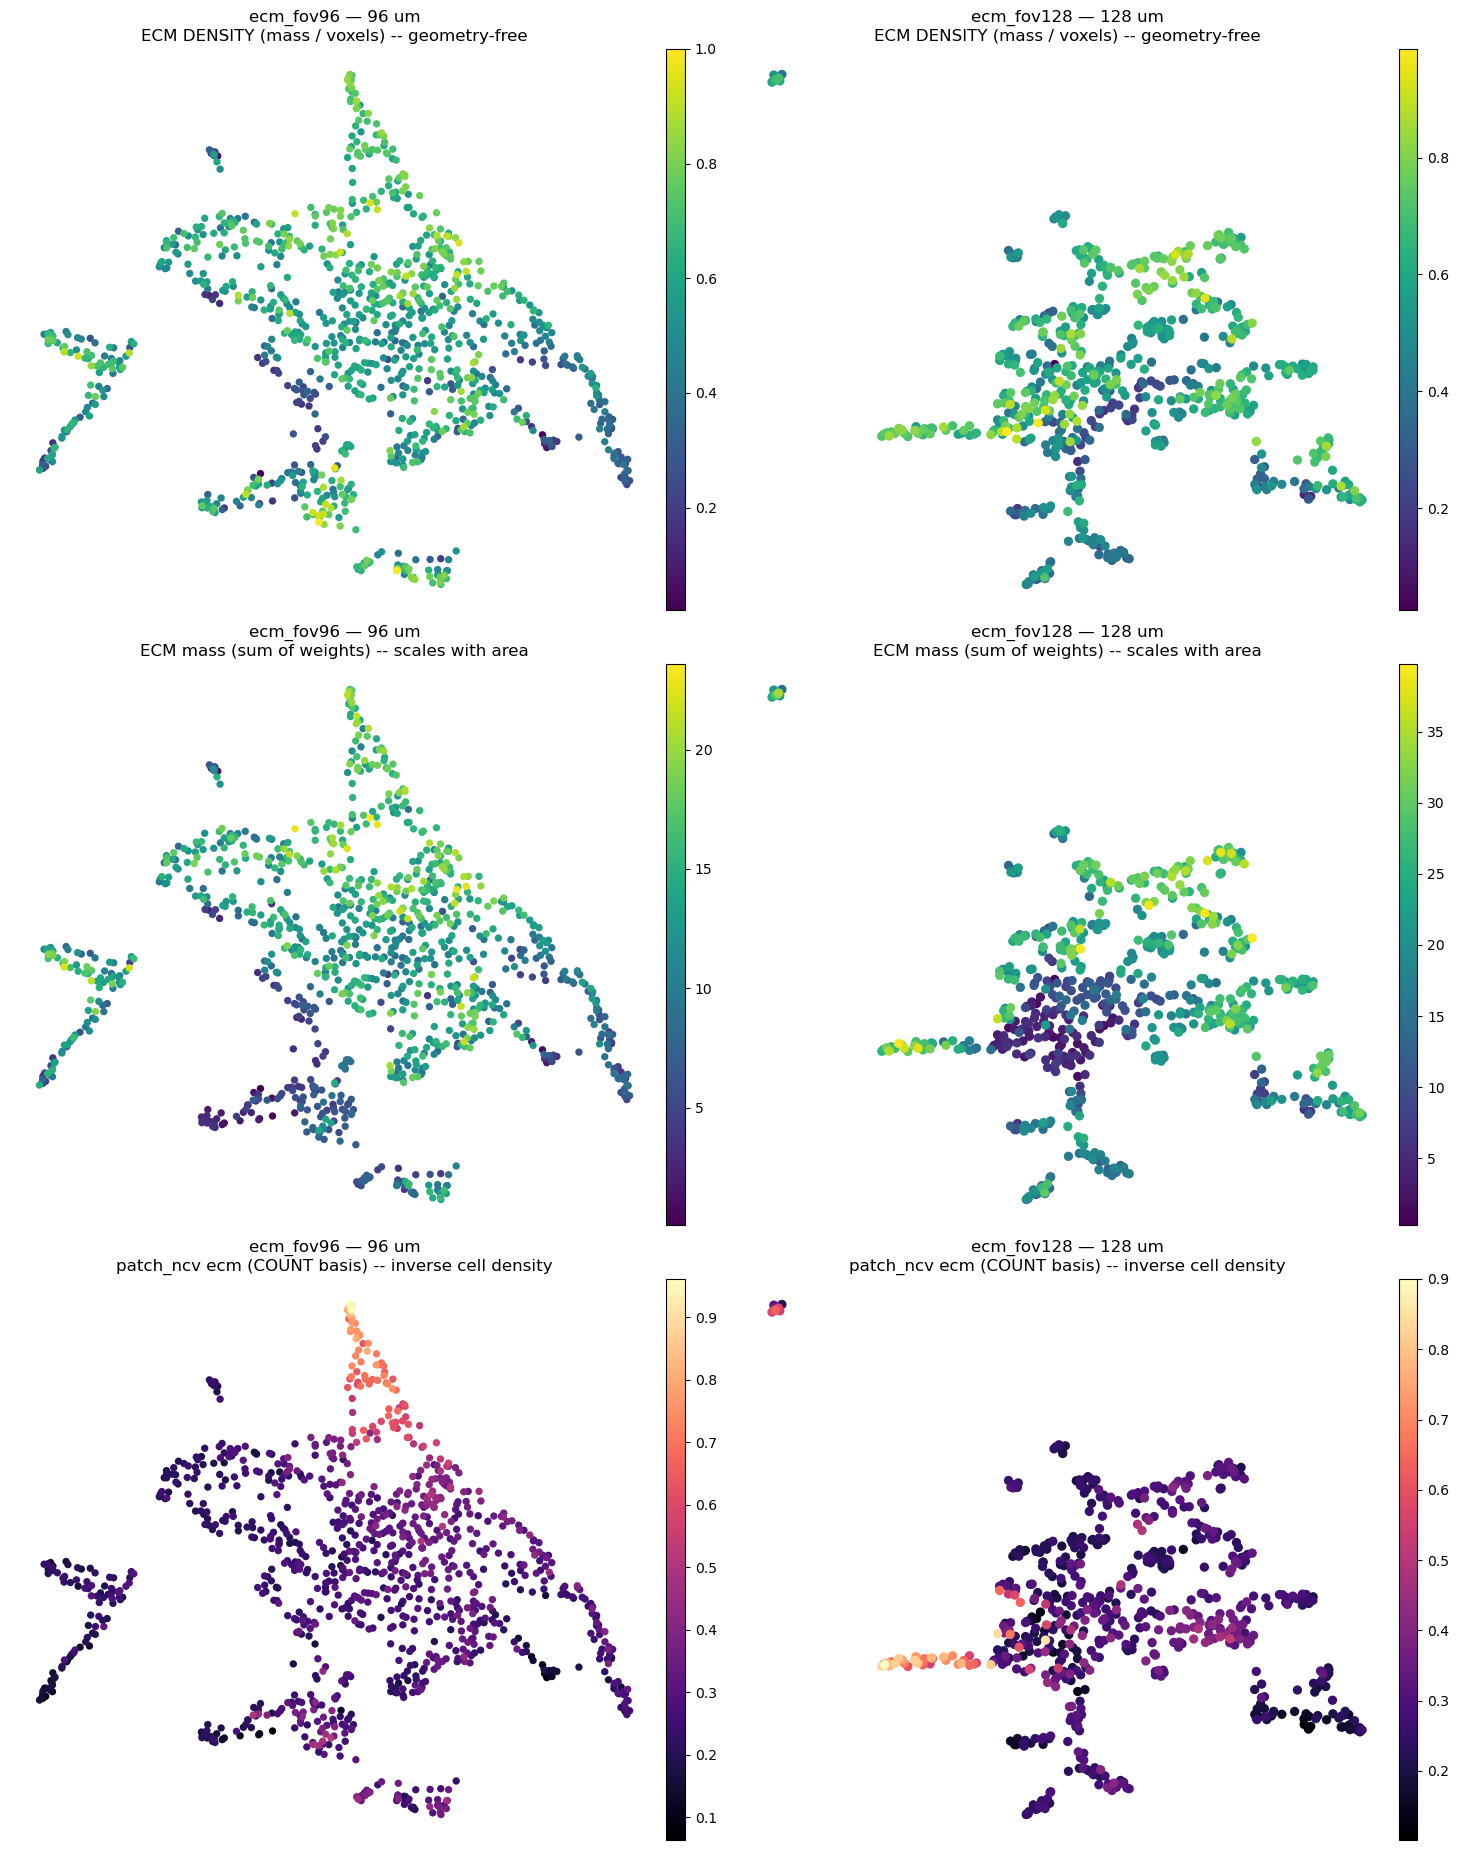

In [8]:
ECM_VIEWS = [("ecm_density", "viridis", "ECM DENSITY (mass / voxels) -- geometry-free"),
             ("ecm_mass",    "viridis", "ECM mass (sum of weights) -- scales with area"),
             ("ncv_ecm",     "magma",   "patch_ncv ecm (COUNT basis) -- inverse cell density")]

fig, axes = plt.subplots(len(ECM_VIEWS), len(CONFIGS),
                         figsize=(7.4 * len(CONFIGS), 6.2 * len(ECM_VIEWS)))
for i, (col, cmap, what) in enumerate(ECM_VIEWS):
    for j, k in enumerate(CONFIGS):
        sc.pl.umap(W[k], color=col, ax=axes[i, j], show=False, frameon=False, cmap=cmap,
                   title="{} — {} um\n{}".format(k, CONFIGS[k], what))
plt.tight_layout(); plt.show()


## Tissue maps — one figure per ROI

Five panels each: **one window panel per config (96, 128, 192 µm), then the ECM field, then
cell types on the far right**, so the cell-type legend sits in the outer margin and cannot overlap a plot.
Cluster legends sit below their own panel and list only the clusters actually present in
that ROI.

The cell panel uses `sc.pl.embedding(basis='spatial')` and **excludes the ECM rows** —
22,625 matrix points drawn over the cells would hide them entirely. The window panels
deliberately do not use scanpy: it sizes markers in points, so squares only tile if you
guess a size matching the figure geometry, and the gaps that produces are exactly what
hides contiguity. `imc_tm.plot_window_map` draws each window as a real data-coordinate
square instead. White gaps are windows the crop filter dropped.

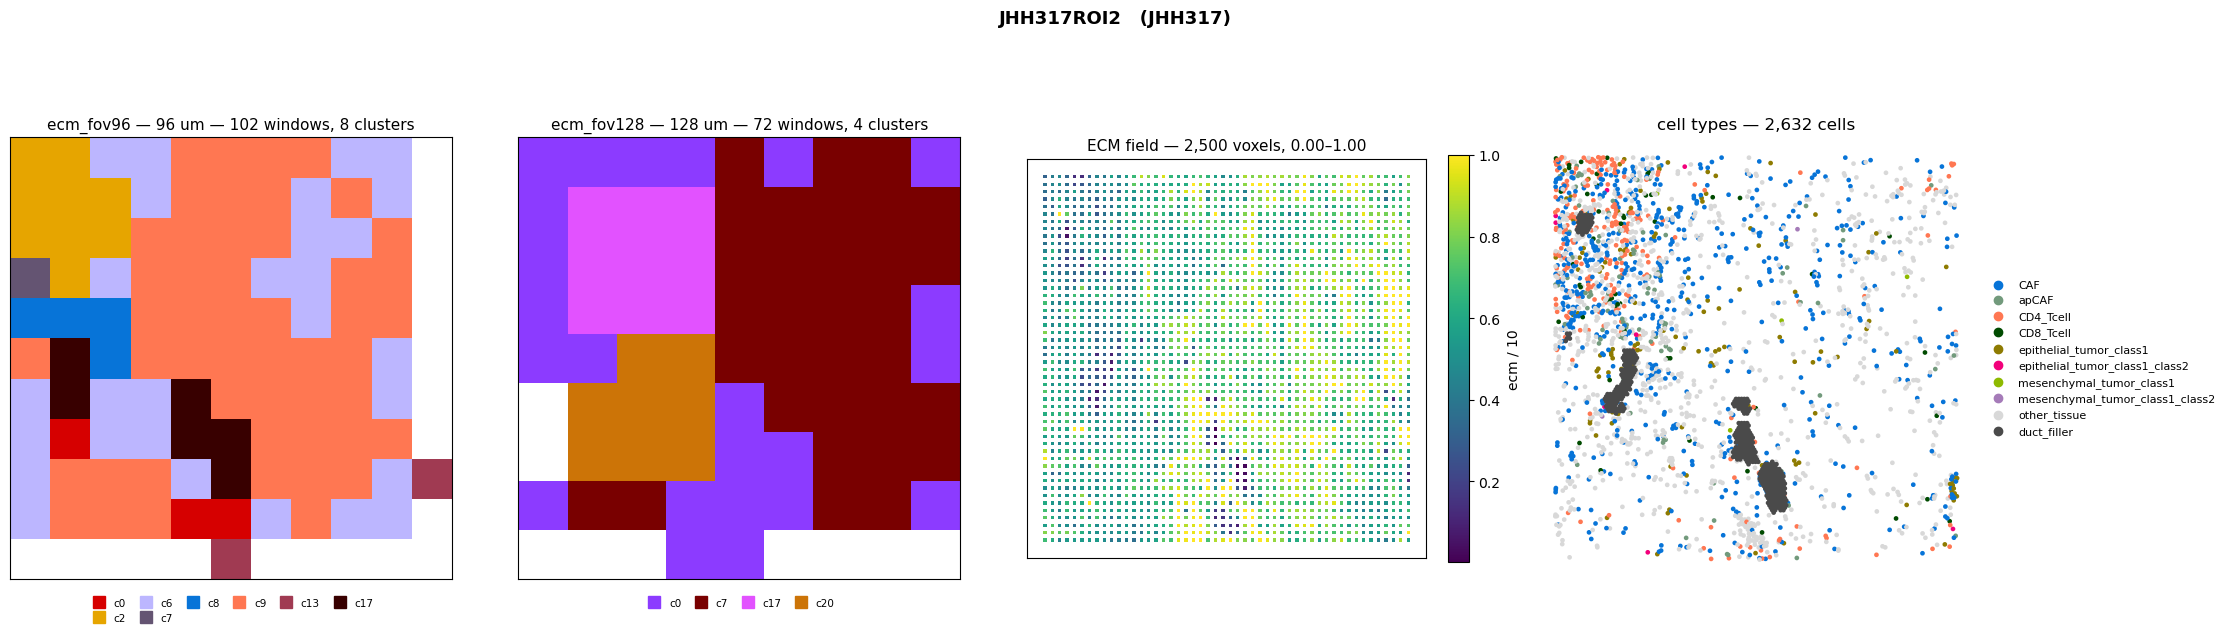

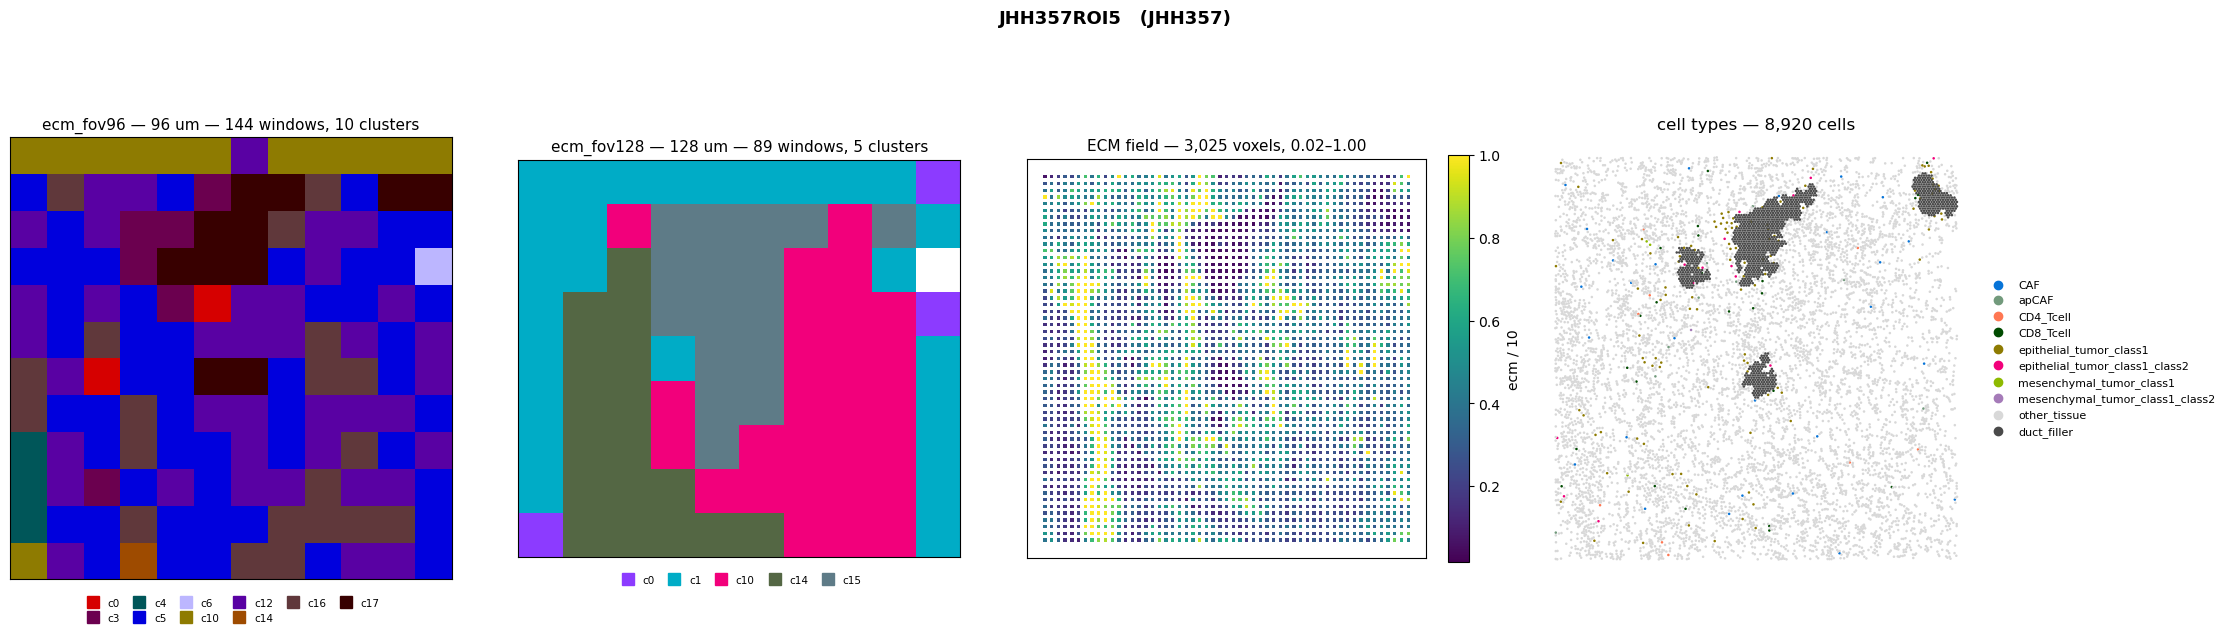

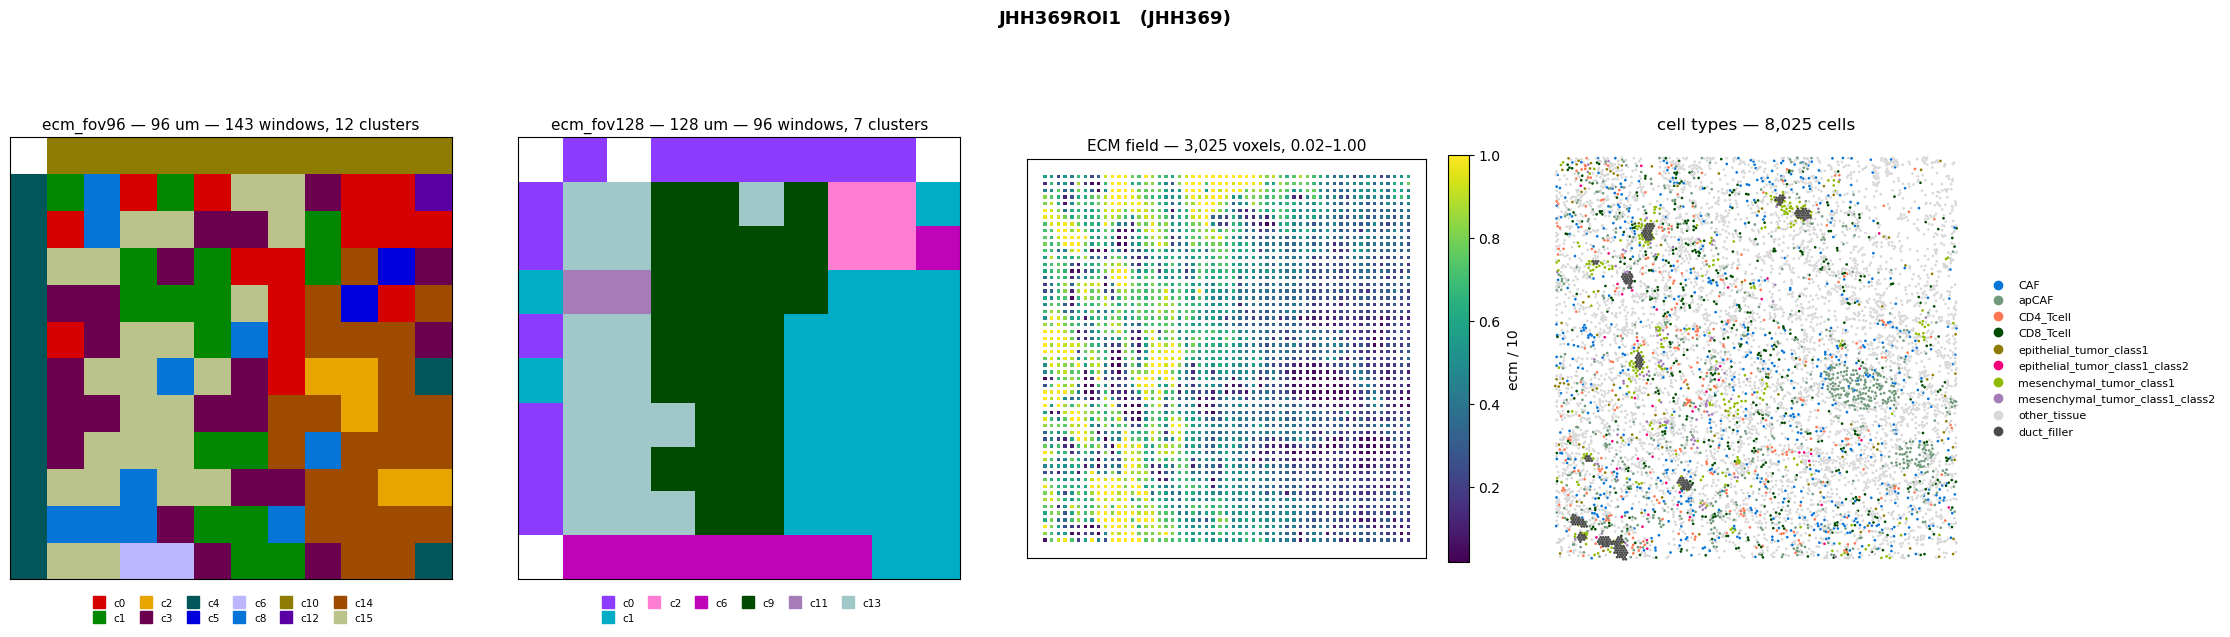

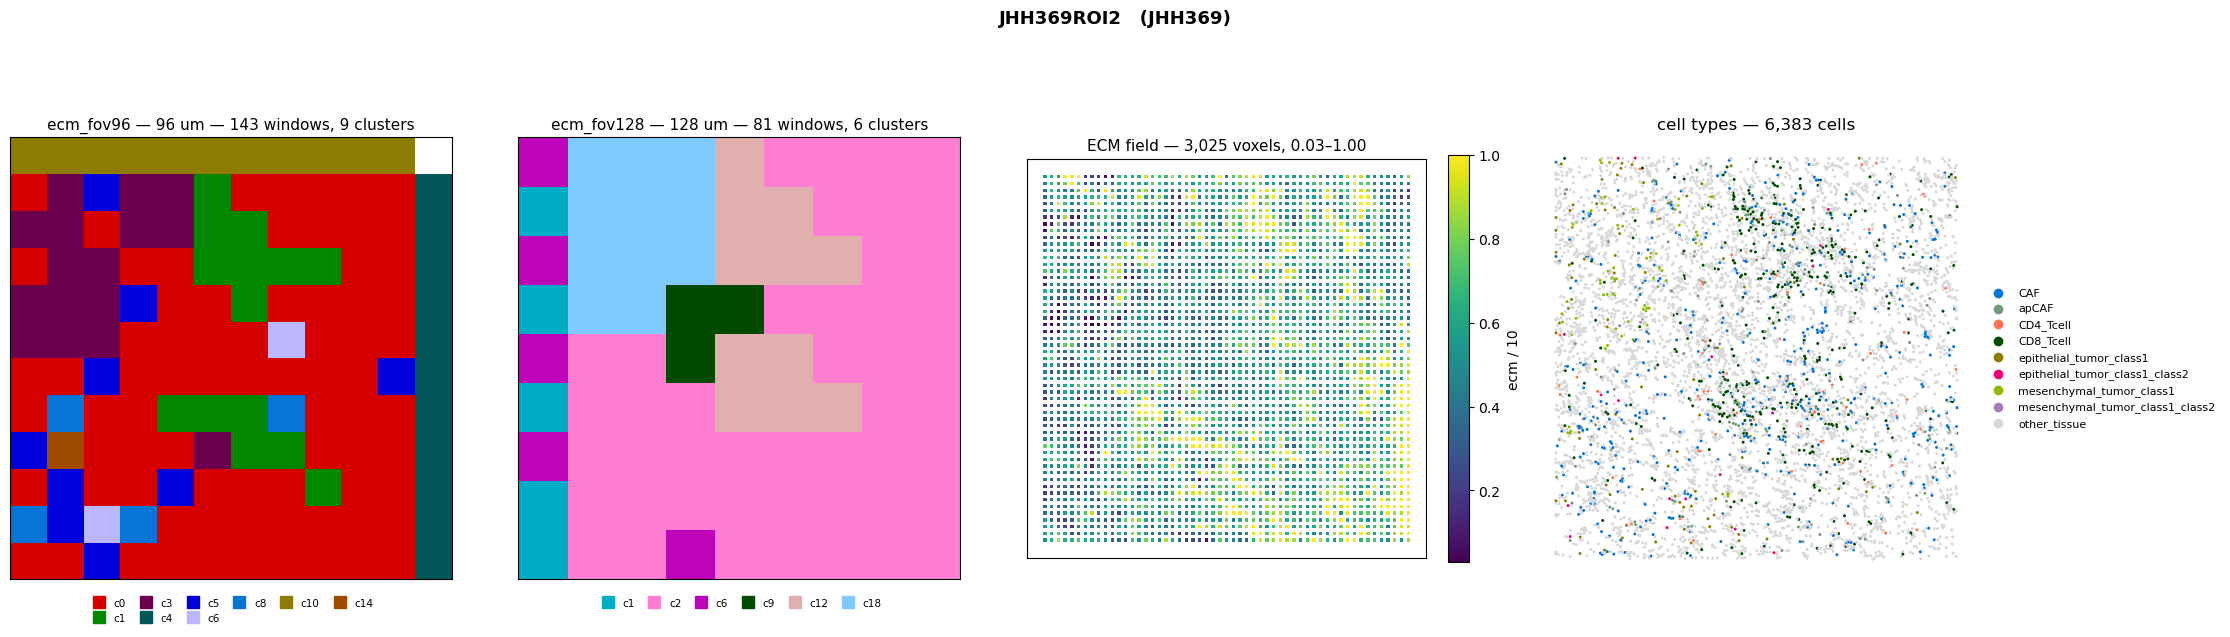

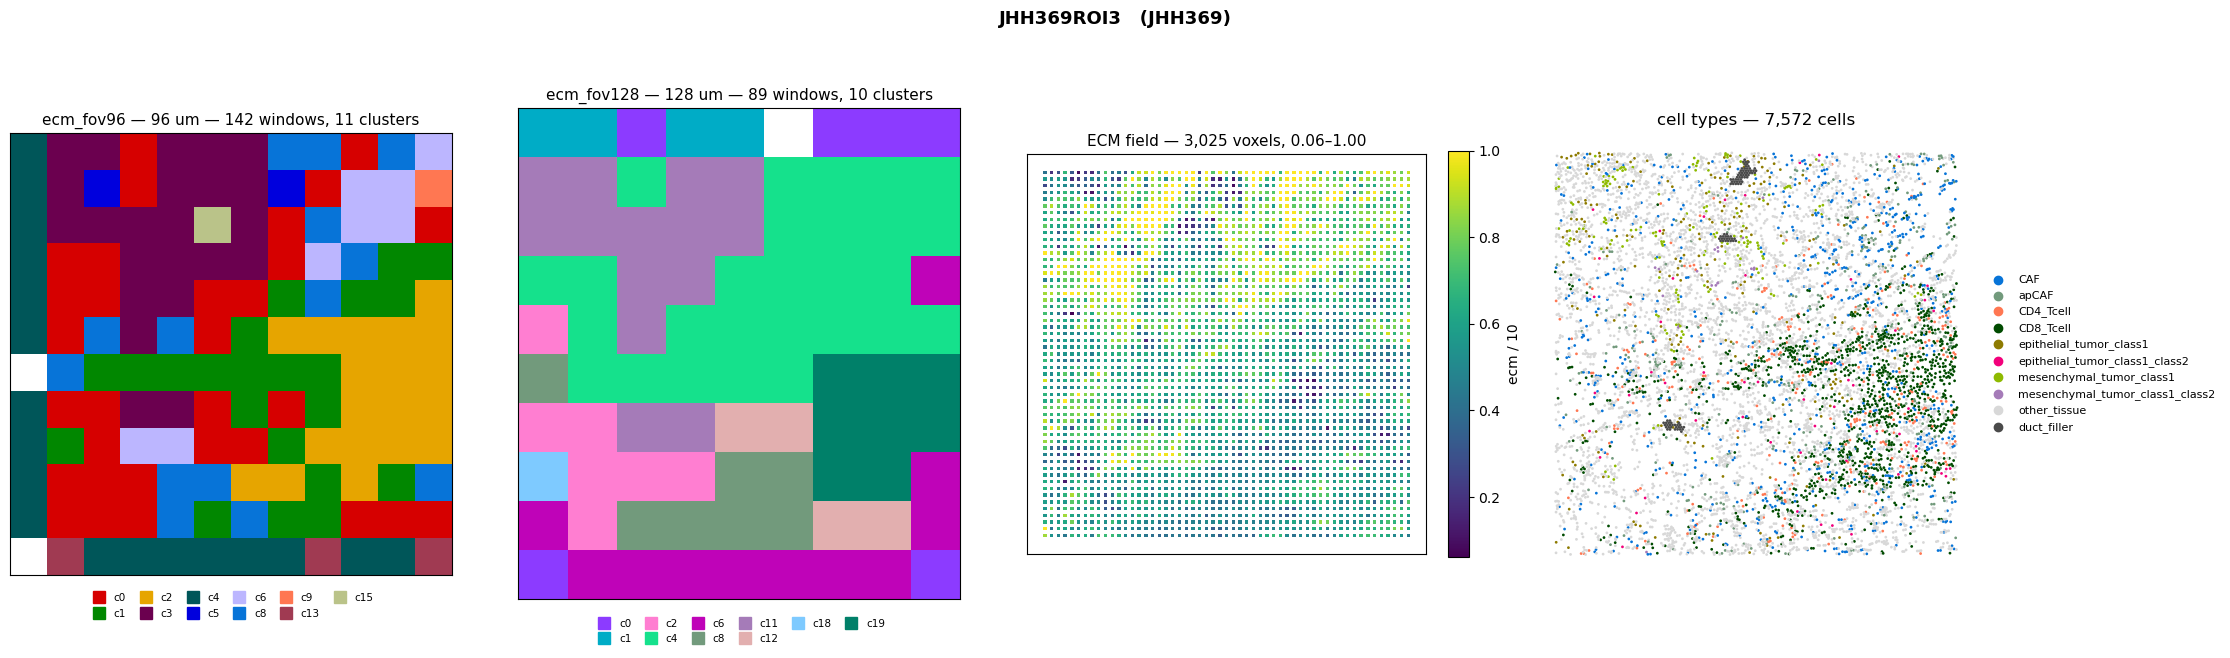

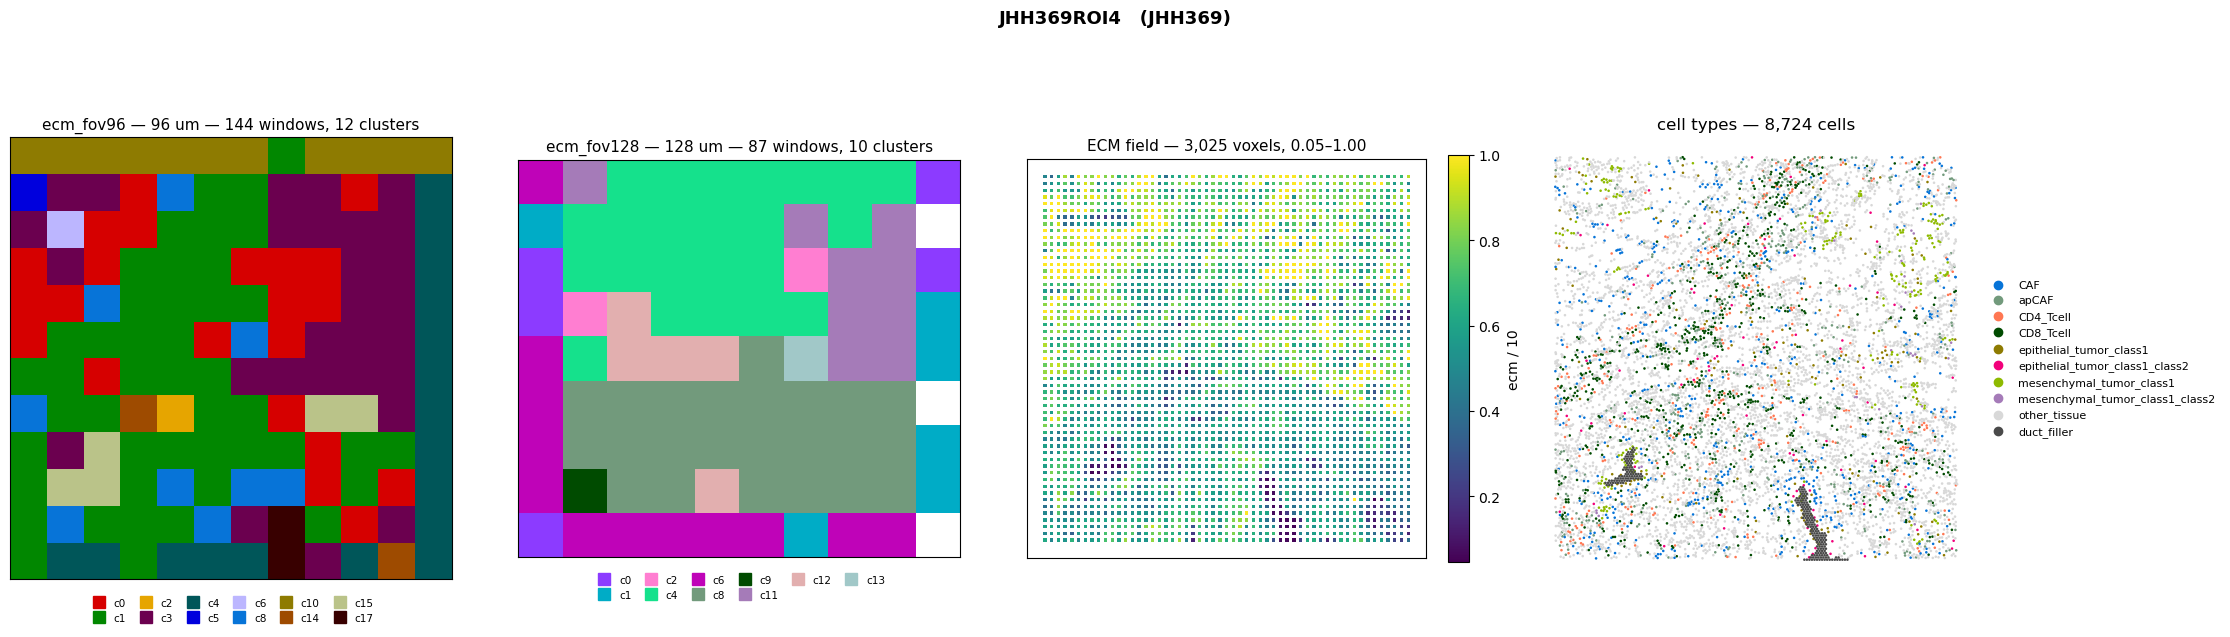

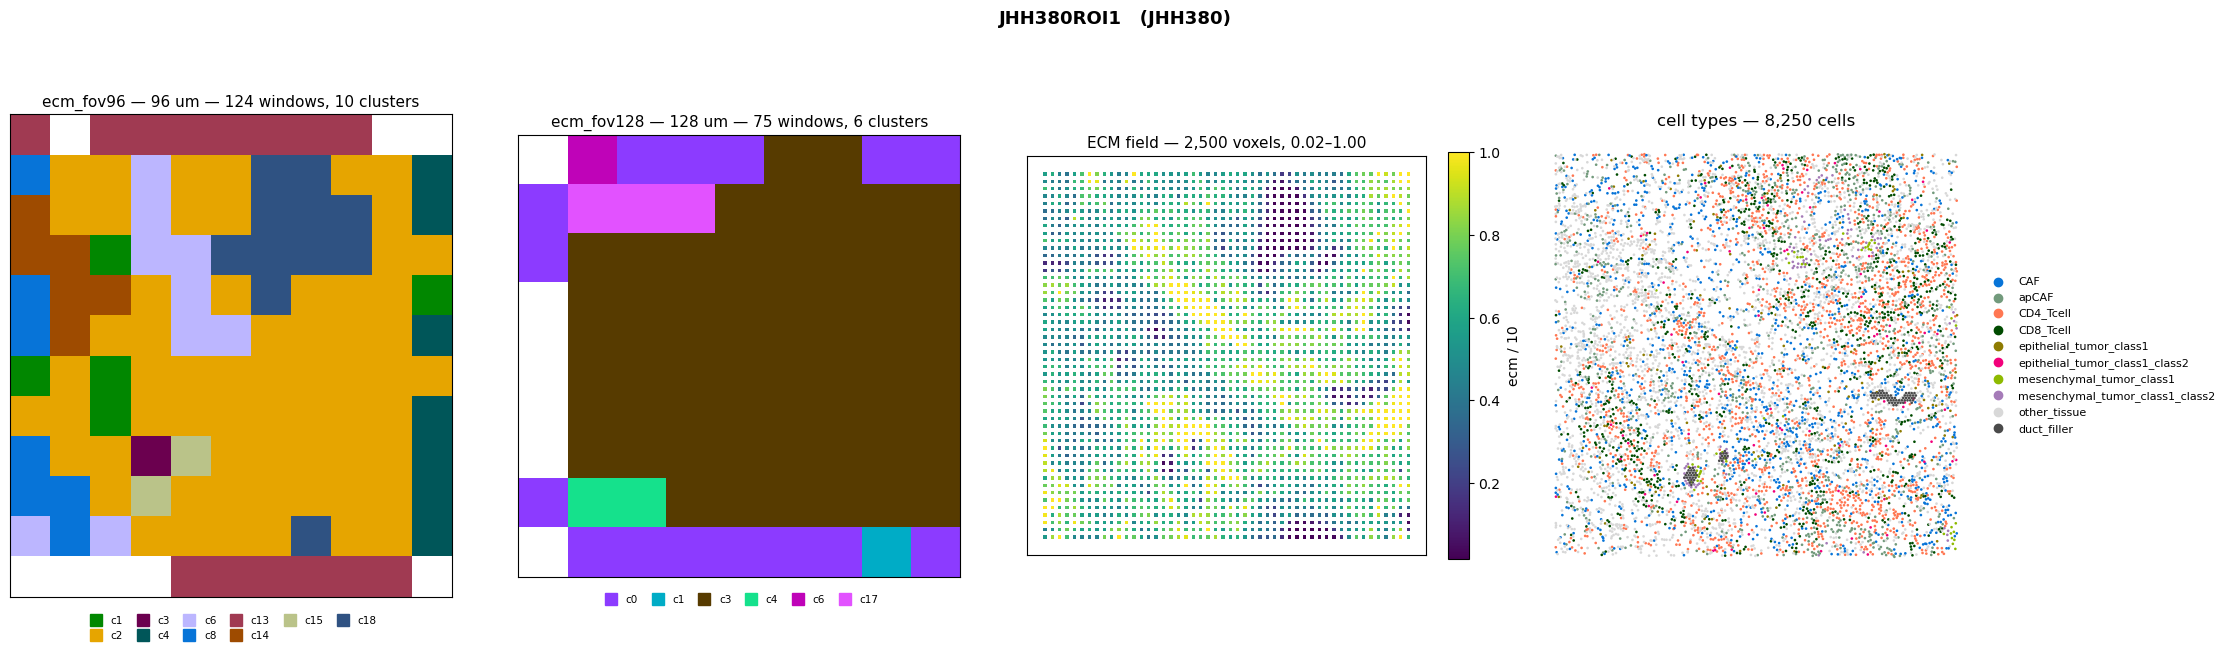

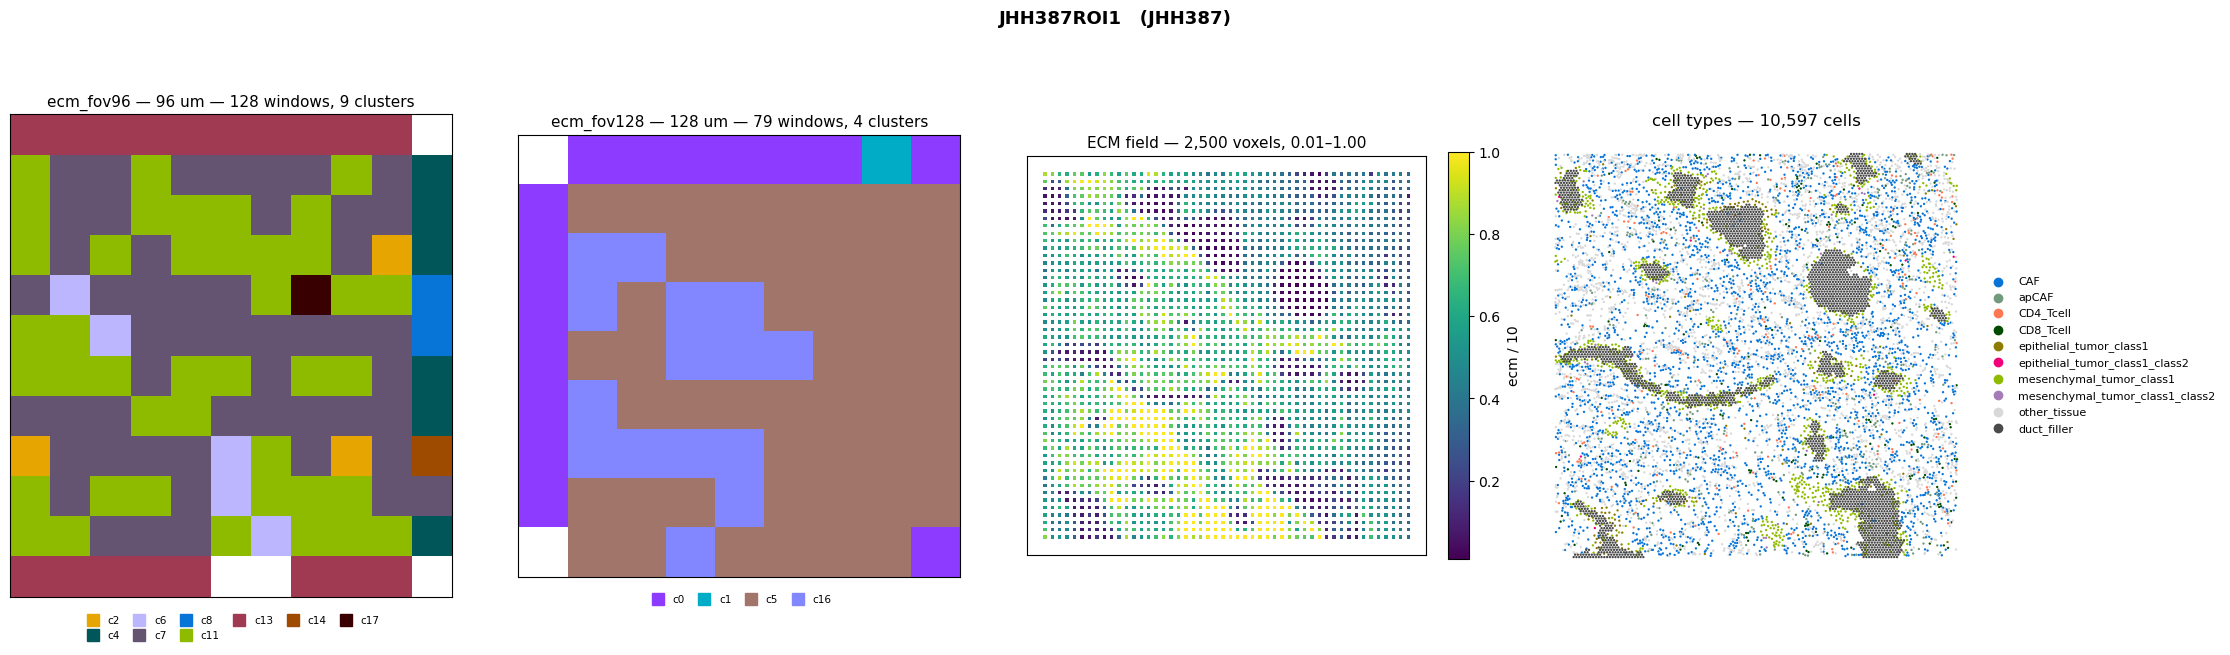

In [9]:
for r in ROIS:
    cs_all = cells[cells.obs.roi == r]
    cs = cs_all[~cs_all.obs.is_ecm.values].copy()
    ec = cs_all[cs_all.obs.is_ecm.values]
    NC = len(CONFIGS)                       # window panels, then ECM, then cell types
    fig, axes = plt.subplots(1, NC + 2, figsize=(5.6 * (NC + 2), 6.4))

    # --- one window panel per config, cluster legend beneath each -------------
    for j, k in enumerate(CONFIGS):
        w = W[k][W[k].obs.roi == r]
        pal = dict(zip(W[k].obs.leiden.cat.categories, W[k].uns["leiden_colors"]))
        present = [c for c in W[k].obs.leiden.cat.categories if (w.obs.leiden == c).any()]
        imc_tm.plot_window_map(axes[j], w.obsm["spatial"],
                               [pal[c] for c in w.obs.leiden], float(w.obs.fov_um.iloc[0]))
        axes[j].set_xticks([]); axes[j].set_yticks([])
        axes[j].set_title("{} — {} um — {} windows, {} clusters".format(
            k, CONFIGS[k], w.n_obs, len(present)), fontsize=11)
        h = [plt.Line2D([0], [0], marker="s", ls="", ms=8, color=pal[c], label="c{}".format(c))
             for c in present]
        axes[j].legend(handles=h, loc="upper center", bbox_to_anchor=(0.5, -0.02),
                       ncol=min(6, len(h)), fontsize=7.5, frameon=False,
                       handletextpad=0.4, columnspacing=0.9)

    # --- the ECM field itself, at its native 20 um lattice --------------------
    v = np.asarray(ec.X)[:, CHANNELS.index("ecm")]
    sm = axes[NC].scatter(ec.obsm["spatial"][:, 0], ec.obsm["spatial"][:, 1],
                         c=v, cmap="viridis", s=6, marker="s", linewidths=0)
    axes[NC].set_aspect("equal"); axes[NC].set_xticks([]); axes[NC].set_yticks([])
    axes[NC].set_title("ECM field — {:,} voxels, {:.2f}–{:.2f}".format(
        len(v), v.min(), v.max()), fontsize=11)
    plt.colorbar(sm, ax=axes[NC], fraction=0.046, label="ecm / 10")

    # --- cell types LAST, so its right-margin legend has clear space ----------
    cs.obs["cell_type"] = cs.obs["cell_type"].cat.remove_unused_categories()
    present_t = [t for t in imc_tm.CELL_TYPES if t in list(cs.obs.cell_type.cat.categories)]
    cs.uns["cell_type_colors"] = [to_hex(TPAL[t]) for t in present_t]
    sc.pl.embedding(cs, basis="spatial", color="cell_type", ax=axes[NC + 1], show=False,
                    frameon=False, legend_loc="right margin", legend_fontsize=8,
                    title="cell types — {:,} cells".format(cs.n_obs))
    axes[NC + 1].set_aspect("equal")

    fig.suptitle("{}   ({})".format(r, cs.obs.patient.iloc[0]), y=1.02,
                 fontsize=13, weight="bold")
    plt.tight_layout()
    plt.show()

## What each cluster is made of

### a. Heatmaps of mean composition

Two views of the same clusters, drawn with `seaborn.heatmap` so every cell carries its
value:

- **left — classified biology only**, renormalised so each cluster's eight values sum to
  1. This is the readable view: `other_tissue` alone is most of a typical window and would
  otherwise set the whole colour scale. It excludes `ecm`, so it is directly comparable to
  the same panel in S3.
- **right — all eleven channels**, background and matrix included, each cluster summing to
  1. This is what the windows actually contain, and the `ecm` column is where you see how
  much of each cluster is matrix.

The two are on **separate colour scales** by necessity, so compare within a panel, not
across.

=== ecm_fov96 (96 um) ===
  71/1070 windows (6.6%) have zero classified biology and are excluded
  per-cluster fractions sum to [1.0000, 1.0000] -- these ARE row-normalised


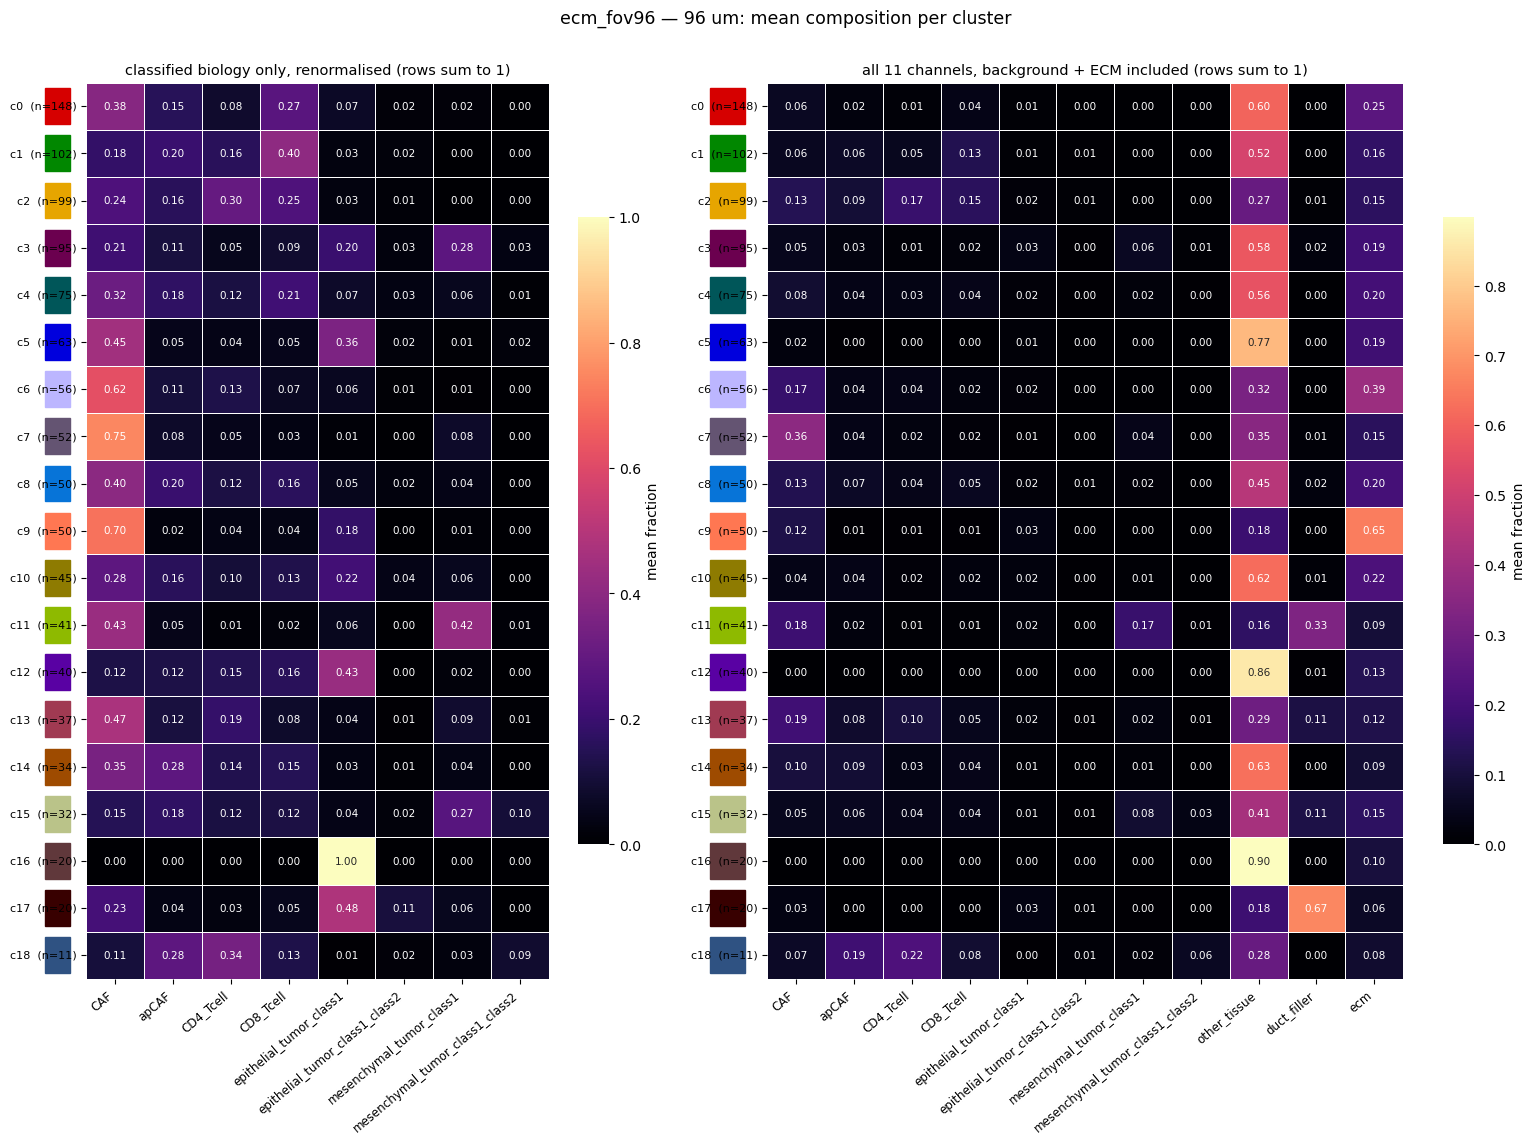

=== ecm_fov128 (128 um) ===
  27/668 windows (4.0%) have zero classified biology and are excluded
  per-cluster fractions sum to [1.0000, 1.0000] -- these ARE row-normalised


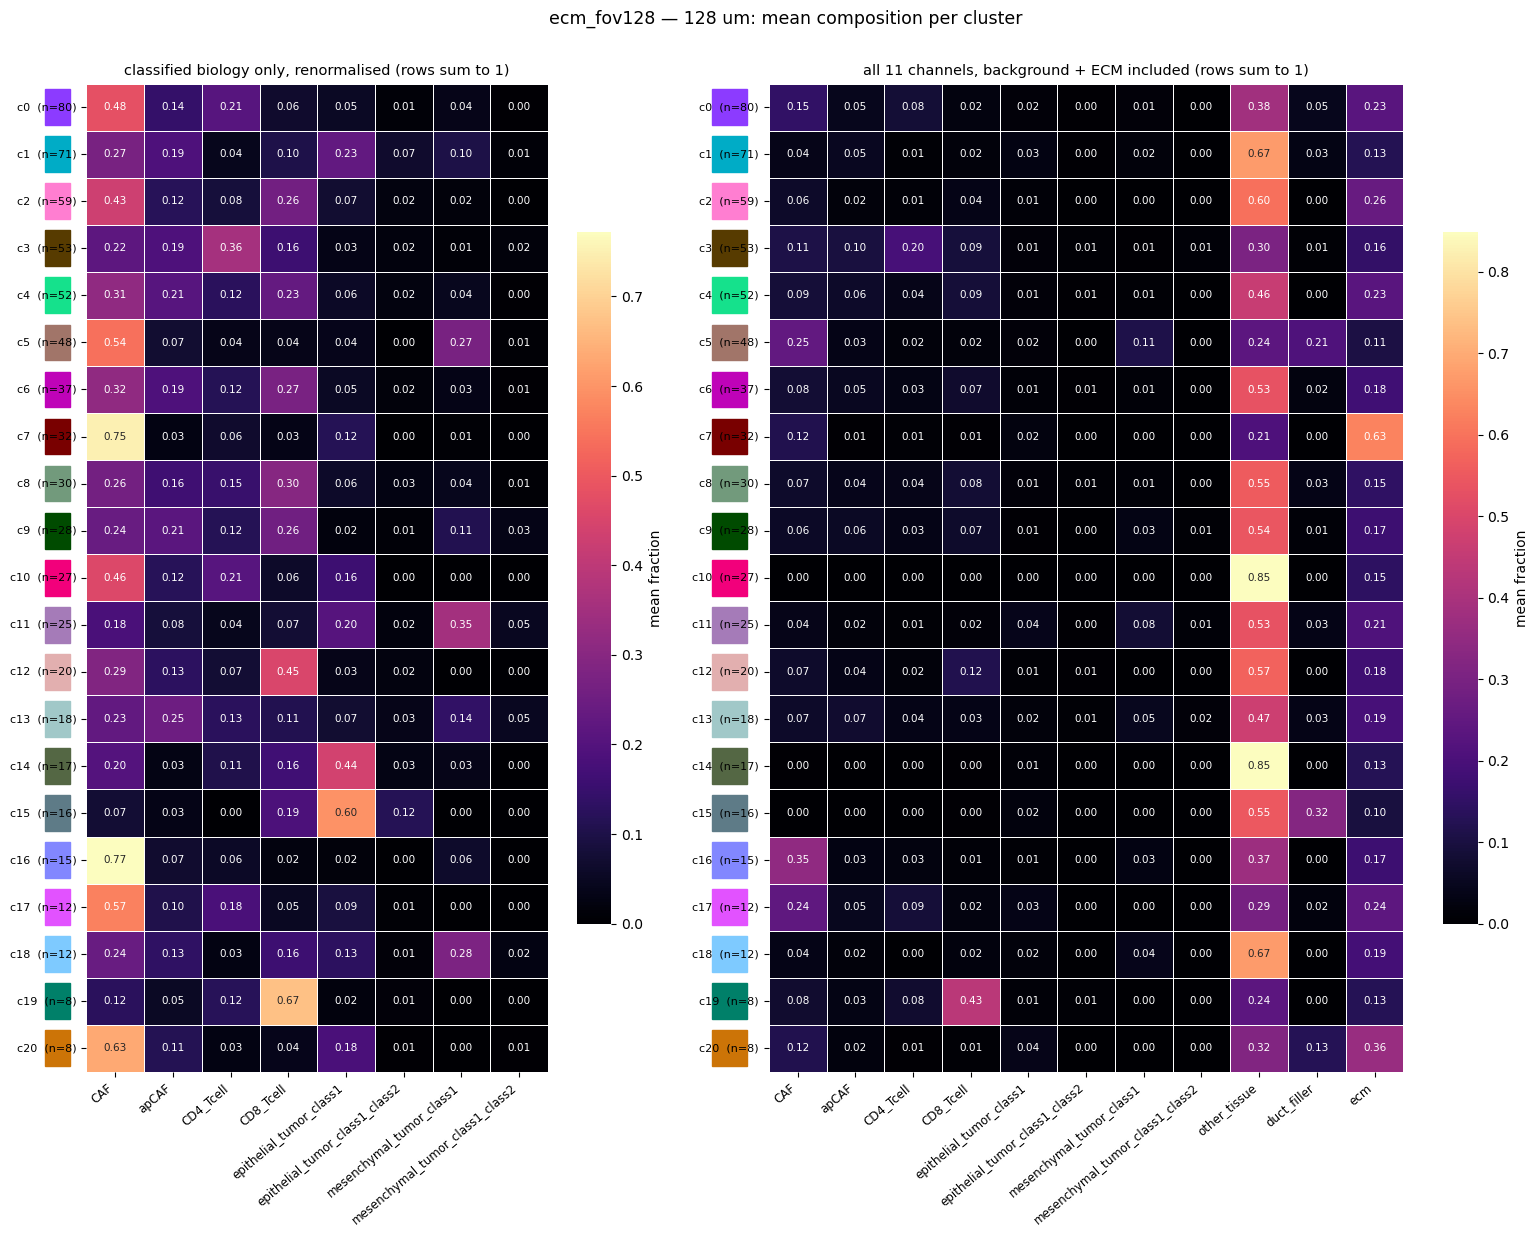

In [10]:
def biology_fractions(w):
    # Biology composition renormalised per window, with all-background windows as NaN.
    #
    # patch_ncv sums to 1 over all ELEVEN channels here, so the eight biology channels sum
    # to well under 1 and have to be renormalised to be readable. The trap: some windows
    # contain ZERO classified biology, and dividing those by a clipped zero turns them into
    # all-zero rows that silently drag every cluster mean below 1. Marking them NaN instead
    # makes the mean skip them, and cluster sums land at exactly 1.0000.
    idx = [CHANNELS.index(t) for t in BIOLOGY]
    b = np.asarray(w.obsm["composition"])[:, idx]
    tot = b.sum(axis=1, keepdims=True)
    return np.where(tot > 0, b / np.where(tot > 0, tot, 1.0), np.nan), (tot[:, 0] <= 0)


def comp_view(w):
    b, empty = biology_fractions(w)
    v = ad.AnnData(X=np.nan_to_num(b, nan=0.0).astype(np.float32), obs=w.obs.copy())
    v.var_names = list(BIOLOGY)
    v.uns["leiden_colors"] = w.uns["leiden_colors"]
    v.obs["has_biology"] = ~empty
    return v[v.obs.has_biology].copy()      # drop all-background windows from the mean

views = {k: comp_view(W[k]) for k in CONFIGS}
for k in CONFIGS:
    _, empty = biology_fractions(W[k])
    chk = pd.DataFrame(views[k].X, columns=BIOLOGY)
    chk["leiden"] = np.asarray(views[k].obs.leiden)
    sums = chk.groupby("leiden", observed=True)[BIOLOGY].mean().sum(axis=1)
    print("=== {} ({} um) ===".format(k, CONFIGS[k]))
    print("  {}/{} windows ({:.1f}%) have zero classified biology and are excluded".format(
        int(empty.sum()), len(empty), 100 * empty.mean()))
    print("  per-cluster fractions sum to [{:.4f}, {:.4f}] -- these ARE row-normalised".format(
        sums.min(), sums.max()))

    bio = pd.DataFrame(views[k].X, columns=BIOLOGY)
    bio["leiden"] = np.asarray(views[k].obs.leiden)
    bio = bio.groupby("leiden", observed=True)[BIOLOGY].mean()

    allc = pd.DataFrame(W[k].obsm["composition"], columns=CHANNELS)
    allc["leiden"] = np.asarray(W[k].obs.leiden)
    n_win = allc.groupby("leiden", observed=True).size()
    allc = allc.groupby("leiden", observed=True)[CHANNELS].mean()

    order = [c for c in W[k].obs.leiden.cat.categories if c in bio.index]
    bio, allc = bio.loc[order], allc.loc[order]
    ylabels = ["c{}  (n={})".format(c, n_win[c]) for c in order]
    cpal = dict(zip(W[k].obs.leiden.cat.categories, W[k].uns["leiden_colors"]))

    fig, axes = plt.subplots(
        1, 2, figsize=(9.0 + 0.62 * len(CHANNELS), 0.46 * len(order) + 2.6),
        gridspec_kw={"width_ratios": [len(BIOLOGY), len(CHANNELS)]})
    for ax, mat, title in [
            (axes[0], bio,  "classified biology only, renormalised (rows sum to 1)"),
            (axes[1], allc, "all 11 channels, background + ECM included (rows sum to 1)")]:
        sns.heatmap(mat, ax=ax, cmap="magma", annot=True, fmt=".2f",
                    annot_kws={"fontsize": 7.5}, linewidths=0.4, linecolor="white",
                    cbar_kws={"label": "mean fraction", "shrink": 0.7})
        ax.set_title(title, fontsize=10.5)
        ax.set_xlabel(""); ax.set_ylabel("")
        ax.set_xticklabels(ax.get_xticklabels(), rotation=40, ha="right", fontsize=8.5)
        ax.set_yticklabels(ylabels, rotation=0, fontsize=8)
        for yi, c in enumerate(order):     # cluster colour chip outside the axes
            ax.add_patch(plt.Rectangle((-0.09, yi + 0.12), 0.055, 0.76, color=cpal[c],
                                       transform=ax.get_yaxis_transform(), clip_on=False))
    fig.suptitle("{} — {} um: mean composition per cluster".format(k, CONFIGS[k]),
                 y=1.005, fontsize=12.5)
    plt.tight_layout()
    plt.show()

### b. ECM content per cluster, all configs side by side

The `ecm` column pulled out and ordered, because it is the one column this screen was run
to look at. Boxes are windows, not ROIs.

**Top row is `ecm_density`**, which is what "how much matrix" should mean. **Middle row is
the mass fraction** the composition panels use — area-invariant too, but a ratio against
cell mass, so it also moves whenever cell density moves. **Bottom row is the voxel count**:
a pure-geometry control containing no matrix values at all. Read the η² values together —
if the bottom row scores as high as the top, the clusters are separating on where the
tissue edge is rather than on matrix.


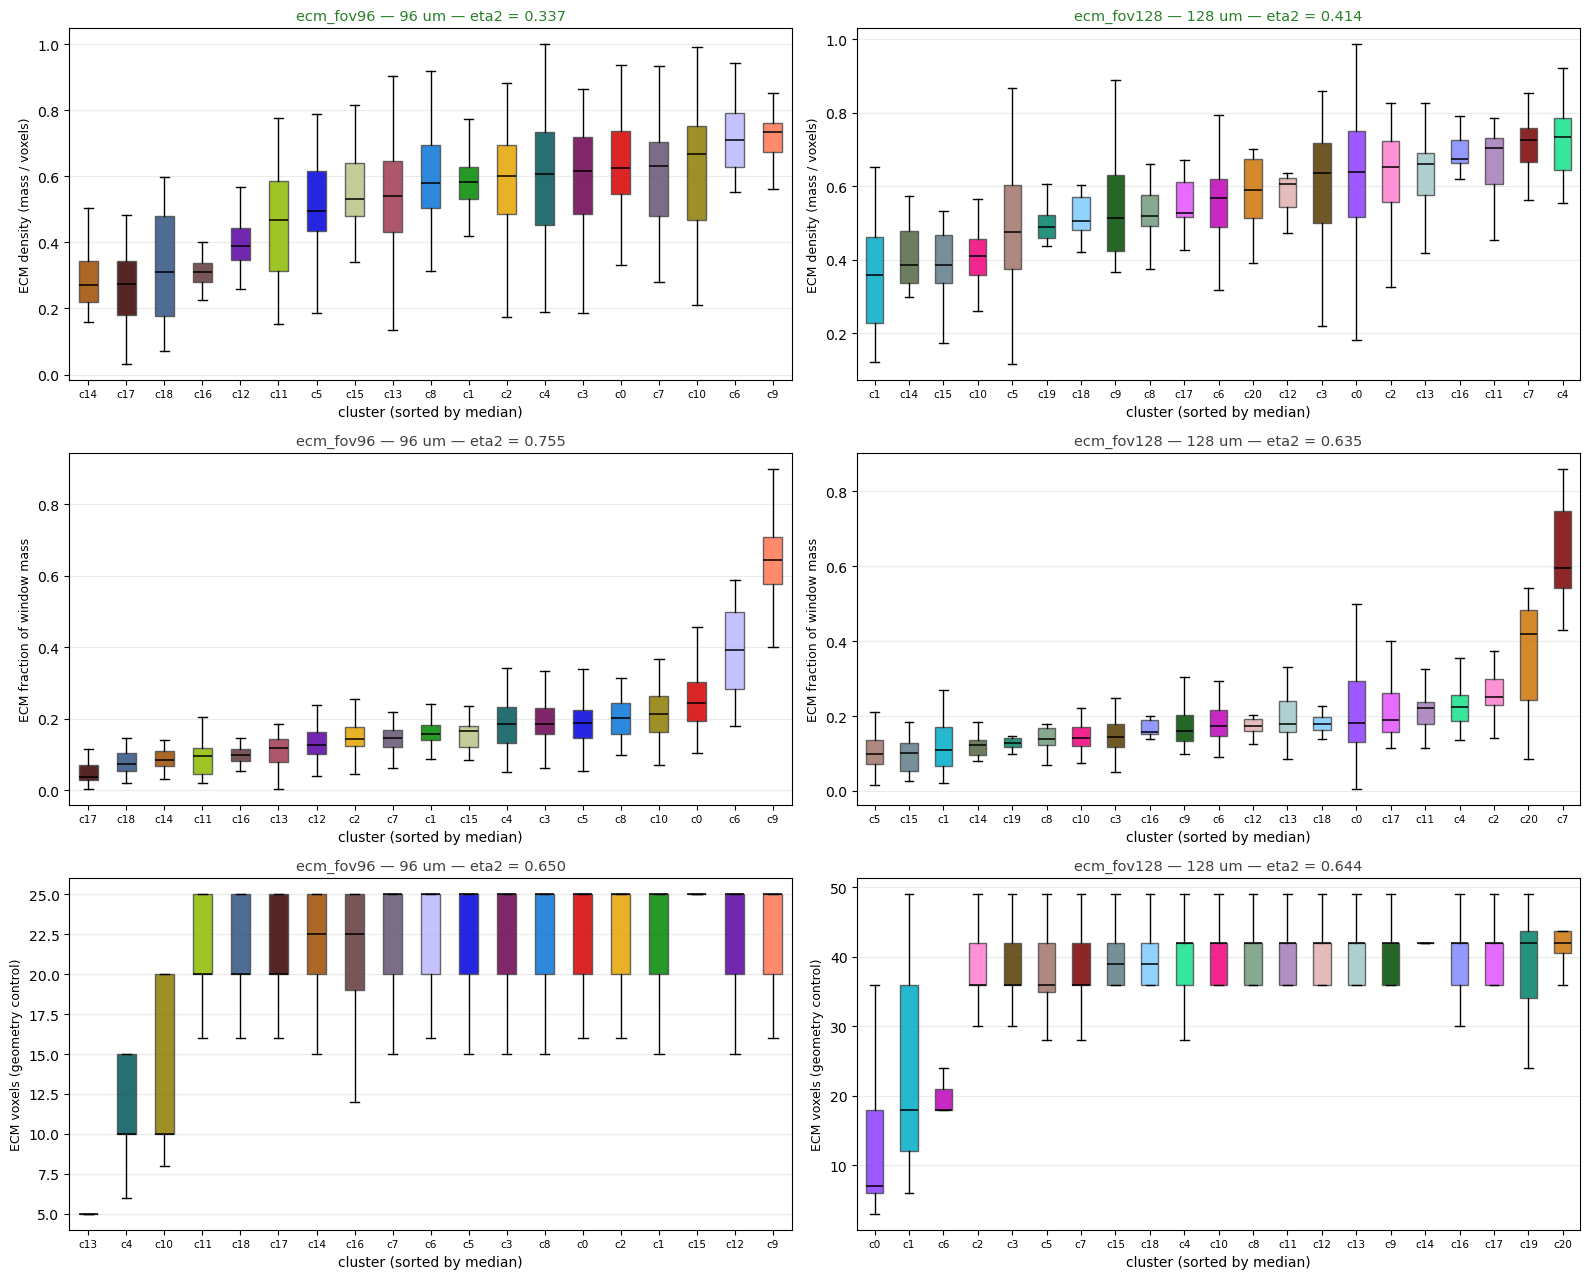

measure,ecm_density,frac_ecm,ecm_voxels
config,,,
ecm_fov96,0.337,0.755,0.650
ecm_fov128,0.414,0.635,0.644


ecm_voxels is the control -- it carries NO matrix values. Where it scores as high
as ecm_density, that cluster structure is window occupancy, not matrix content.


In [11]:
BOX_VIEWS = [("ecm_density", "ECM density (mass / voxels)"),
             ("frac_ecm",    "ECM fraction of window mass"),
             ("ecm_voxels",  "ECM voxels (geometry control)")]

def eta2(v, lab):
    ok = np.isfinite(v); v, lab = np.asarray(v)[ok], np.asarray(lab)[ok]
    g = v.mean()
    ssb = sum((lab == k).sum() * (v[lab == k].mean() - g) ** 2 for k in np.unique(lab))
    return ssb / ((v - g) ** 2).sum()

eta_rows = []
fig, axes = plt.subplots(len(BOX_VIEWS), len(CONFIGS),
                         figsize=(8.0 * len(CONFIGS), 4.3 * len(BOX_VIEWS)))
for i, (col, label) in enumerate(BOX_VIEWS):
    for j, k in enumerate(CONFIGS):
        ax = axes[i, j]; w = W[k]
        v = np.asarray(w.obs[col], dtype=float)
        lab = np.asarray(w.obs.leiden)
        cpal = dict(zip(w.obs.leiden.cat.categories, w.uns["leiden_colors"]))
        keys = list(w.obs.leiden.cat.categories)
        data = [v[(lab == c) & np.isfinite(v)] for c in keys]
        order = np.argsort([np.median(d) if len(d) else 0.0 for d in data])
        bp = ax.boxplot([data[o] for o in order], patch_artist=True, showfliers=False,
                        medianprops=dict(color="black", lw=1.1))
        for patch, o in zip(bp["boxes"], order):
            patch.set_facecolor(cpal[keys[o]]); patch.set_alpha(0.85); patch.set_edgecolor("0.3")
        ax.set_xticklabels(["c{}".format(keys[o]) for o in order], fontsize=7.5)
        e = eta2(v, lab); eta_rows.append(dict(config=k, measure=col, eta2=e))
        ax.set_title("{} — {} um — eta2 = {:.3f}".format(k, CONFIGS[k], e), fontsize=10.5,
                     color=("#2a7f2a" if col == "ecm_density" else "0.25"))
        ax.set_xlabel("cluster (sorted by median)"); ax.set_ylabel(label, fontsize=9)
        ax.grid(axis="y", alpha=0.25)
plt.tight_layout(); plt.show()

ETA = pd.DataFrame(eta_rows).pivot(index="config", columns="measure", values="eta2")
ETA = ETA.reindex(list(CONFIGS))[[c for c, _ in BOX_VIEWS]]
display(ETA.round(3))
print("ecm_voxels is the control -- it carries NO matrix values. Where it scores as high")
print("as ecm_density, that cluster structure is window occupancy, not matrix content.")


## Spread of composition across ROIs

Four grids per config, eight in total. All of them use the **all-eleven-channel**
fractions (`patch_ncv`, which sums to 1 per window), and all are boxes over ROIs with one
dot per ROI.

**Absent clusters count as zero.** `groupby` emits no row for a (cluster, ROI) pair that
does not occur, so the table is reindexed to the full product and filled with 0 — every
box spans all 8 ROIs. A cluster confined to a couple of sections therefore reads as a
**low box with a few high dots**, rather than as a deceptively tight box over the handful
of ROIs it happens to occupy. The `R/8` on each label is the number of ROIs it actually
occurs in, and ≤2 is flagged in red.

| | panels | x-axis | y-axis |
|---|---|---|---|
| **b1** | channel (11) | cluster | fixed 0–1 |
| **b2** | channel (11) | cluster | 0 to that channel's max across ALL configs |
| **c1** | cluster | all 11 channels | fixed 0–1 |
| **c2** | cluster | 8 biology types + `ecm` | 0 to the max of those across ALL configs |

The fixed 0–1 versions are comparable to everything else in the notebook; the rescaled
versions make the low-abundance channels readable, which a 0–1 axis flattens to nothing.
**c2 drops the two background types from the x-axis but not from the arithmetic** — the
values are still fractions of all eleven channels, so they do not sum to 1 across the nine
boxes.

In [12]:
PAD = 1.08          # headroom above the largest observed value

PER = {}            # per (cluster, roi) mean composition, per config
for k in CONFIGS:
    w = W[k]
    df = pd.DataFrame(np.asarray(w.obsm["composition"]), columns=CHANNELS)
    df["leiden"] = np.asarray(w.obs.leiden).astype(str)
    df["roi"] = np.asarray(w.obs.roi).astype(str)
    g = df.groupby(["leiden", "roi"], observed=True)[CHANNELS].mean()
    # A cluster absent from an ROI produces NO ROW from groupby. Treat that as a ZERO
    # contribution rather than a missing observation, so every box spans all ROIs and a
    # rare cluster reads as a low box rather than a deceptively tight one.
    full = pd.MultiIndex.from_product(
        [[str(c) for c in w.obs.leiden.cat.categories], list(ROIS)], names=["leiden", "roi"])
    PER[k] = g.reindex(full, fill_value=0.0).reset_index()

# HOW MANY ROIs each cluster actually occurs in. Count ROIs whose row is not all-zero
# after the zero-fill; summing over ROIs first collapses to one row per cluster and always
# yields 1, which is the bug this replaced.
N_ROI = {}
for k in CONFIGS:
    occ = PER[k].set_index(["leiden", "roi"])[CHANNELS].sum(axis=1) > 0
    N_ROI[k] = occ.groupby(level="leiden").sum().astype(int).to_dict()
print("ROIs each cluster occurs in:")
for k in CONFIGS:
    print("   {:<11s} ".format(k) + "  ".join(
        "c{}:{}".format(c, N_ROI[k][c]) for c in sorted(N_ROI[k], key=int)))

# shared scales, computed ACROSS every config so the grids are directly comparable
YMAX_TYPE = {t: PAD * max(PER[k][t].max() for k in CONFIGS) for t in CHANNELS}
YMAX_BIO  = PAD * max(PER[k][BIO_ECM].max().max() for k in CONFIGS)
print("per-channel y-max (all configs):")
for t in CHANNELS:
    print("   {:34s} {:.3f}".format(t, YMAX_TYPE[t]))
print("shared biology+ecm y-max for c2: {:.3f}".format(YMAX_BIO))


def _panels(n):
    nc = int(np.ceil(np.sqrt(n))); return nc, int(np.ceil(n / nc))


def grid_by_type(k, ylim):
    # panels = channel, x = cluster. ylim: a scalar, or a {channel: max} mapping.
    w, per = W[k], PER[k]
    cl_ids = [str(c) for c in w.obs.leiden.cat.categories]
    cpal = {str(c): v for c, v in zip(w.obs.leiden.cat.categories, w.uns["leiden_colors"])}
    NC, NR = _panels(len(CHANNELS))
    side = max(13.0, 0.26 * len(cl_ids) * NC)
    fig, axes = plt.subplots(NR, NC, sharex=True, figsize=(side, side))
    axes = np.atleast_1d(axes).ravel()
    for ax, t in zip(axes, CHANNELS):
        vals = [per.loc[per.leiden == c, t].values for c in cl_ids]
        bp = ax.boxplot(vals, positions=range(len(cl_ids)), widths=0.6, patch_artist=True,
                        showfliers=False, medianprops=dict(color="black", lw=1.1))
        for patch, c in zip(bp["boxes"], cl_ids):
            patch.set_facecolor(cpal[c]); patch.set_alpha(0.78); patch.set_edgecolor("0.3")
        for xi, v in enumerate(vals):
            if len(v):
                ax.scatter(np.full(len(v), xi) + np.linspace(-0.15, 0.15, len(v)), v,
                           s=7, color="0.15", zorder=3, linewidths=0)
        ax.set_ylim(0.0, ylim if np.isscalar(ylim) else ylim[t])
        ax.set_title(t, fontsize=9, color=("#5901a3" if t == "ecm" else "black"),
                     weight=("bold" if t == "ecm" else "normal"))
        ax.grid(axis="y", alpha=0.25)
        ax.set_xticks(range(len(cl_ids)))
        ax.set_xticklabels(["c{}\n{}/{}".format(c, N_ROI[k].get(c, 0), len(ROIS))
                            for c in cl_ids], fontsize=6.5)
        ax.tick_params(labelbottom=True)
    for ax in axes[len(CHANNELS):]:
        ax.axis("off")
    return fig


def grid_by_cluster(k, types, ylim):
    # panels = cluster, x = `types`. Values stay fractions of ALL eleven channels.
    w, per = W[k], PER[k]
    cl_ids = [str(c) for c in w.obs.leiden.cat.categories]
    cpal = {str(c): v for c, v in zip(w.obs.leiden.cat.categories, w.uns["leiden_colors"])}
    NC, NR = _panels(len(cl_ids))
    side = max(13.0, 3.7 * NC)
    fig, axes = plt.subplots(NR, NC, sharex=True, sharey=True, figsize=(side, side))
    axes = np.atleast_1d(axes).ravel()
    for ax, c in zip(axes, cl_ids):
        sub = per[per.leiden == c]
        vals = [sub[t].dropna().values for t in types]
        bp = ax.boxplot(vals, positions=range(len(types)), widths=0.6, patch_artist=True,
                        showfliers=False, medianprops=dict(color="black", lw=1.1))
        for patch, t in zip(bp["boxes"], types):
            patch.set_facecolor(TPAL[t]); patch.set_alpha(0.8); patch.set_edgecolor("0.3")
        for xi, v in enumerate(vals):
            if len(v):
                ax.scatter(np.full(len(v), xi) + np.linspace(-0.15, 0.15, len(v)), v,
                           s=8, color="0.15", zorder=3, linewidths=0)
        nr = int(N_ROI[k].get(c, 0))
        warn = "  (!)" if nr <= 2 else ""      # 1-2 ROIs: the box is not a spread
        ax.set_title("c{}   n={}   {}/{} ROIs{}".format(
            c, int((w.obs.leiden == c).sum()), nr, len(ROIS), warn),
            fontsize=9, color=("crimson" if nr <= 2 else "black"))
        for sp_ in ax.spines.values():
            sp_.set_color(cpal[c]); sp_.set_linewidth(2.6)
        ax.set_xlim(-0.6, len(types) - 0.4); ax.set_ylim(0.0, ylim)
        ax.grid(axis="y", alpha=0.25)
    for ax in axes[len(cl_ids):]:
        ax.axis("off")
    bottom_of_col = {}
    for i in range(len(cl_ids)):
        bottom_of_col[i % NC] = i
    for i, ax in enumerate(axes[:len(cl_ids)]):
        ax.set_xticks(range(len(types)))
        if i in bottom_of_col.values():
            ax.set_xticklabels(types, rotation=90, fontsize=7); ax.tick_params(labelbottom=True)
        else:
            ax.set_xticklabels([]); ax.tick_params(labelbottom=False)
    return fig

ROIs each cluster occurs in:
   ecm_fov96   c0:6  c1:5  c2:6  c3:6  c4:7  c5:5  c6:8  c7:2  c8:7  c9:2  c10:4  c11:1  c12:2  c13:4  c14:6  c15:4  c16:1  c17:4  c18:1
   ecm_fov128  c0:7  c1:7  c2:4  c3:1  c4:3  c5:1  c6:5  c7:1  c8:2  c9:3  c10:1  c11:3  c12:3  c13:2  c14:1  c15:1  c16:1  c17:2  c18:2  c19:1  c20:1
per-channel y-max (all configs):
   CAF                                0.390
   apCAF                              0.434
   CD4_Tcell                          0.242
   CD8_Tcell                          0.466
   epithelial_tumor_class1            0.210
   epithelial_tumor_class1_class2     0.048
   mesenchymal_tumor_class1           0.208
   mesenchymal_tumor_class1_class2    0.109
   other_tissue                       0.970
   duct_filler                        0.939
   ecm                                0.709
shared biology+ecm y-max for c2: 0.709


### b1. Channel per panel, y fixed 0–1

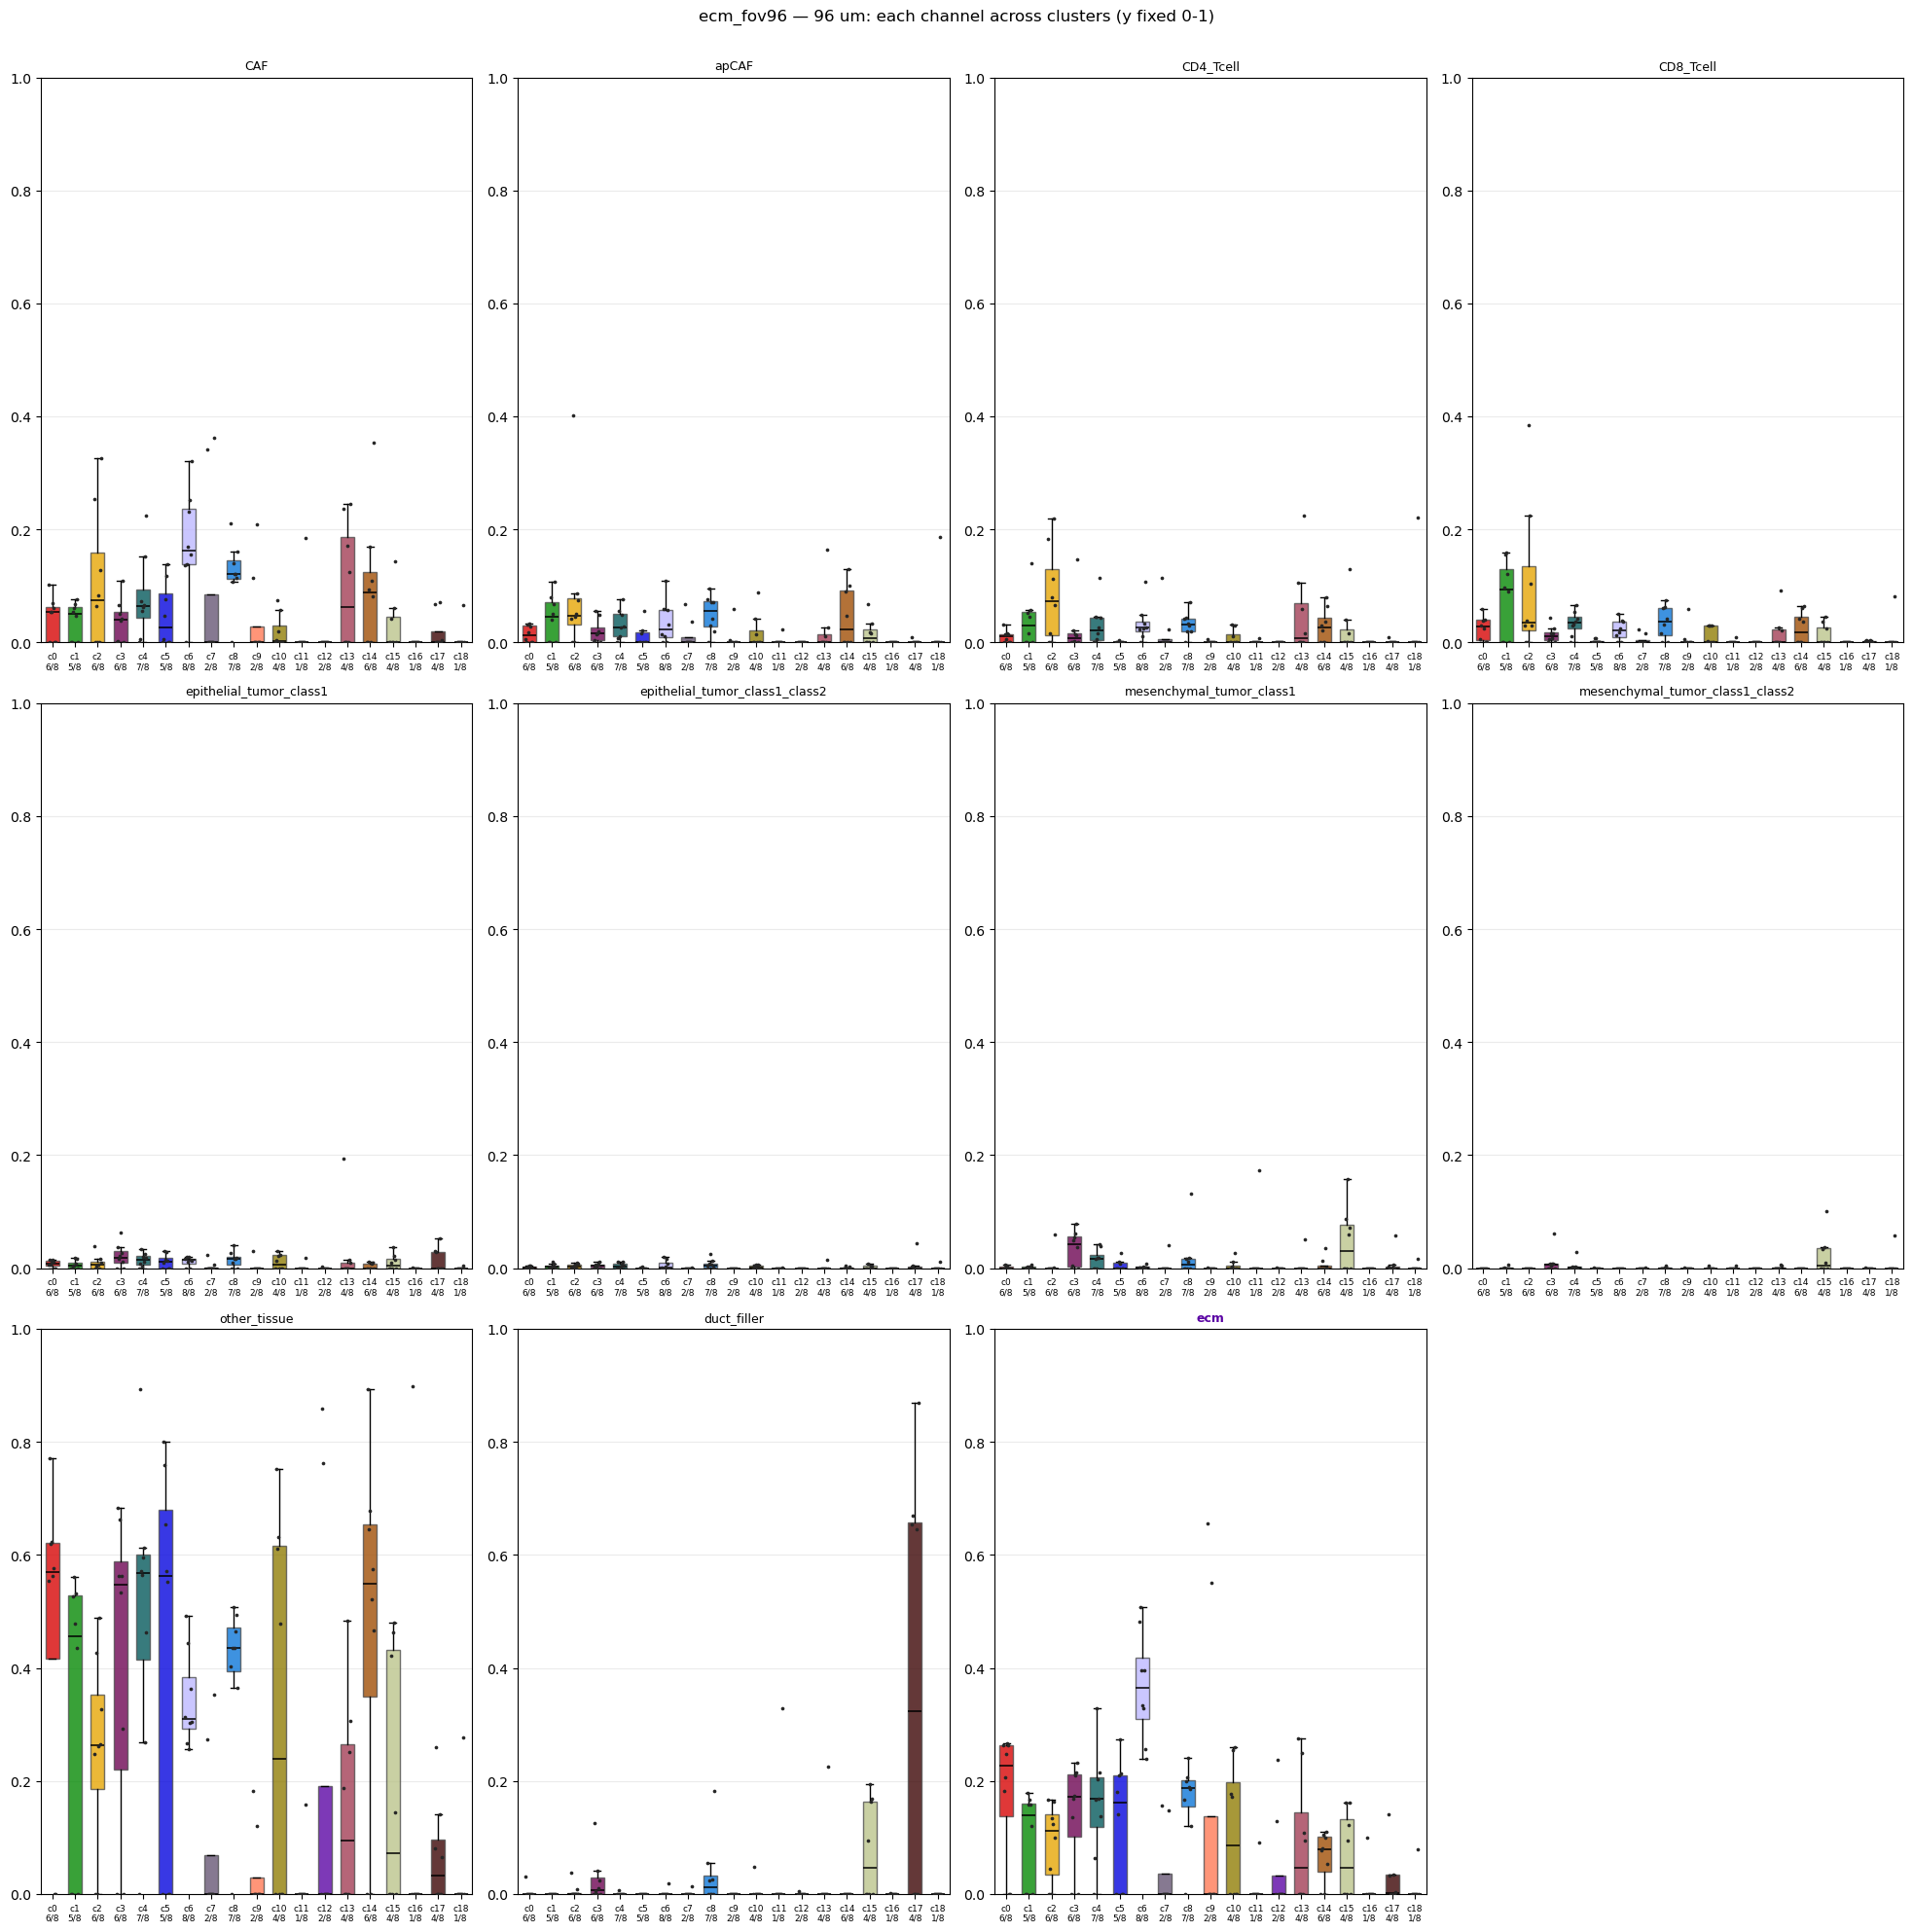

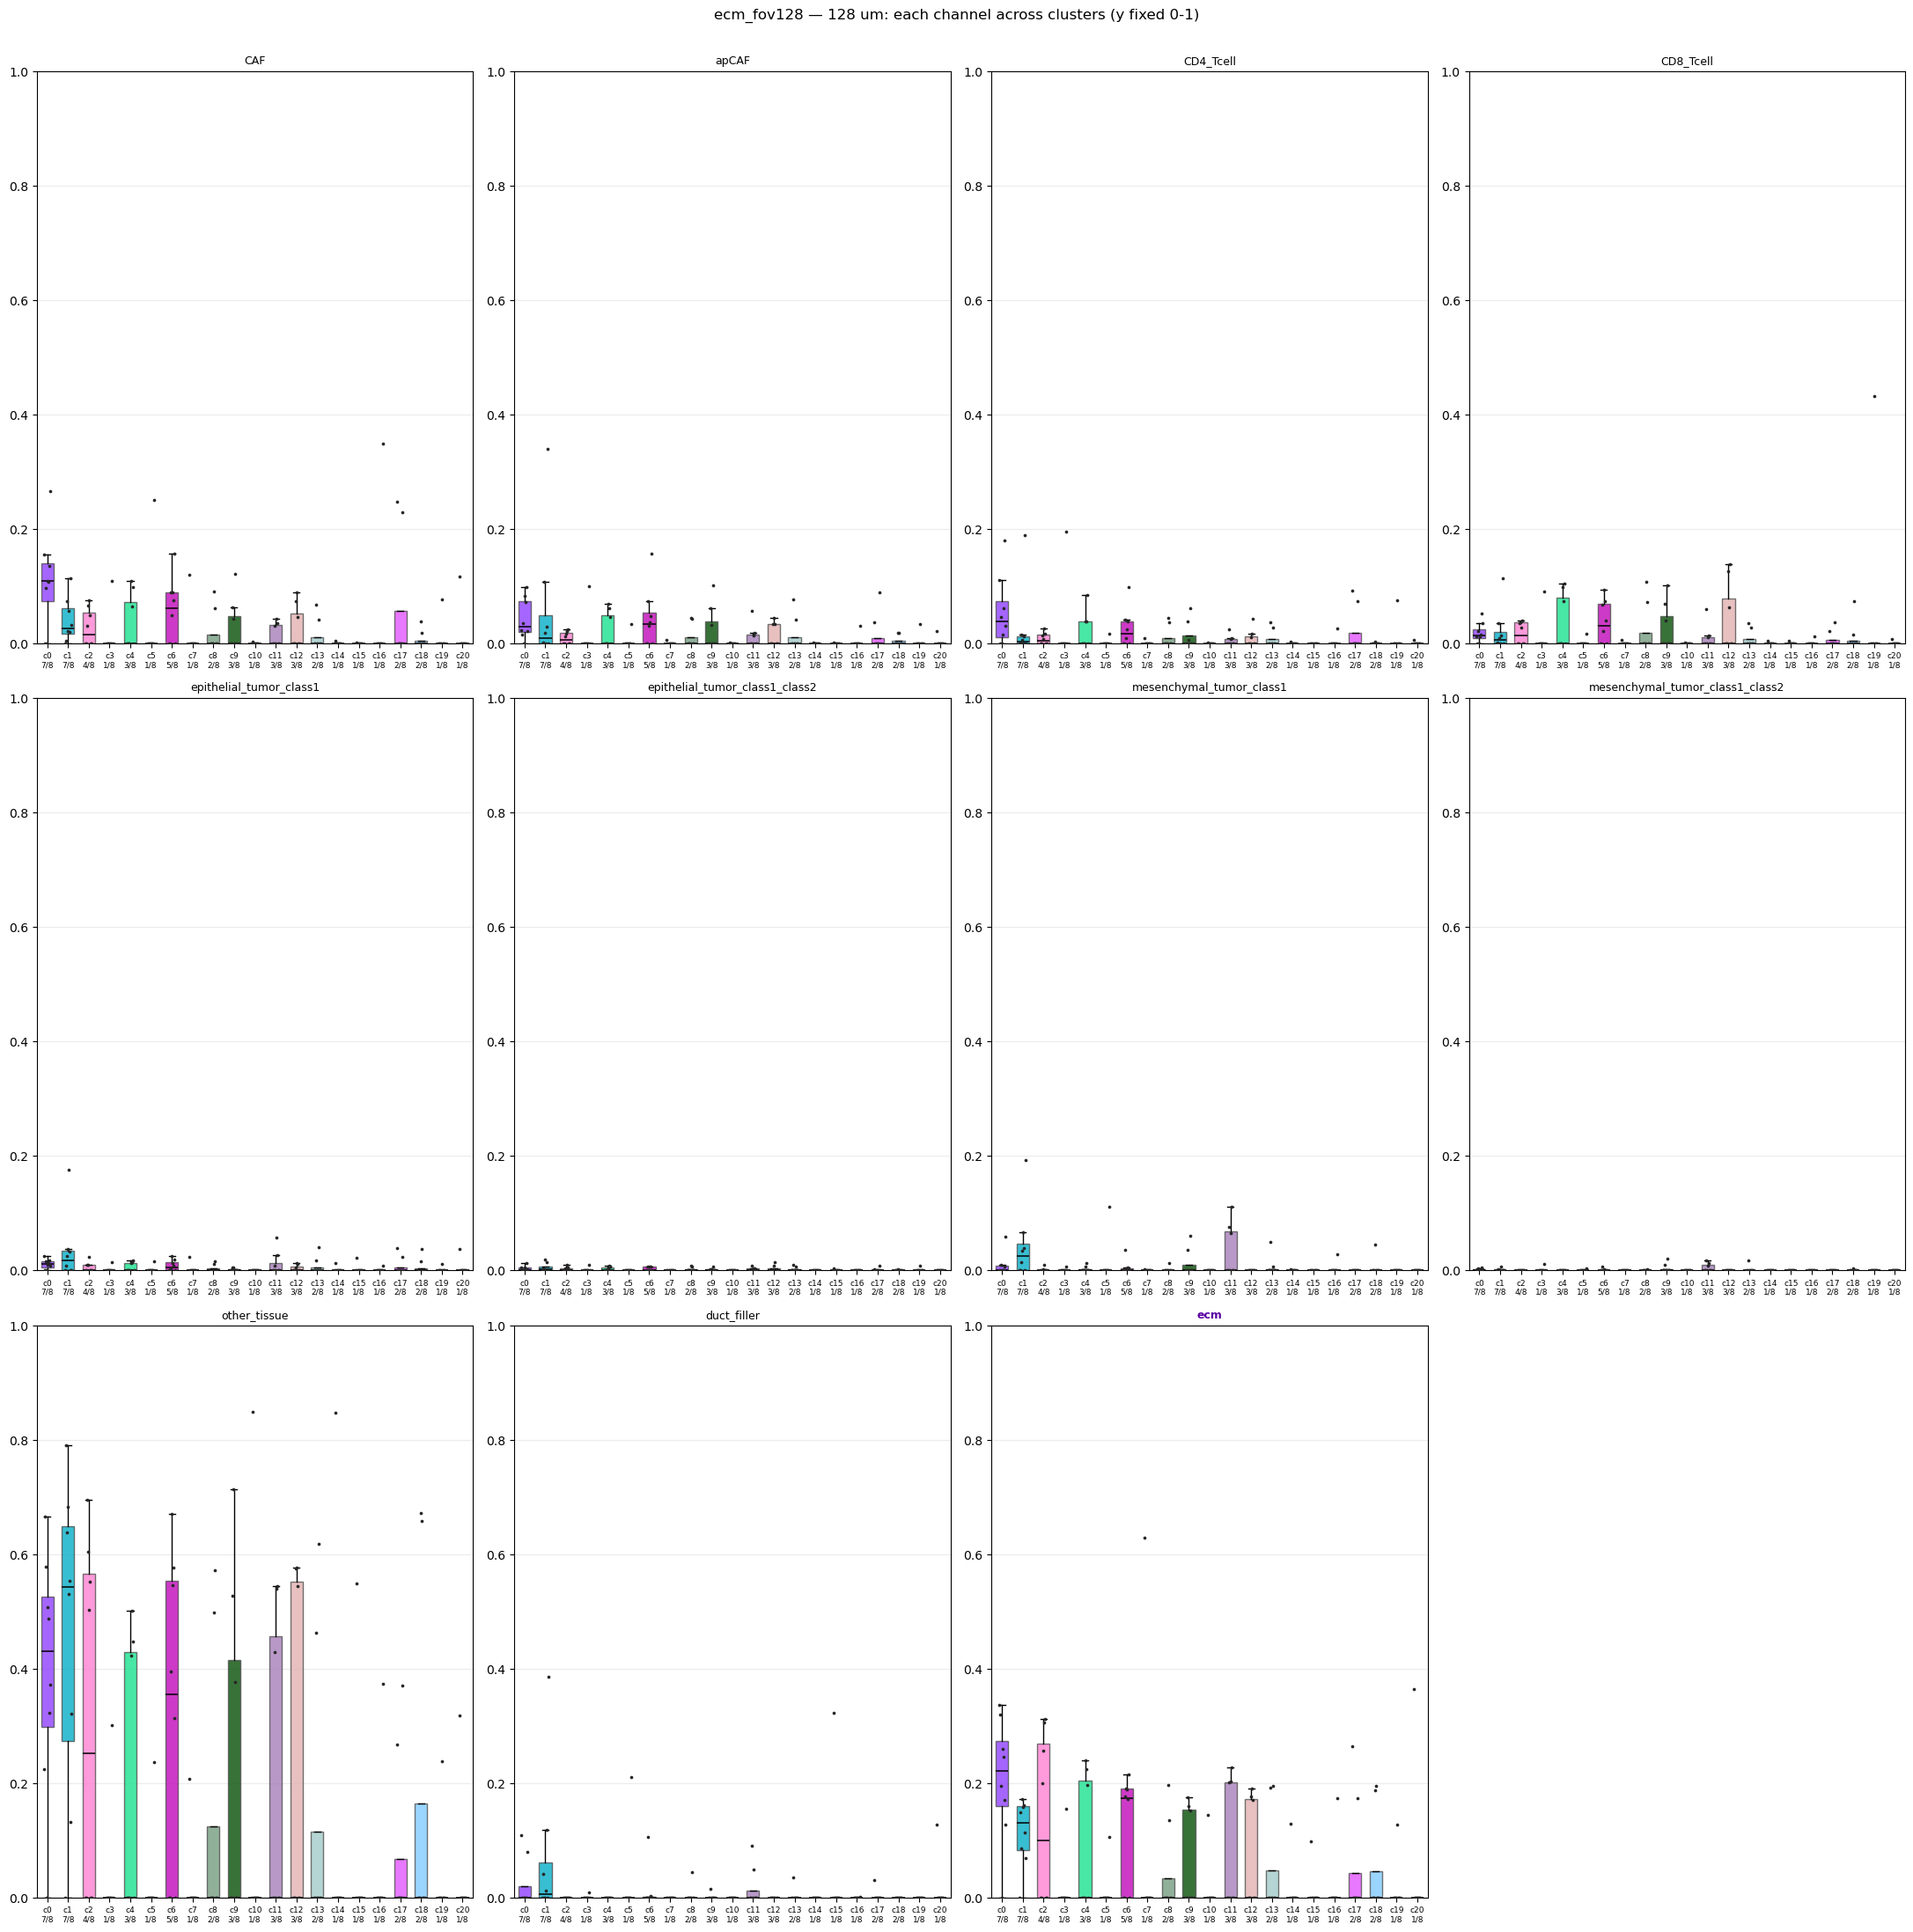

In [13]:
for k in CONFIGS:
    fig = grid_by_type(k, 1.0)
    fig.suptitle("{} — {} um: each channel across clusters (y fixed 0-1)".format(k, CONFIGS[k]),
                 y=1.003, fontsize=12)
    plt.tight_layout(); plt.show()

### b2. Channel per panel, y rescaled per channel

Each panel runs 0 to that channel's largest value across **all** configs, so the grids
stay comparable to each other while low-abundance channels become readable.

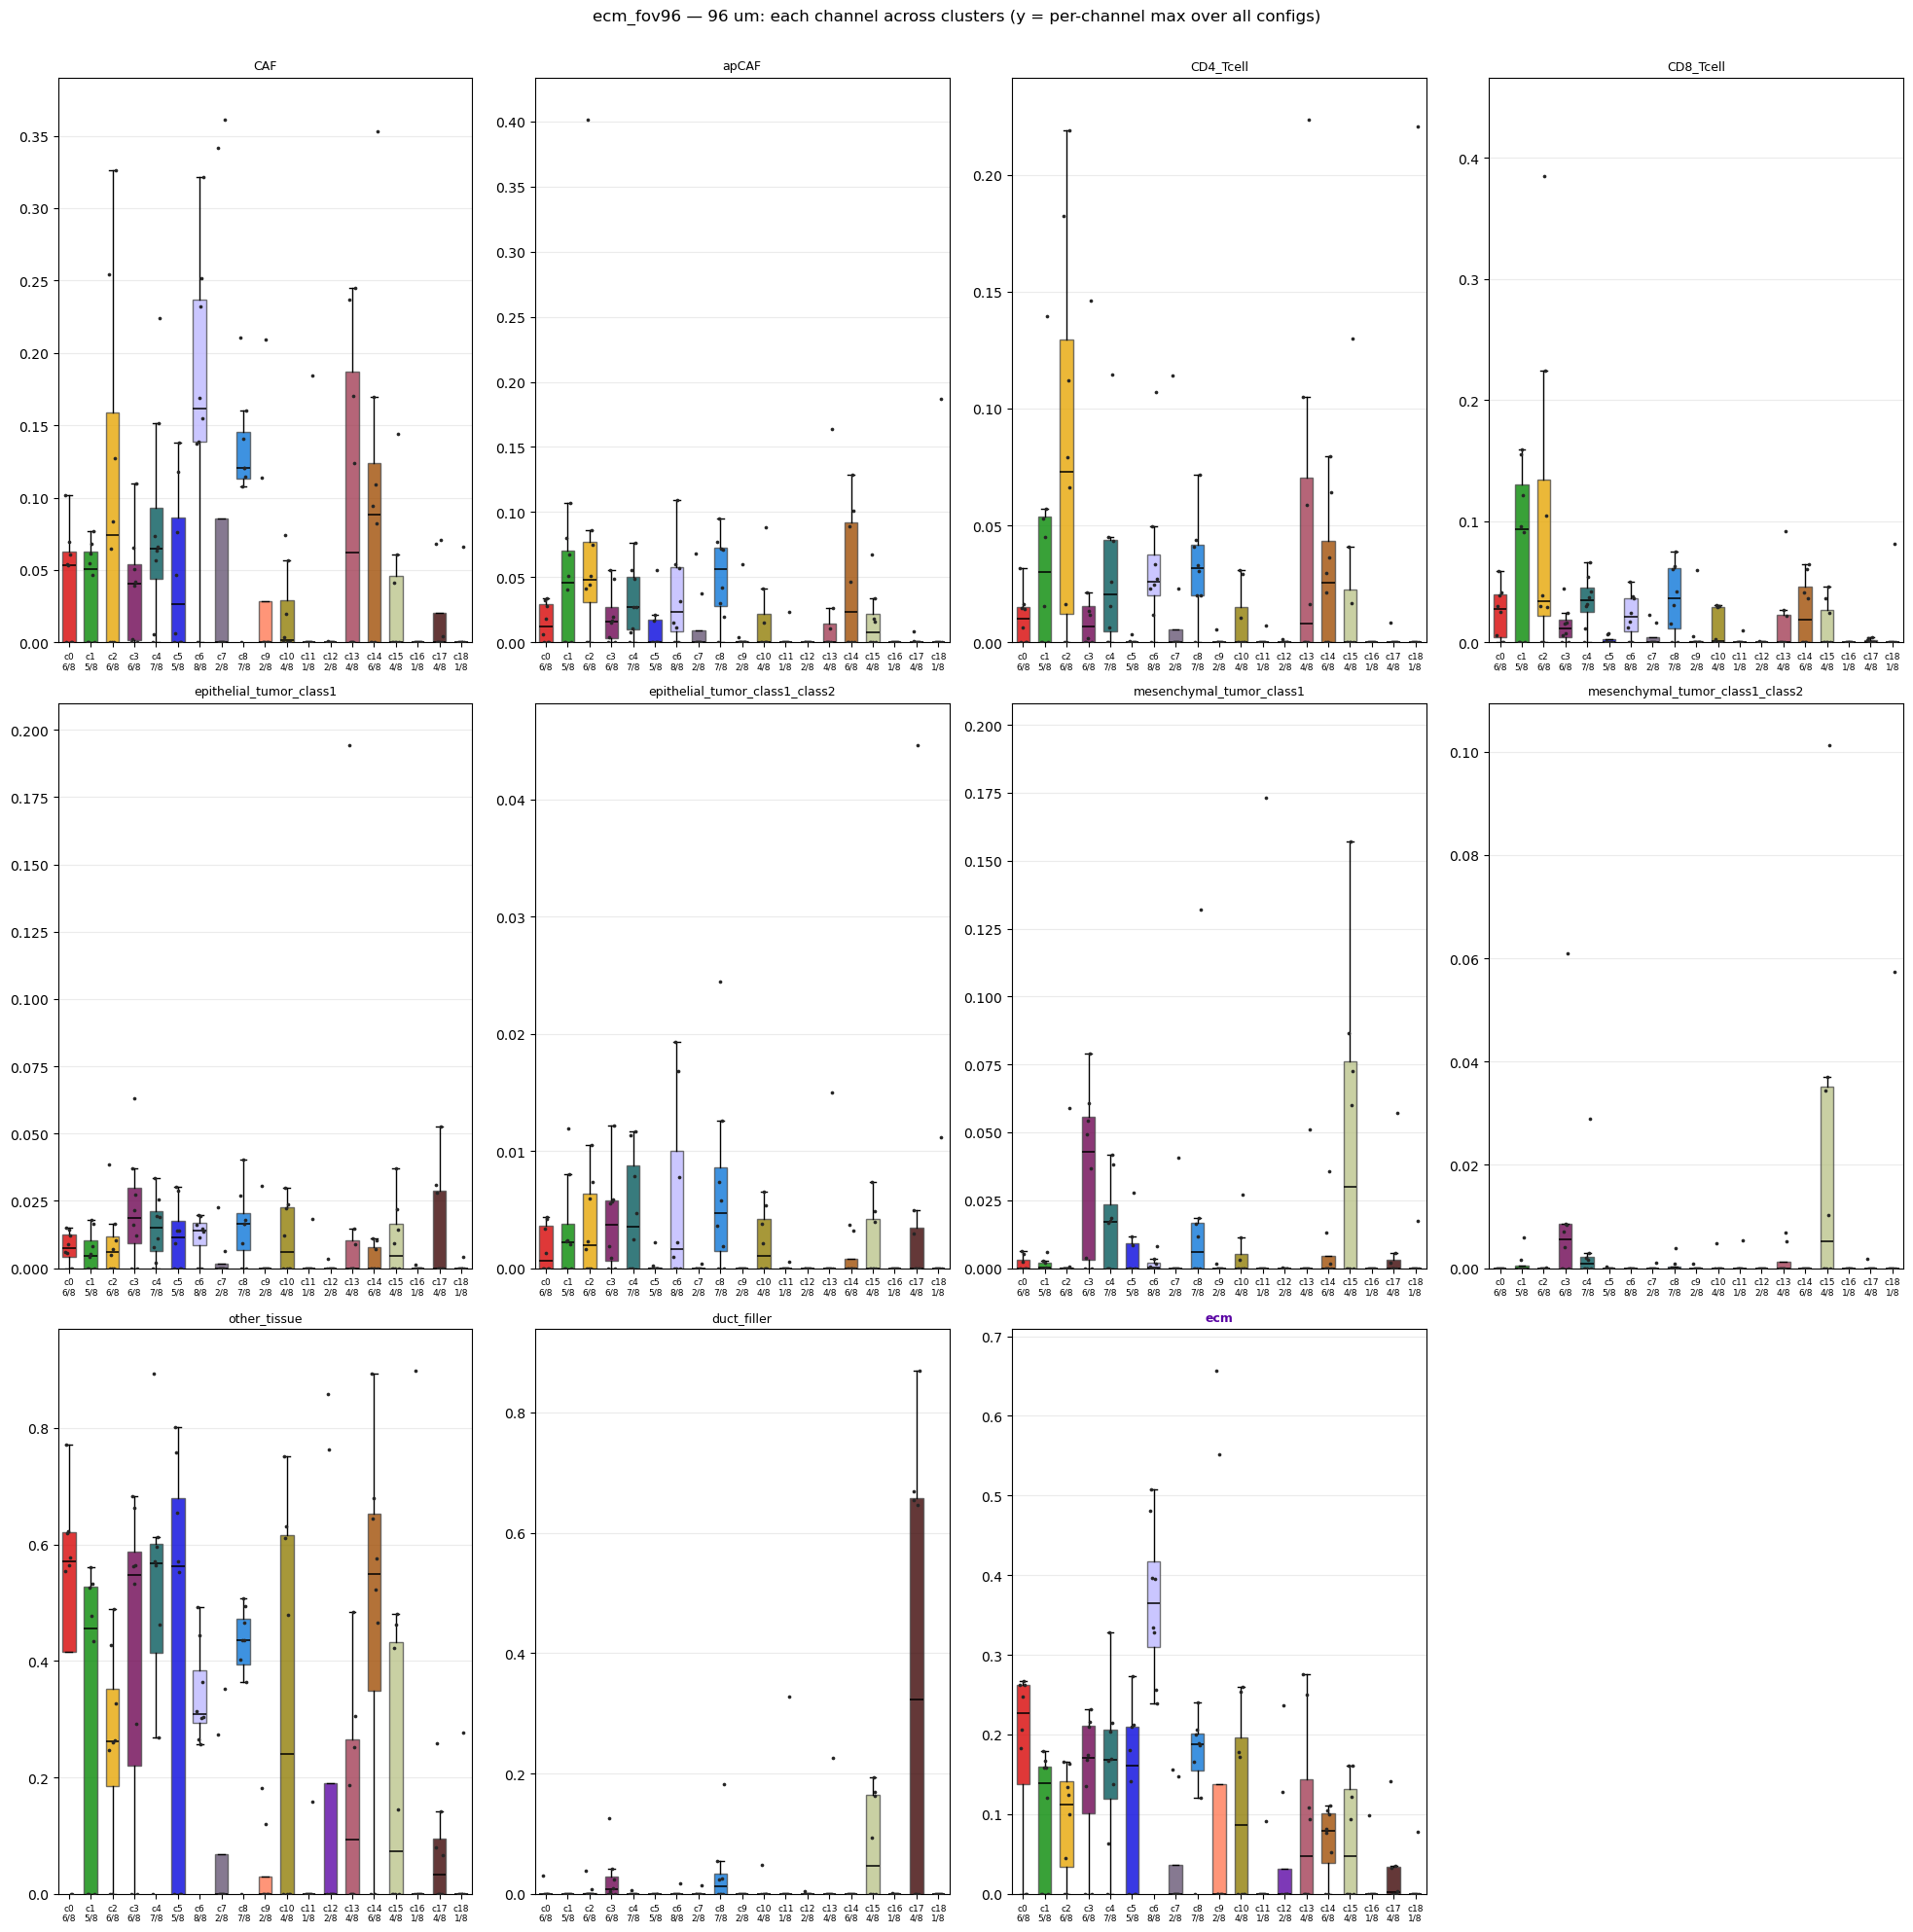

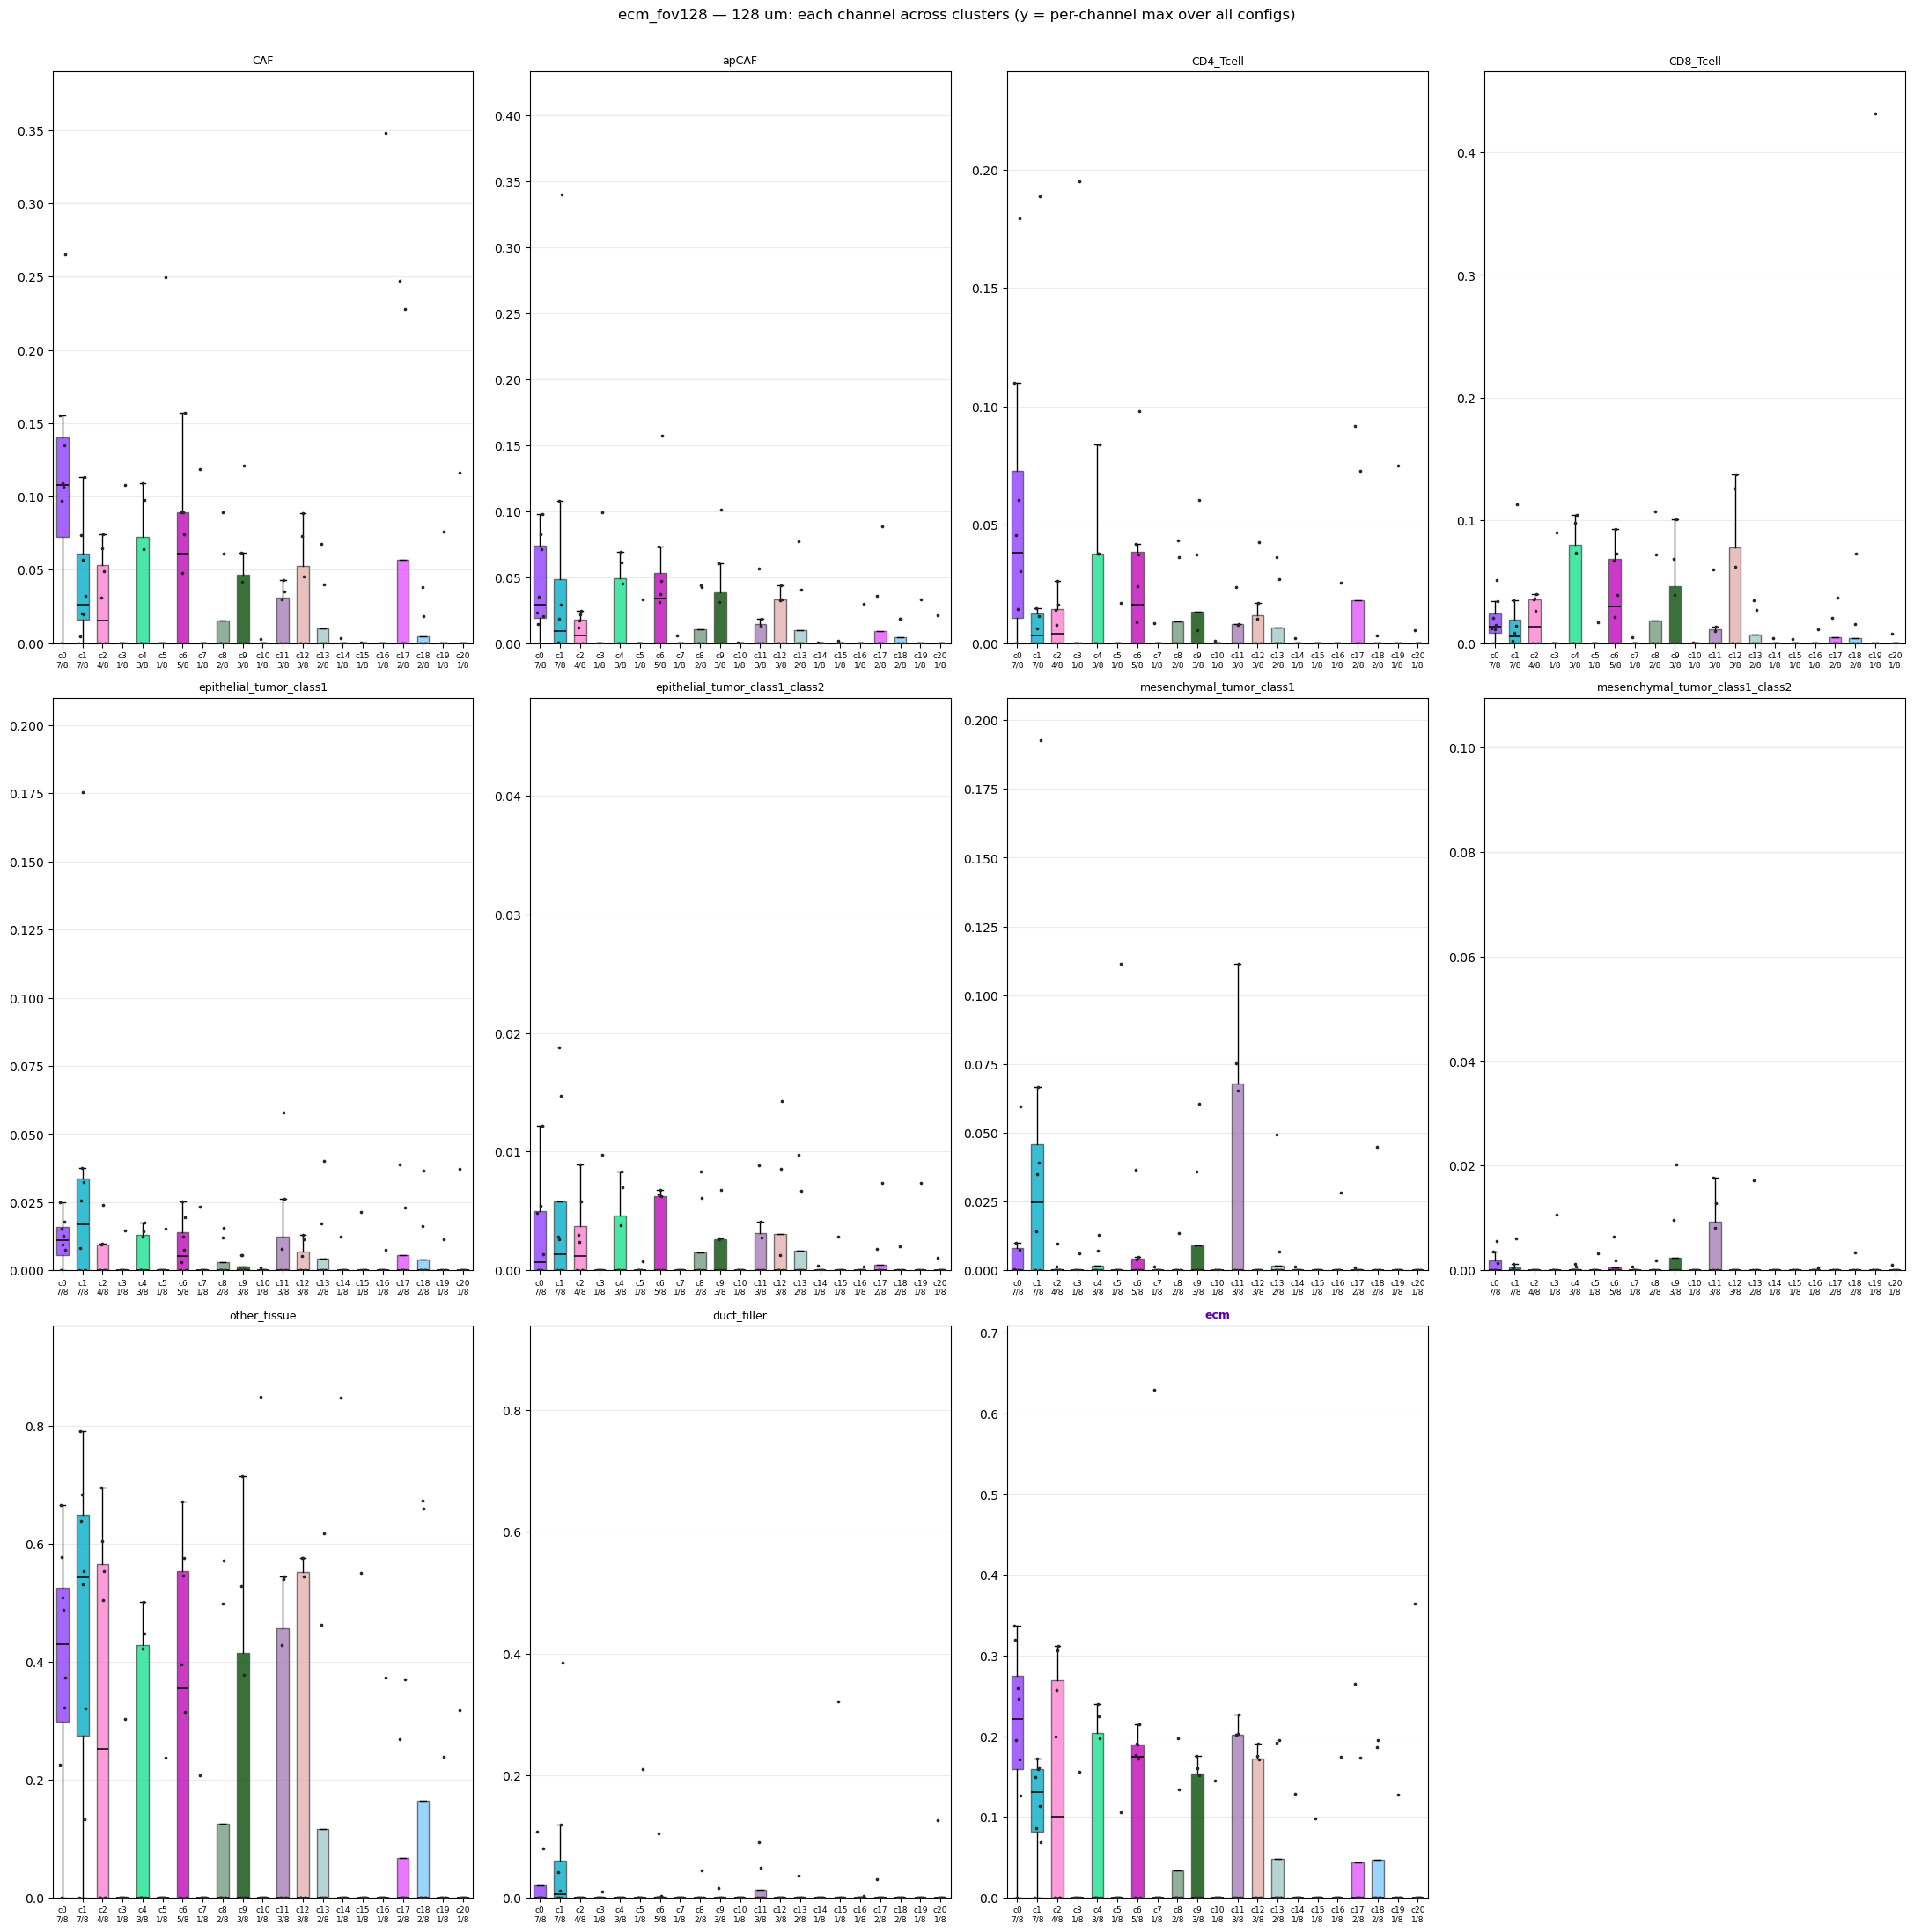

In [14]:
for k in CONFIGS:
    fig = grid_by_type(k, YMAX_TYPE)
    fig.suptitle("{} — {} um: each channel across clusters "
                 "(y = per-channel max over all configs)".format(k, CONFIGS[k]),
                 y=1.003, fontsize=12)
    plt.tight_layout(); plt.show()

### c1. Cluster per panel, all eleven channels, y fixed 0–1

The two greys are usually the tallest boxes; that is the honest picture, since most
windows are mostly background. Values in a panel sum to 1.

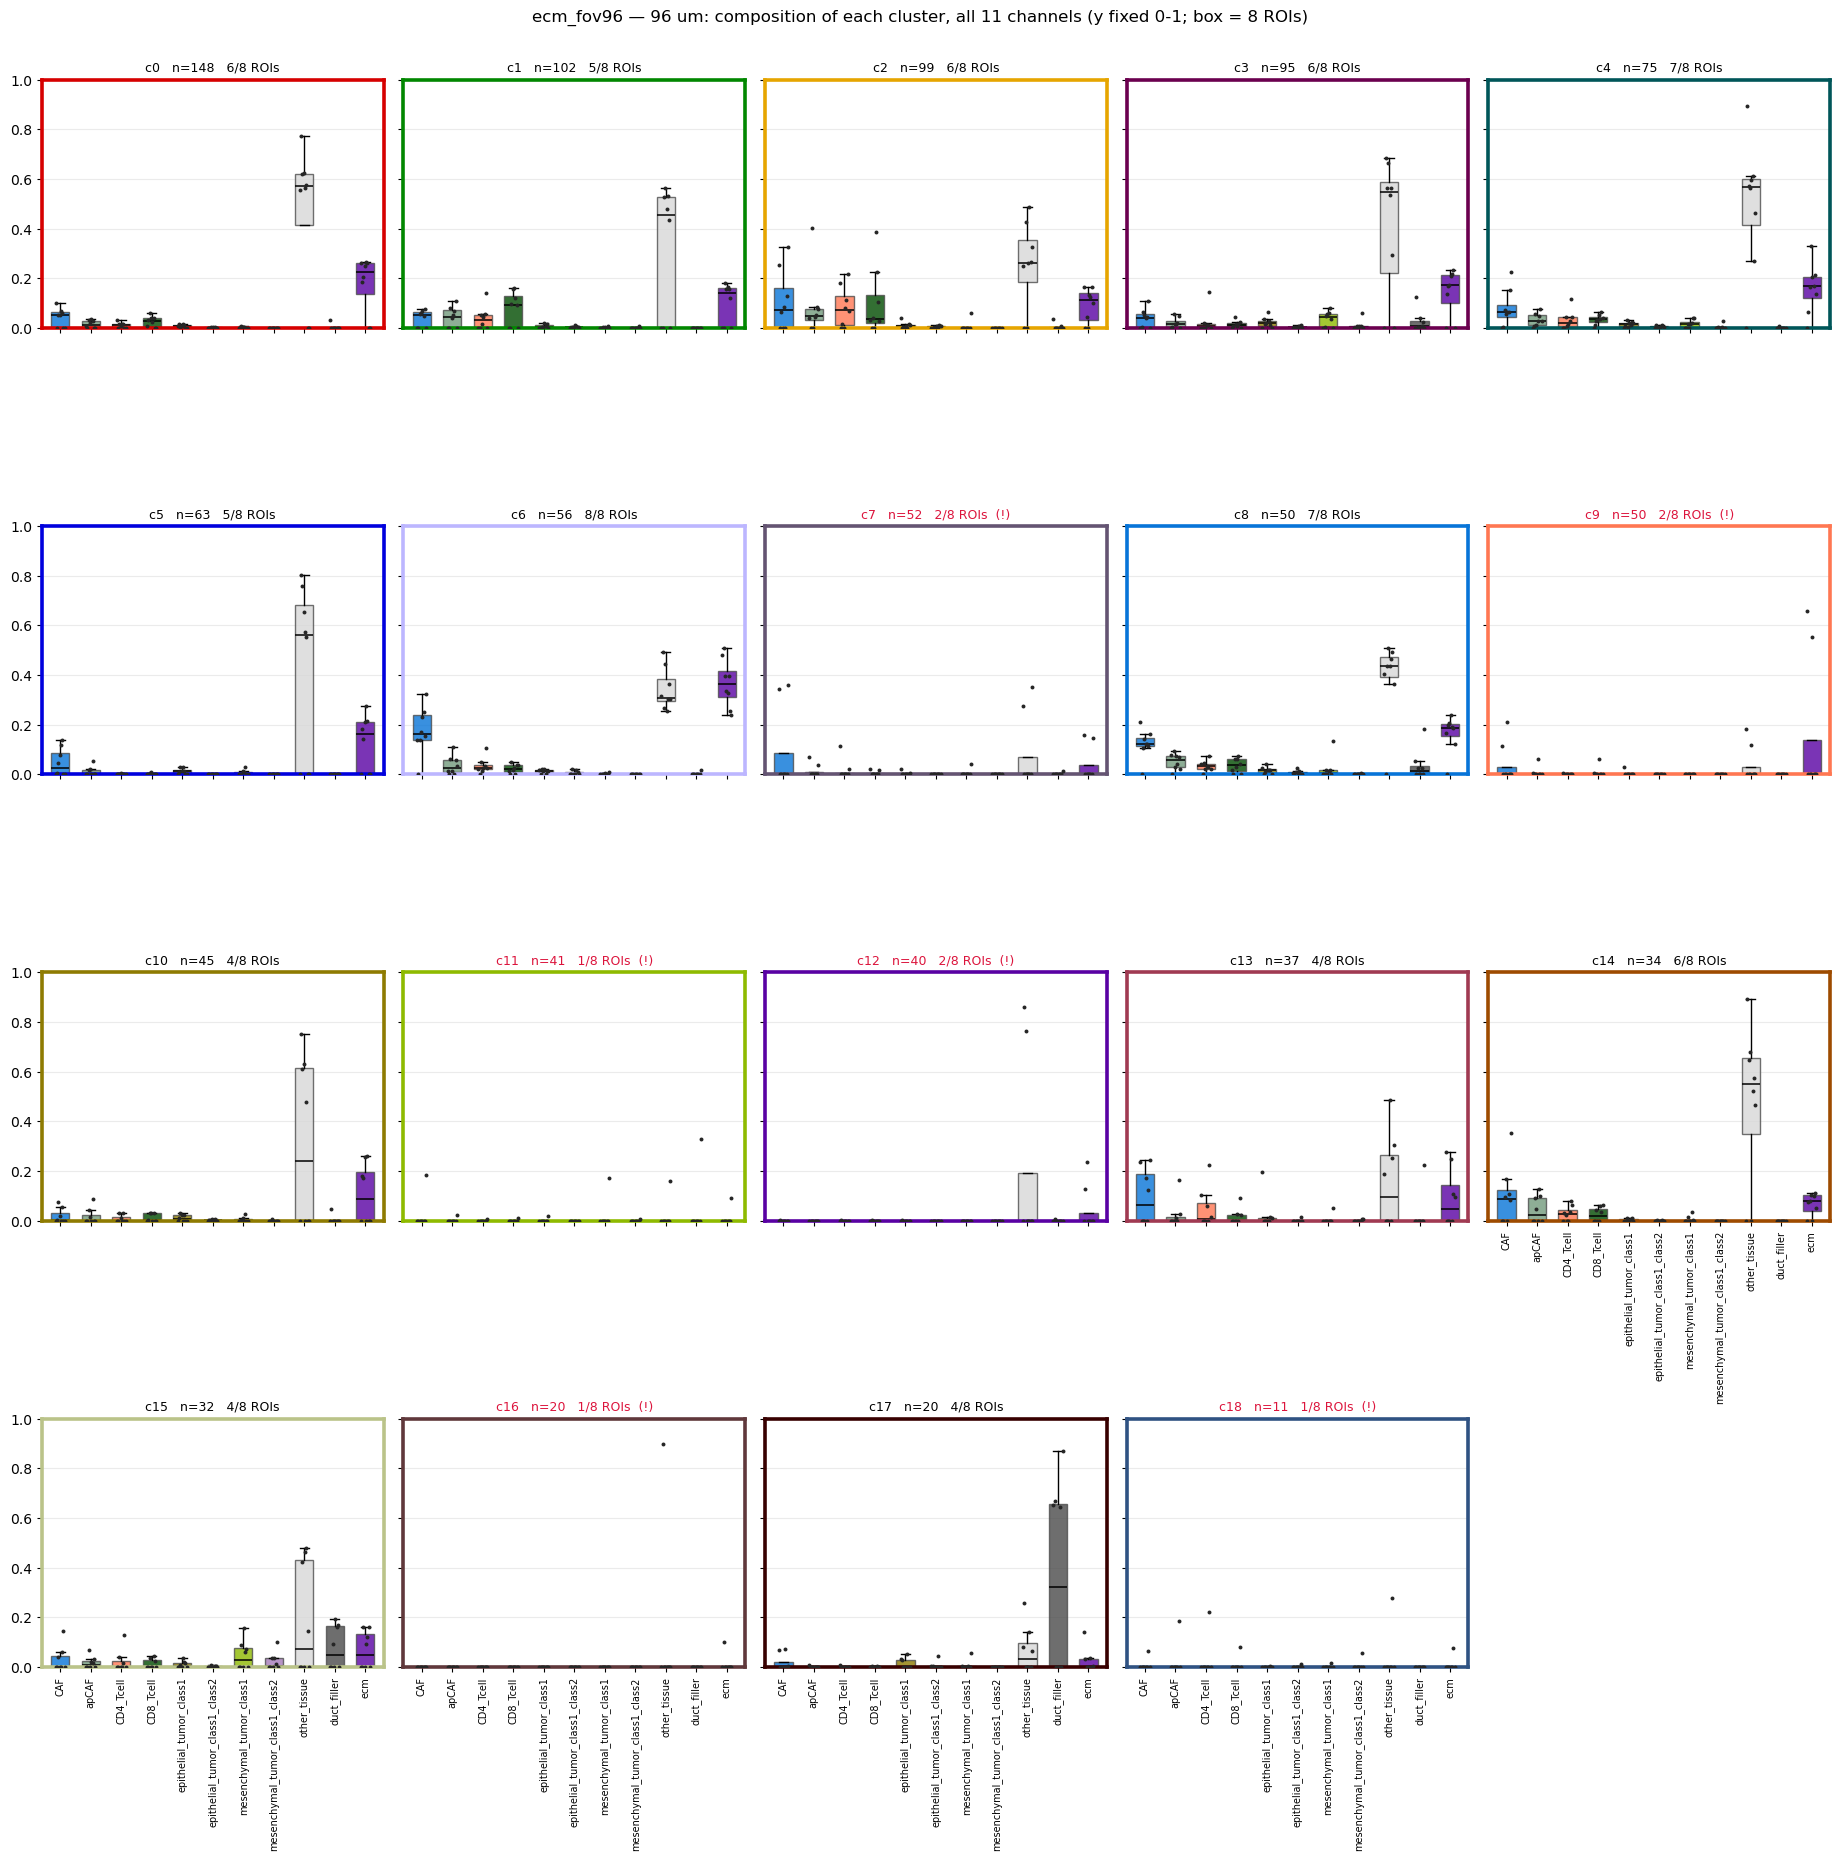

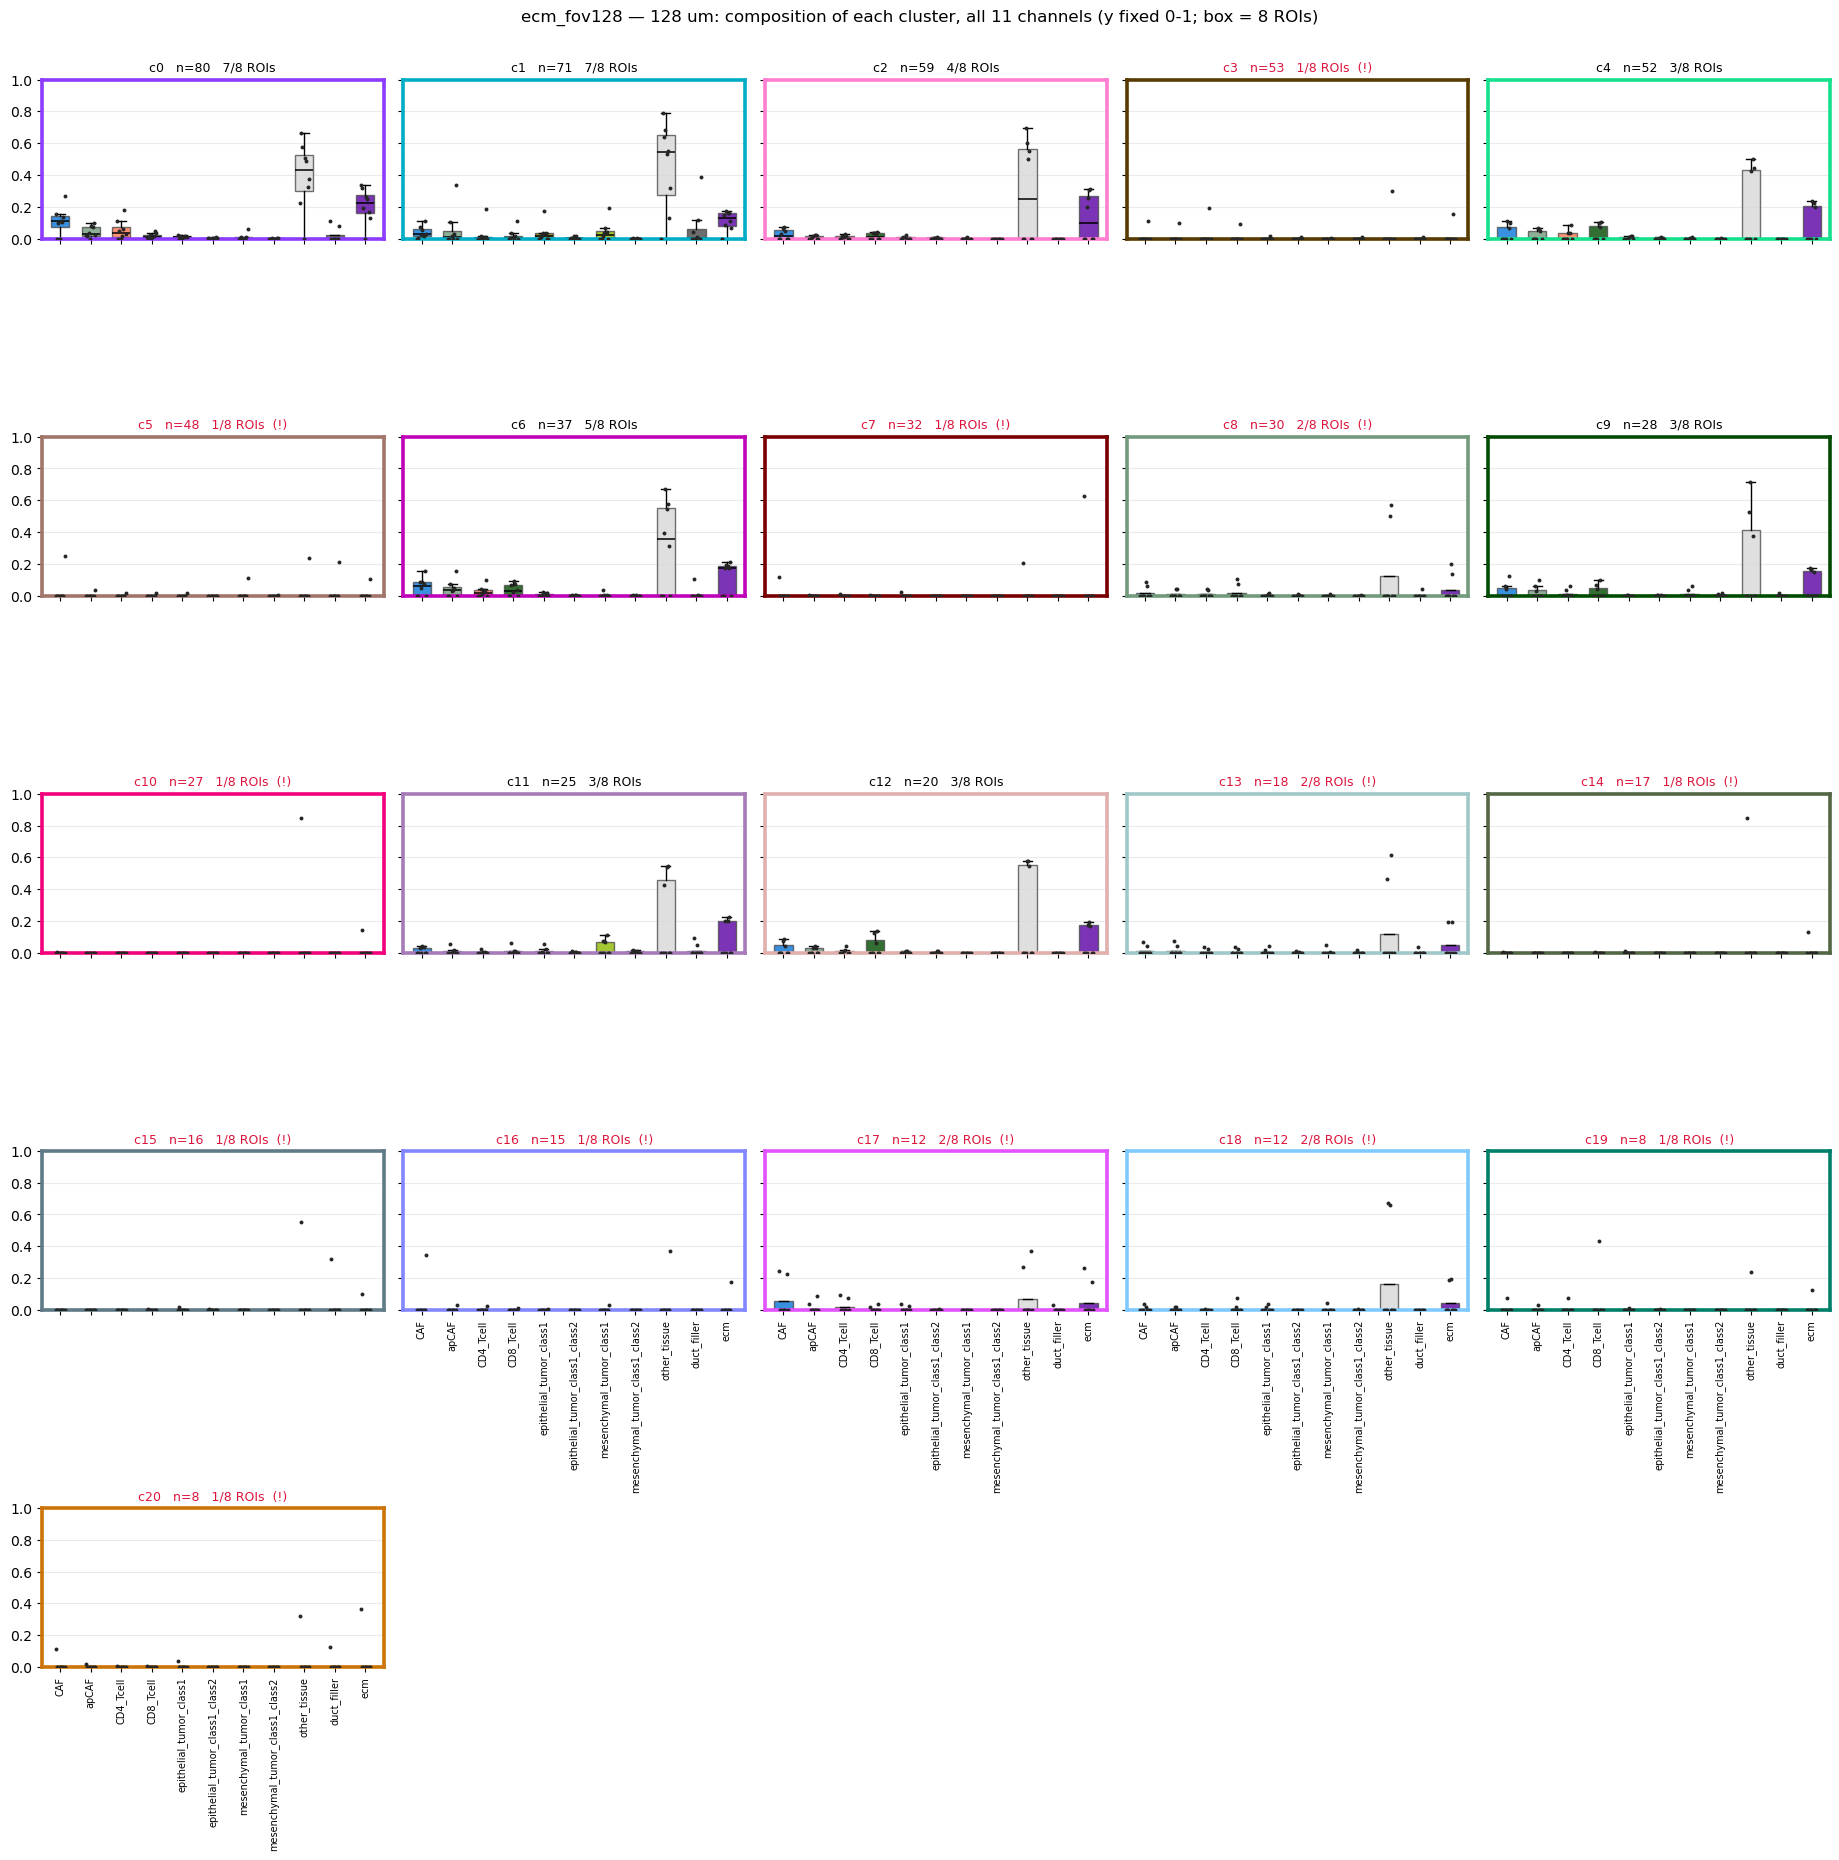

In [15]:
for k in CONFIGS:
    fig = grid_by_cluster(k, CHANNELS, 1.0)
    fig.suptitle("{} — {} um: composition of each cluster, all 11 channels "
                 "(y fixed 0-1; box = {} ROIs)".format(k, CONFIGS[k], len(ROIS)),
                 y=1.003, fontsize=12)
    plt.tight_layout(); plt.show()

### c2. Cluster per panel, biology + ECM only, y rescaled

Same numbers as c1 — still fractions of **all** eleven channels, background included in
the arithmetic — but the two background types are dropped from the x-axis and the y-axis
is rescaled to the largest biology-or-ECM value across all configs. The nine boxes
therefore do **not** sum to 1.

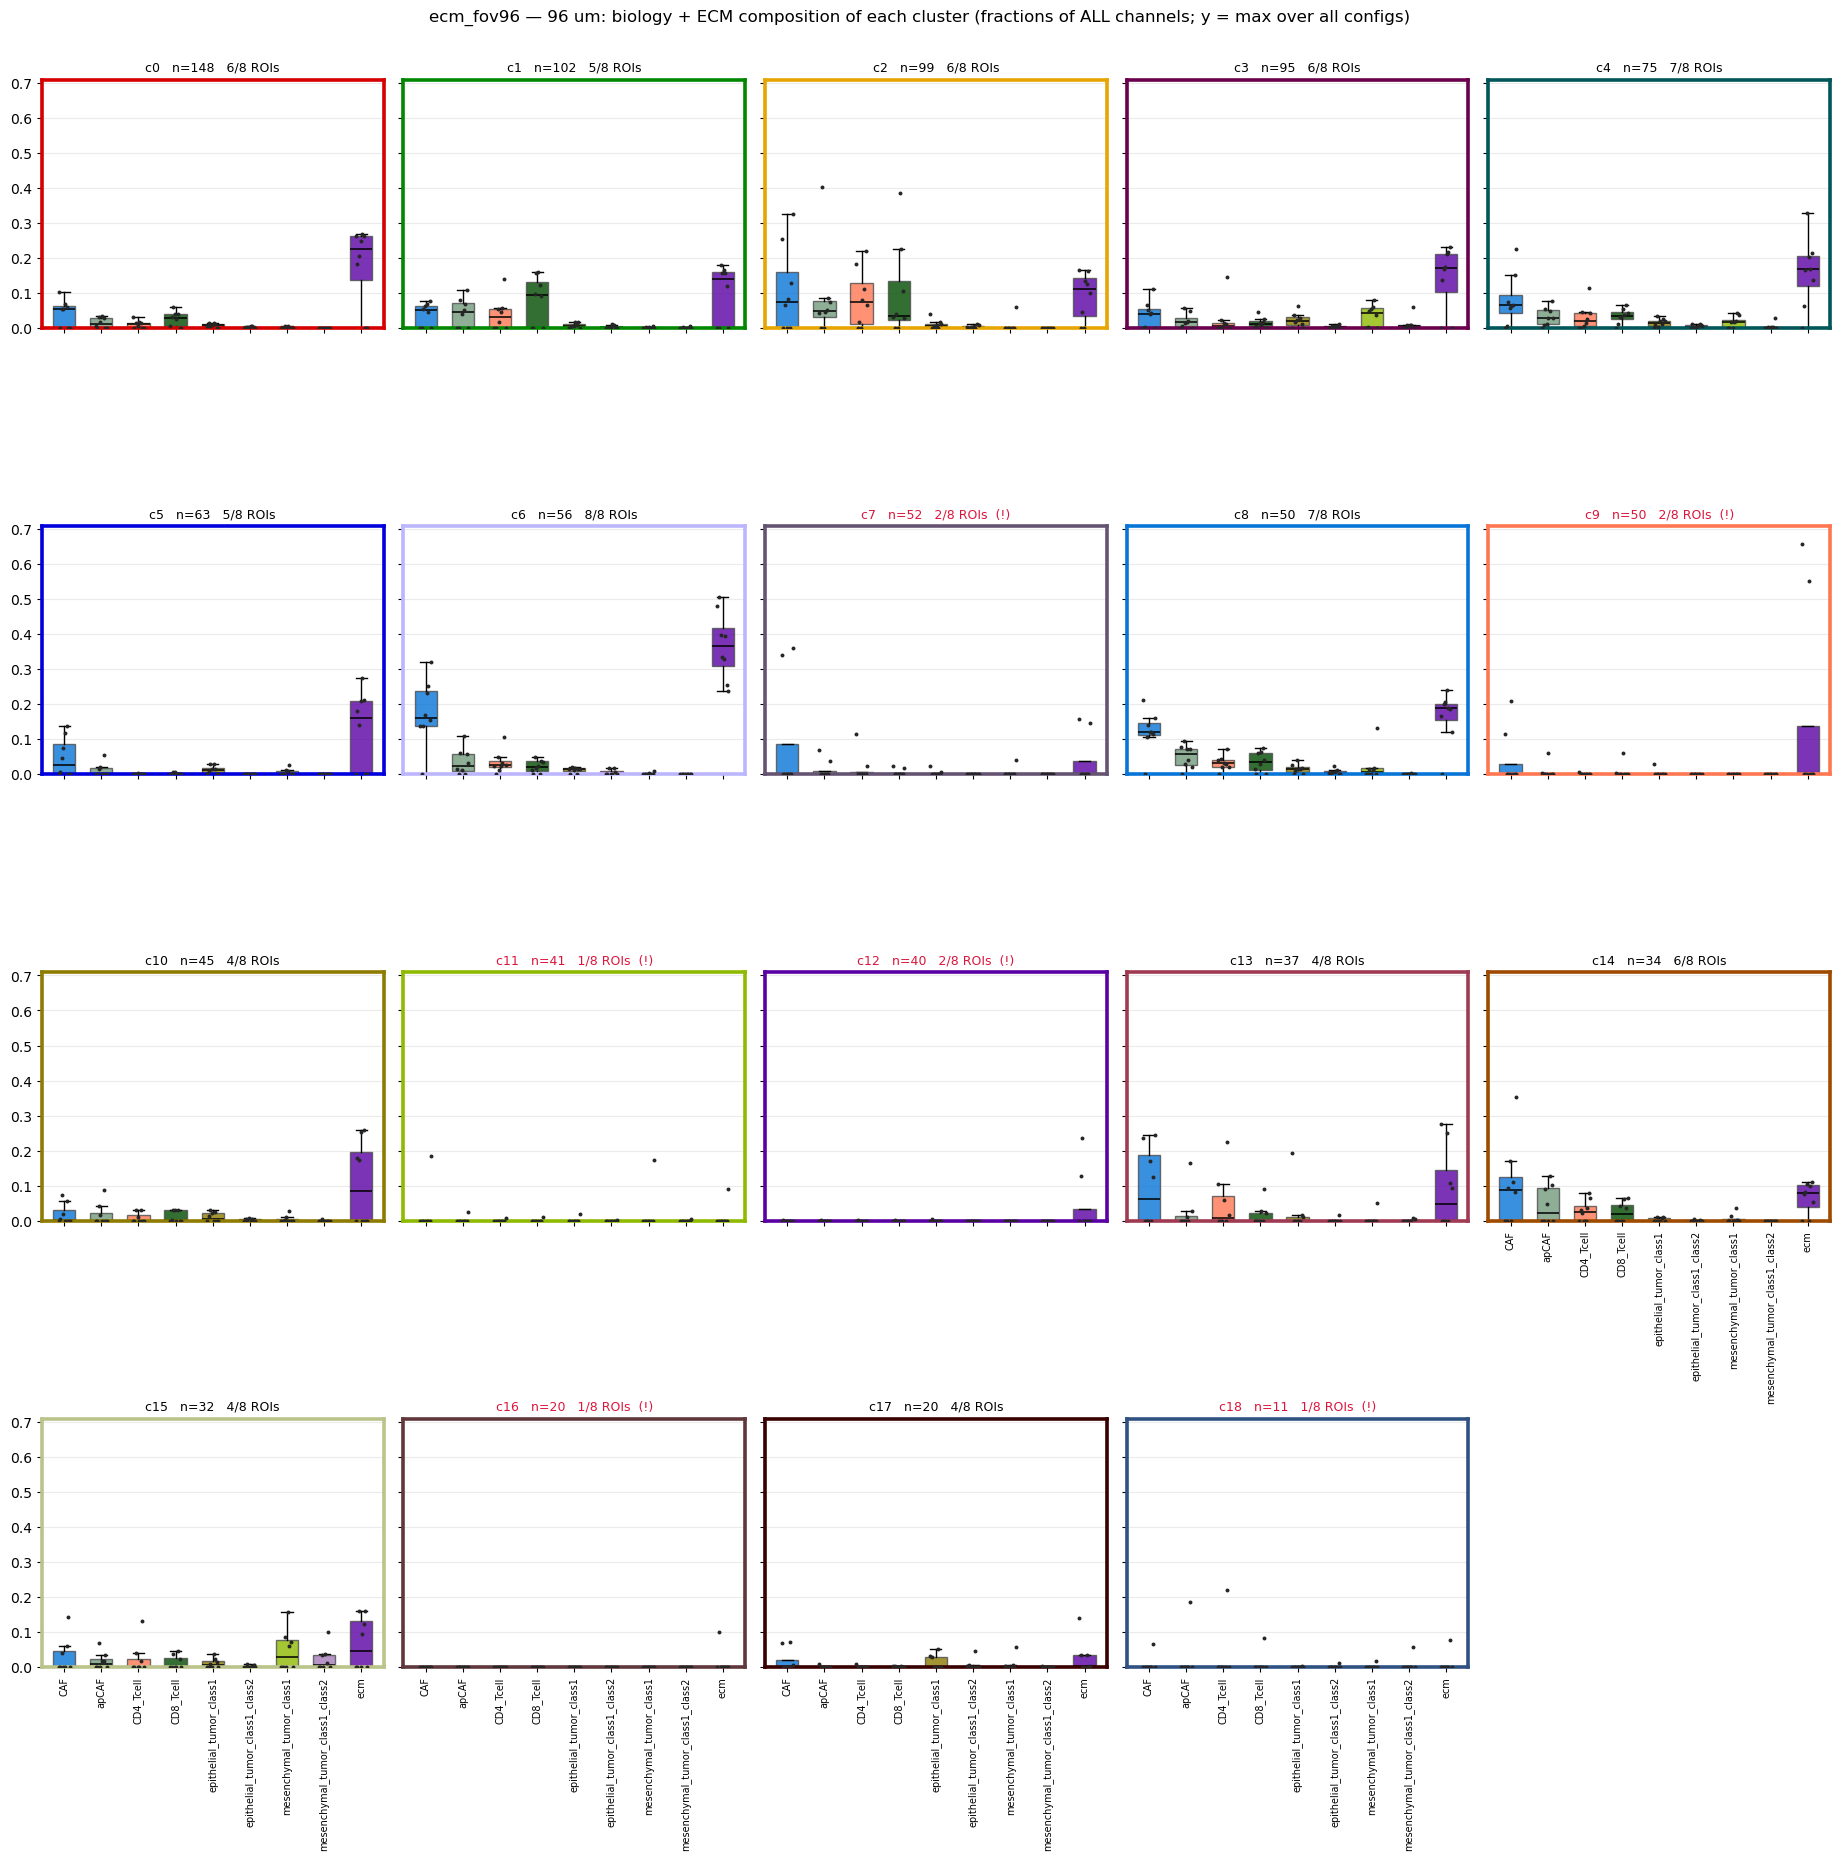

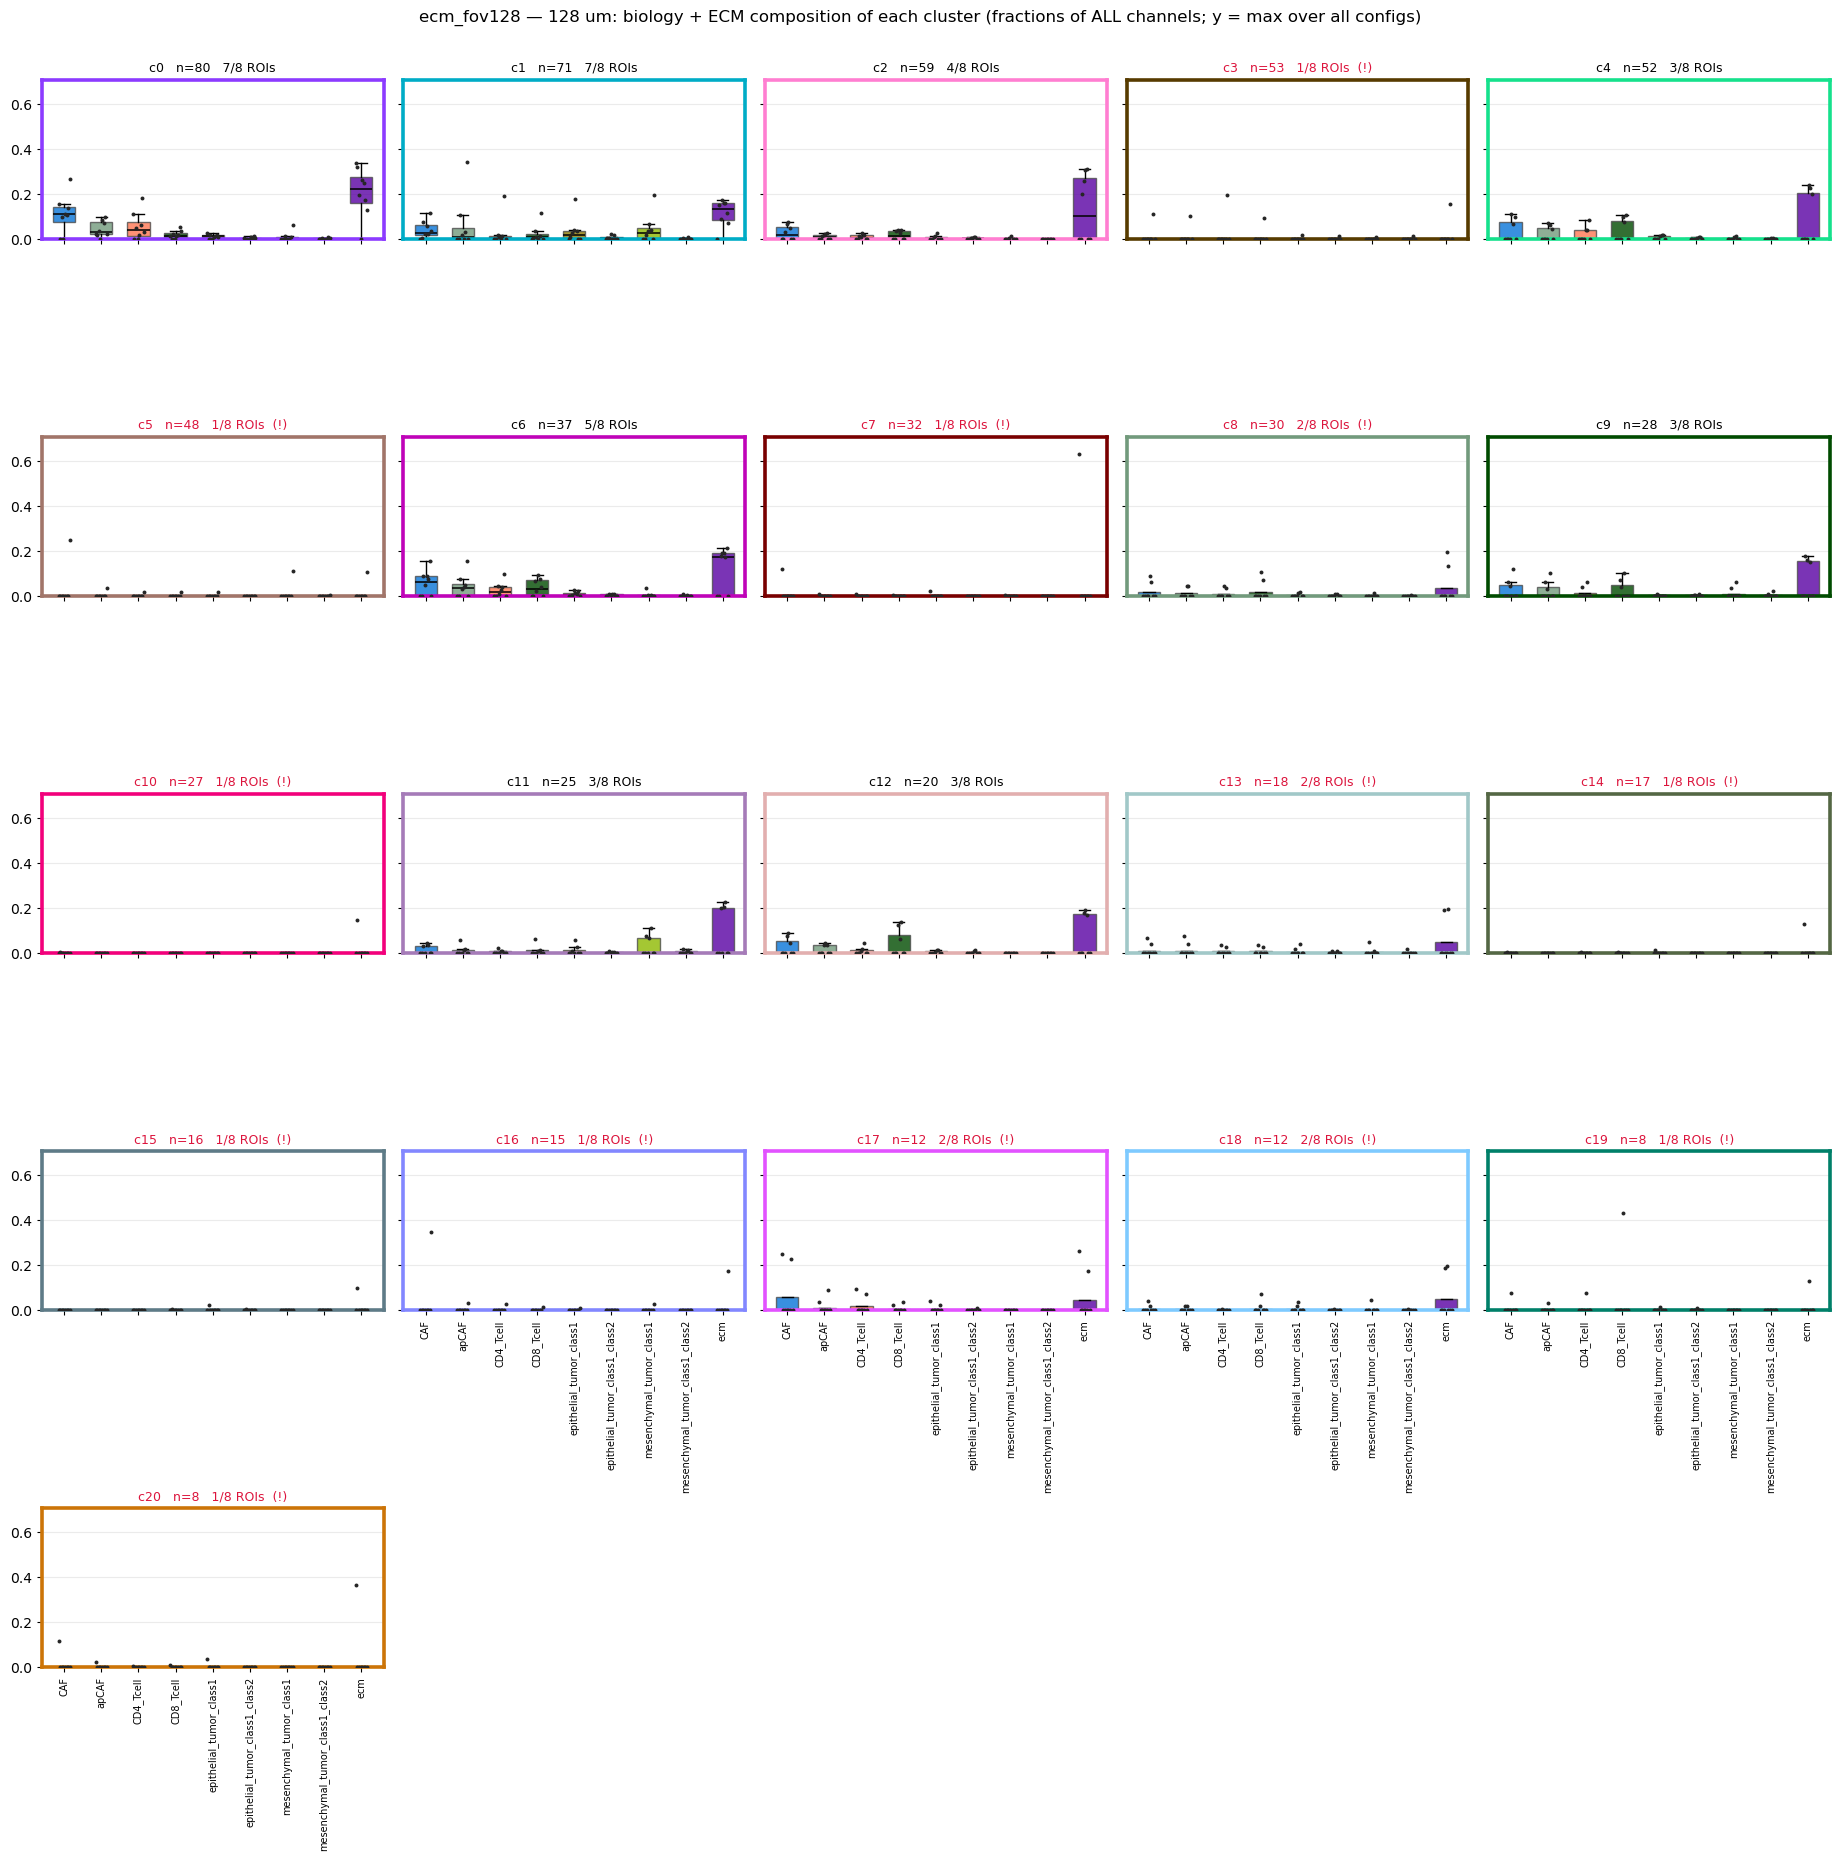

In [16]:
for k in CONFIGS:
    fig = grid_by_cluster(k, BIO_ECM, YMAX_BIO)
    fig.suptitle("{} — {} um: biology + ECM composition of each cluster "
                 "(fractions of ALL channels; y = max over all configs)".format(k, CONFIGS[k]),
                 y=1.003, fontsize=12)
    plt.tight_layout(); plt.show()

## Do the motifs carry more than cell-type composition?

Everything above shows the clusters are spatially coherent. That is not the same as showing
they know something a **cell-type composition vector** does not. This section tests that
directly, and it is entirely post-hoc — cell coordinates, window bounds and embeddings, no
model forward passes.

### The control is not composition alone

A fraction vector carries neither cell **density** nor how much of the window sits **on
tissue**, and the embedding demonstrably encodes both — clustering η² on the ECM voxel
count alone, a quantity with no biology in it whatsoever, reached 0.65 here. A model that
only knew *"half off the edge, 300 cells"* would beat a composition baseline and look like
it had found motifs. So the control is

`[10 composition fractions, log n_cells, ecm_voxels, ecm_density]`

and the claim is only ever "beyond **all** of that", matrix included.

### The targets are arrangement, normalised for composition

Each is an observed neighbour fraction **minus** the window-level fraction of that type, so
a type being abundant cannot make its score high — only its being clumped (positive) or
dispersed (negative) can:

| | |
|---|---|
| `homo_<type>` | how much type *t*'s neighbours are *t*, above chance for that window |
| `mixing` | fraction of kNN edges joining *different* types; low = segregated |
| `enr_A__B` | how much of A's neighbourhood is B, above B's share of the window |

The `enr_` pairs are the ones this project exists to ask about. Two windows can hold
identical CD8 and tumour counts with the T cells either infiltrating or excluded at the
margin, and no composition vector can tell them apart.

### Nested, not head-to-head

The embedding obviously encodes composition; comparing the two directly would just
re-measure that. So the comparison is nested — **ΔR² = R²(control + embedding) −
R²(control)** — which asks only about the part composition cannot reach.

### Two guards, both load-bearing

**Spatial-block folds, not ROI folds.** Adjacent windows share cells, so random folds leak
and every R² inflates. But holding out whole *ROIs* overshoots: that demands cross-patient
transfer, a different and much harder question than whether the information is present.
MEASURED with ROI folds, the control scored R² 0.58 on `mixing` and 0.003 on apCAF–CD8
enrichment — no headroom left for the embedding to add anything. Each ROI is therefore
split into spatial quadrants and quadrant *k* is held out across all ROIs at once.

**A permutation null.** A 16-PC predictor beats a 13-feature one on almost anything through
flexibility alone, so a positive Δ means nothing by itself. Embedding rows are shuffled
**within each ROI** — preserving every ROI-level effect, destroying only the window-to-window
correspondence — and Δ is regenerated from pure capacity. Only the excess over that null counts.

In [17]:
from sklearn.decomposition import PCA

N_PC, N_PERM, N_SPLIT = 16, 200, 2

ARR, CTRL, EMB, BLK, ROI_G = {}, {}, {}, {}, {}
for k in CONFIGS:
    w = W[k]
    ARR[k] = imc_tm.arrangement_targets(w, cells)
    CTRL[k] = imc_tm.control_features(w, MASS[k], COUNT[k])
    EMB[k] = PCA(n_components=N_PC, random_state=0).fit_transform(np.asarray(w.X, dtype=float))
    ROI_G[k] = np.asarray(w.obs.roi).astype(str)
    BLK[k] = imc_tm.spatial_blocks(w.obsm["spatial"], ROI_G[k], n_split=N_SPLIT)
    print("{:<11s} {:4d} windows | control {} | {} targets | folds {}".format(
        k, w.n_obs, CTRL[k].shape[1], ARR[k].shape[1], np.bincount(BLK[k]).tolist()))

TARGETS = [c for c in ARR[list(CONFIGS)[0]].columns
           if min(ARR[k][c].notna().sum() for k in CONFIGS) >= 120]
print()
print("targets with >=120 defined windows in every config:")
print("  " + ", ".join(TARGETS))

ecm_fov96   1070 windows | control 13 | 16 targets | folds [307, 273, 261, 229]


ecm_fov128   668 windows | control 13 | 16 targets | folds [194, 170, 164, 140]

targets with >=120 defined windows in every config:
  homo_CAF, homo_apCAF, homo_CD4_Tcell, homo_CD8_Tcell, homo_mesenchymal_tumor_class1, homo_other_tissue, mixing, enr_apCAF__CD8_Tcell, enr_CD8_Tcell__apCAF, enr_CD8_Tcell__epithelial_tumor_class1, enr_CD4_Tcell__apCAF, enr_CAF__CD8_Tcell


In [18]:
rows = []
for k in CONFIGS:
    for t in TARGETS:
        r = imc_tm.nested_delta_r2(CTRL[k].values, EMB[k], ARR[k][t].values,
                                   BLK[k], n_perm=N_PERM, seed=0)
        r.update(config=k, fov=CONFIGS[k], target=t)
        rows.append(r)
    print("  {} done".format(k))
DR = pd.DataFrame(rows)[["config","fov","target","n","r2_control","r2_full",
                         "delta","null_mean","null_p95","p"]]
DR["beats_null"] = DR["p"] < 0.05
# A negative control R2 means the control model is worse than predicting the mean, so
# "what the embedding ADDS to it" is not a meaningful quantity -- you cannot add to a model
# that does not work. Those rows are reported but excluded from the conclusion, along with
# the smallest-n targets where leave-a-quadrant-out ridge is visibly unstable (some deltas
# below -0.9, which is noise, not an anti-signal).
DR["interpretable"] = (DR["r2_control"] > 0.05) & (DR["n"] >= 200)
DR.to_csv(RESULTS / "ecm_ep499_delta_r2.csv", index=False)
display(DR.round(4))
print("interpretable targets (control R2 > 0.05 and n >= 200):")
ok = DR.query("interpretable")
print("  {} of {} rows; of those, {} clear the null at p < 0.05".format(
    len(ok), len(DR), int(ok.beats_null.sum())))

  ecm_fov96 done


  ecm_fov128 done


,config,fov,target,n,r2_control,r2_full,delta,null_mean,null_p95,p,beats_null,interpretable
0,ecm_fov96,96,homo_CAF,529,0.2689,0.0112,-0.2577,-0.0685,-0.0103,0.9652,False,True
1,ecm_fov96,96,homo_apCAF,313,0.0718,0.0589,-0.0129,-0.0581,0.0122,0.1642,False,True
2,ecm_fov96,96,homo_CD4_Tcell,248,0.0533,0.0691,0.0157,-0.0187,0.0212,0.0796,False,True
3,ecm_fov96,96,homo_CD8_Tcell,297,0.0338,0.0096,-0.0242,-0.0247,0.0153,0.5970,False,False
4,ecm_fov96,96,homo_mesenchymal_tumor_class1,154,0.1307,0.0841,-0.0465,-1.8926,-0.0197,0.1393,False,False
5,ecm_fov96,96,homo_other_tissue,912,0.3931,0.4611,0.0680,-0.0111,0.0040,0.0050,True,True
6,ecm_fov96,96,mixing,919,0.7723,0.8409,0.0686,-0.0038,0.0039,0.0050,True,True
7,ecm_fov96,96,enr_apCAF__CD8_Tcell,276,-0.0191,-0.0136,0.0055,-0.0007,0.0187,0.4527,False,False
8,ecm_fov96,96,enr_CD8_Tcell__apCAF,273,0.0076,-0.0025,-0.0100,-0.0123,0.0264,0.5274,False,False
9,ecm_fov96,96,enr_CD8_Tcell__epithelial_tumor_class1,154,-0.0294,-0.2049,-0.1756,-0.3388,-0.0030,0.6617,False,False


interpretable targets (control R2 > 0.05 and n >= 200):
  10 of 24 rows; of those, 5 clear the null at p < 0.05


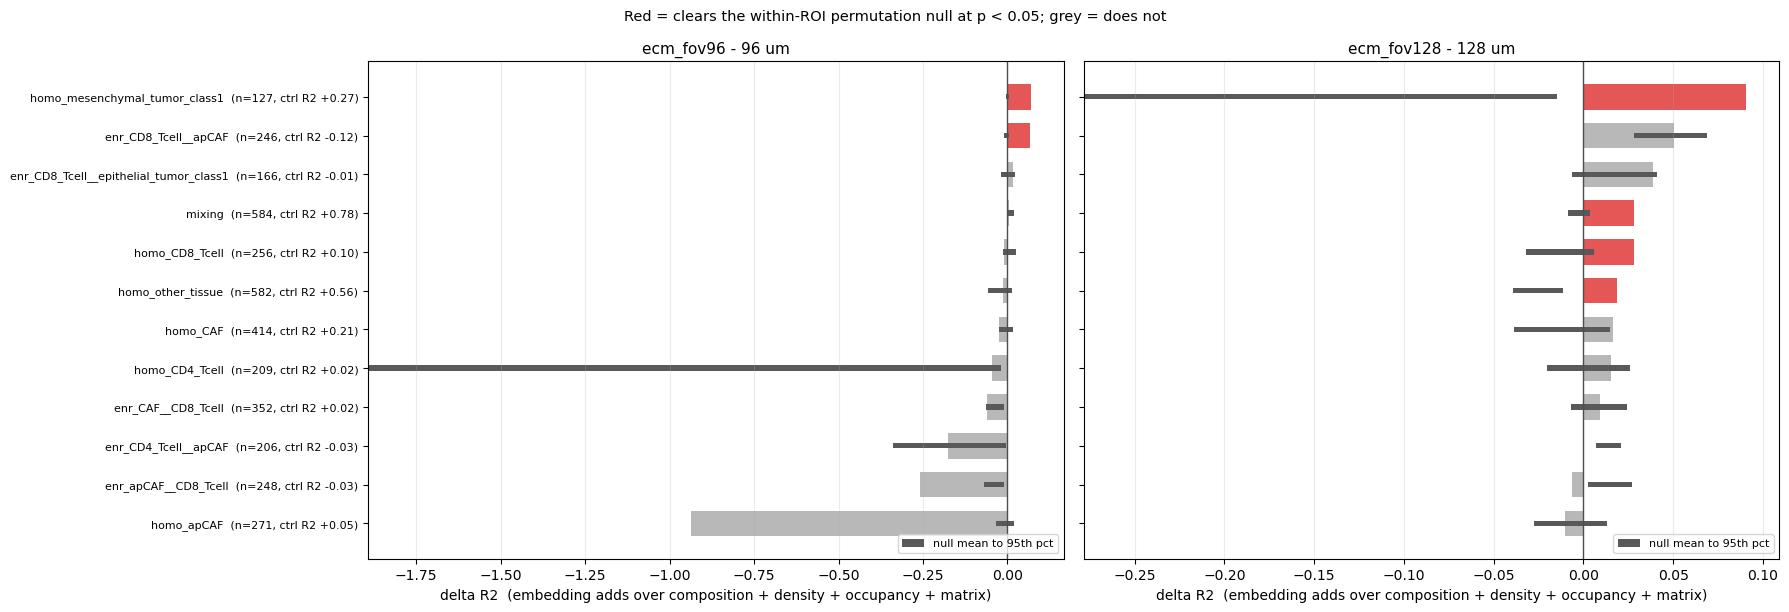

In [19]:
fig, axes = plt.subplots(1, len(CONFIGS), figsize=(9.0 * len(CONFIGS), 6.2), sharey=True)
for ax, k in zip(np.atleast_1d(axes), CONFIGS):
    sub = DR.query("config == @k").sort_values("delta")
    ys = np.arange(len(sub))
    ax.barh(ys, sub["delta"], color=["#E45756" if b else "0.72" for b in sub["beats_null"]],
            height=0.66)
    # the null band: what capacity alone buys
    ax.barh(ys, sub["null_p95"] - sub["null_mean"], left=sub["null_mean"],
            color="0.35", height=0.14, label="null mean to 95th pct")
    ax.axvline(0, color="0.3", lw=1)
    ax.set_yticks(ys)
    ax.set_yticklabels(["{}  (n={}, ctrl R2 {:+.2f})".format(t, n, r)
                        for t, n, r in zip(sub.target, sub.n, sub.r2_control)], fontsize=8)
    ax.set_xlabel("delta R2  (embedding adds over composition + density + occupancy + matrix)")
    ax.set_title("{} - {} um".format(k, CONFIGS[k]), fontsize=11)
    ax.grid(axis="x", alpha=0.25); ax.legend(fontsize=8, loc="lower right")
fig.suptitle("Red = clears the within-ROI permutation null at p < 0.05; grey = does not",
             fontsize=10.5)
plt.tight_layout(); plt.show()

### Is ΔR² just the number of PCs?

The null already prices capacity in at 16 PCs, but the honest check is whether the answer
survives changing it. If Δ grows without limit as PCs are added, it is flexibility, not
information.

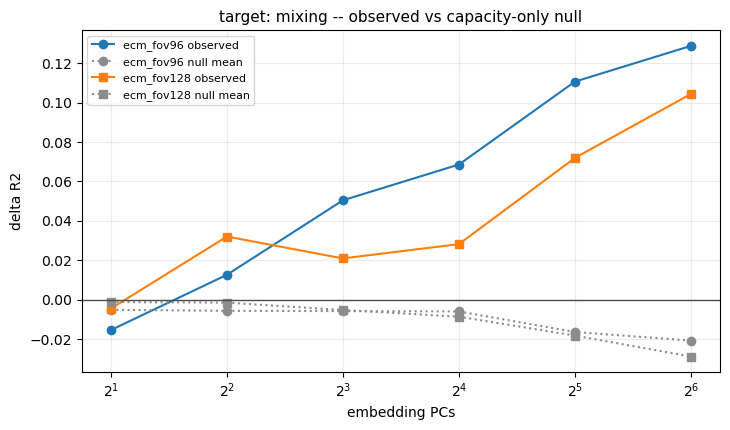

,config,n_pc,delta,null_mean,p
0,ecm_fov96,2,-0.0154,-0.0051,0.9344
1,ecm_fov96,4,0.0127,-0.0056,0.0164
2,ecm_fov96,8,0.0505,-0.0058,0.0164
3,ecm_fov96,16,0.0686,-0.0059,0.0164
4,ecm_fov96,32,0.1107,-0.0164,0.0164
5,ecm_fov96,64,0.1288,-0.0207,0.0164
6,ecm_fov128,2,-0.0045,-0.0012,0.7705
7,ecm_fov128,4,0.0321,-0.0015,0.0164
8,ecm_fov128,8,0.0210,-0.0052,0.0164
9,ecm_fov128,16,0.0282,-0.0086,0.0164


In [20]:
SWEEP_T = "mixing" if "mixing" in TARGETS else TARGETS[0]
rows = []
for k in CONFIGS:
    full = PCA(n_components=64, random_state=0).fit_transform(np.asarray(W[k].X, dtype=float))
    for npc in (2, 4, 8, 16, 32, 64):
        r = imc_tm.nested_delta_r2(CTRL[k].values, full[:, :npc], ARR[k][SWEEP_T].values,
                                   BLK[k], n_perm=60, seed=0)
        rows.append(dict(config=k, n_pc=npc, delta=r["delta"],
                         null_mean=r["null_mean"], p=r["p"]))
KS = pd.DataFrame(rows)
fig, ax = plt.subplots(figsize=(7.4, 4.4))
for k, mk in zip(CONFIGS, ("o-", "s-")):
    s = KS.query("config == @k")
    ax.plot(s.n_pc, s.delta, mk, label="{} observed".format(k))
    ax.plot(s.n_pc, s.null_mean, mk.replace("-", ":"), color="0.55",
            label="{} null mean".format(k))
ax.set_xscale("log", base=2); ax.set_xlabel("embedding PCs"); ax.set_ylabel("delta R2")
ax.set_title("target: {} -- observed vs capacity-only null".format(SWEEP_T), fontsize=11)
ax.axhline(0, color="0.3", lw=1); ax.grid(alpha=0.25); ax.legend(fontsize=8)
plt.tight_layout(); plt.show()
display(KS.round(4))

### The same cells, laid out differently

The statistic in one picture. Within a single ROI — so patient and section are held fixed —
find the pair of windows whose **control vectors** are nearest (same composition, same
density, same occupancy, same matrix) while their **embeddings** are farthest apart. If the
motifs were a compositional summary, no such pair could exist.

composition-matched pairs (nearest 5% within an ROI) that land in DIFFERENT clusters: 509
showing JHH387ROI1: windows 593 and 648, control distance 1.470 z-units, embedding distance 40.8


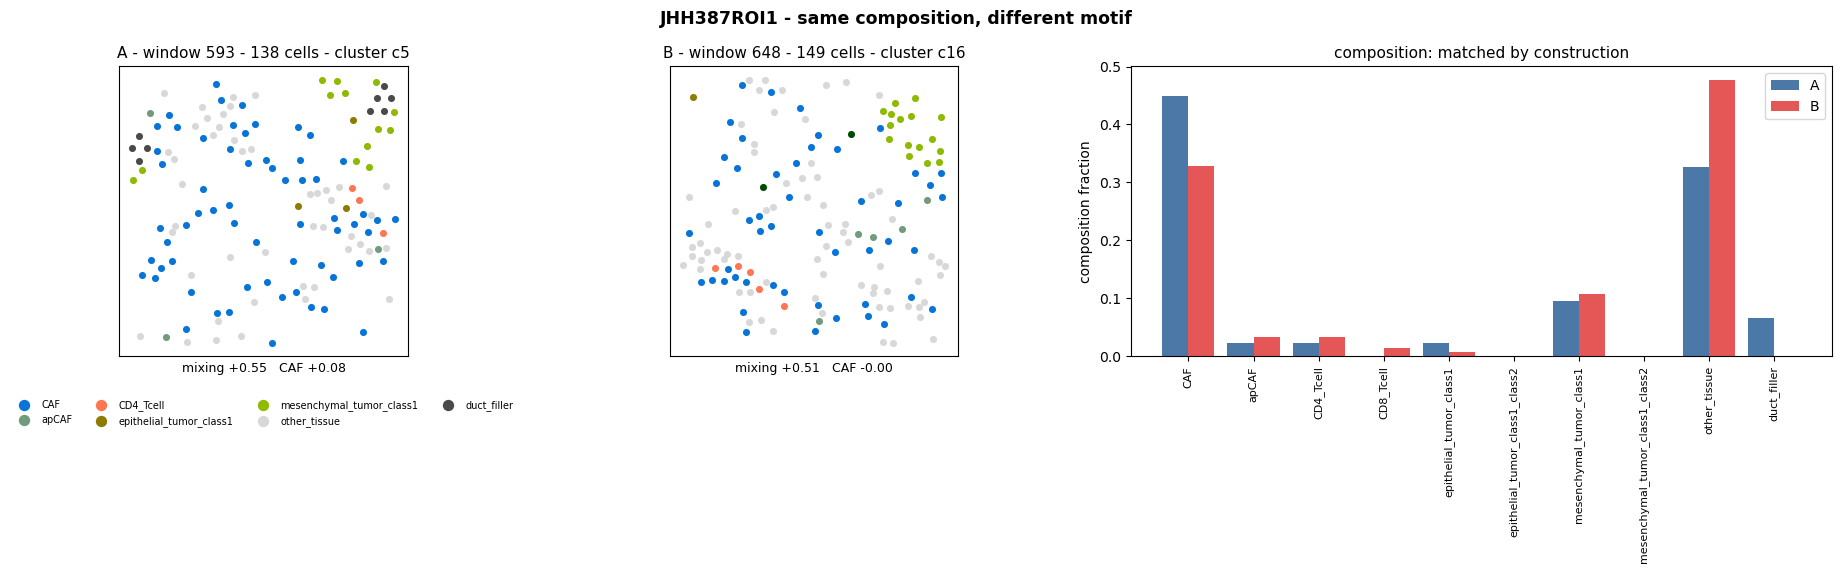

In [21]:
from scipy.spatial.distance import cdist

K_SHOW = "ecm_fov128" if "ecm_fov128" in CONFIGS else list(CONFIGS)[0]
w, ctrl = W[K_SHOW], CTRL[K_SHOW].values
cz = (ctrl - ctrl.mean(0)) / np.clip(ctrl.std(0), 1e-9, None)
ez = EMB[K_SHOW]
lab = np.asarray(w.obs.leiden).astype(str)
idx_lists = imc_tm.window_cell_index(w, cells)
SHOW = ["mixing", "homo_CD8_Tcell", "homo_CAF"]

# Require a DIFFERENT cluster. Maximum embedding distance alone can land on two windows the
# clustering still calls the same motif, which demonstrates nothing -- the claim is that
# composition-matched windows get assigned DIFFERENT motifs.
n_pairs, best = 0, None
for r in ROIS:
    m = np.flatnonzero(ROI_G[K_SHOW] == r)
    if len(m) < 12:
        continue
    dc = cdist(cz[m], cz[m])
    iu = np.triu_indices(len(m), k=1)
    near = dc[iu] <= np.quantile(dc[iu], 0.05)          # most compositionally alike 5%
    diff = lab[m][iu[0]] != lab[m][iu[1]]
    cand = near & diff
    n_pairs += int(cand.sum())
    if not cand.any():
        continue
    de = cdist(ez[m], ez[m])[iu]
    score = np.where(cand, de, -np.inf)
    b = int(np.argmax(score))
    if best is None or score[b] > best[0]:
        best = (score[b], r, m[iu[0][b]], m[iu[1][b]], dc[iu][b])

print("composition-matched pairs (nearest 5% within an ROI) that land in DIFFERENT "
      "clusters: {}".format(n_pairs))
if best is None:
    print("none found -- at this FOV the motifs ARE a compositional summary")
else:
    _, roi_b, i1, i2, dctrl = best
    print("showing {}: windows {} and {}, control distance {:.3f} z-units, "
          "embedding distance {:.1f}".format(roi_b, i1, i2, dctrl,
                                             float(np.linalg.norm(ez[i1] - ez[i2]))))
    fig, axes = plt.subplots(1, 3, figsize=(19, 5.8),
                             gridspec_kw={"width_ratios": [1, 1, 1.5]})
    for ax, wi, tag in ((axes[0], i1, "A"), (axes[1], i2, "B")):
        ci = idx_lists[wi]
        sub = cells[ci]
        for t in imc_tm.CELL_TYPES:
            mm = (np.asarray(sub.obs.cell_type) == t)
            if mm.sum():
                ax.scatter(sub.obsm["spatial"][mm, 0], sub.obsm["spatial"][mm, 1],
                           s=26, c=[TPAL[t]], label=t, linewidths=0)
        ax.set_aspect("equal"); ax.set_xticks([]); ax.set_yticks([])
        stats = "   ".join("{} {:+.2f}".format(s.replace("homo_", ""), ARR[K_SHOW][s].iloc[wi])
                           for s in SHOW if np.isfinite(ARR[K_SHOW][s].iloc[wi]))
        ax.set_title("{} - window {} - {} cells - cluster c{}".format(tag, wi, len(ci), lab[wi]),
                     fontsize=11)
        ax.set_xlabel(stats, fontsize=9)
    bars = np.arange(len(imc_tm.CELL_TYPES)); wdt = 0.4
    for off, wi, tag, col in ((-wdt / 2, i1, "A", "#4C78A8"), (wdt / 2, i2, "B", "#E45756")):
        axes[2].bar(bars + off, CTRL[K_SHOW].iloc[wi][imc_tm.CELL_TYPES].values,
                    width=wdt, label=tag, color=col)
    axes[2].set_xticks(bars)
    axes[2].set_xticklabels(imc_tm.CELL_TYPES, rotation=90, fontsize=8)
    axes[2].set_ylabel("composition fraction"); axes[2].legend()
    axes[2].set_title("composition: matched by construction", fontsize=11)
    axes[0].legend(bbox_to_anchor=(0.5, -0.12), loc="upper center", ncol=4,
                   fontsize=7, markerscale=1.6, frameon=False)
    fig.suptitle("{} - same composition, different motif".format(roi_b),
                 fontsize=12.5, weight="bold")
    plt.tight_layout(); plt.show()


## Reading it

- **The ΔR² section is the one that answers "more than composition".** Everything else in
  this notebook shows the clusters are coherent and interpretable; only that section shows
  they carry information a composition vector does not. Read the red bars, and read them
  against the null band rather than against zero.

- **Tissue maps are the check that depends on no statistic.** Contiguous blocks mean the
  window size resolves real domains; speckle means it does not. Compare each row's window
  panels against its ECM panel and its cell panel — a cluster boundary following a visible
  change in either is the model working.
- **UMAP by ECM content** is the one figure specific to this screen. A smooth gradient
  means channel 10 is in the representation; if it looked like noise, the whole 11-channel
  exercise would be decoration. S4 quantifies the same thing as eta² on cluster means.
- **UMAP by ROI**: separation by ROI is the failure mode, but some is real biology. Read it
  against S4's composition baseline, not against perfect mixing.
- **Composition spread**: a tight box across ROIs is a recurring motif; a cluster driven by
  one ROI is closer to a section artefact. Section b reads one channel across all clusters;
  section c reads one cluster's whole profile in a single panel.

### Caveats

- **Fractions here are mass over eleven channels**, so they include matrix in the
  denominator and are not exactly comparable to S3's ten-channel numbers — though the
  matrix share of mass is small (a few percent), so the difference is far less than the
  count-based `patch_ncv` would have suggested.
- **ECM normalisation is per-ROI**, to each section's own 95th percentile — so "high
  matrix" always means high *for that section*, and the ECM panels of two ROIs are not on
  a common absolute scale.
- **Epoch 499 of 1000, on the peak-LR plateau.** The cosine decay runs 900-1000 and has
  not happened; neither model has consolidated. S4b's 200-epoch models had.
- **Eight ROIs, five patients, all training data.** Nothing here is a transfer test.
- **The crop filter differs from S3's.** These models trained and tile at
  `n_element_min_for_crop = 20` counting nonzero entries, which matrix alone nearly
  satisfies, so the window sets include emptier tiles than S3's 10-cell filter admitted.
  S4 re-filters onto a shared grid for its metrics; this notebook deliberately does not,
  since the point here is to see what the model itself produces.